## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

#print(f'--> outputs logs in: {OUTPUT_PATH}')

## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'balance'

BASE_CAR_BEHAVIOR = {
    'pres': 60,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 12,    # annulation anticipée (> 2h avant)
    'late': 8,      # annulation tardive (< 2h avant)
    'noise': 0.10
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:46:49.680 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:46:49.749 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:46:49.871 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:46:49.875 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:46:49.941 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:46:50.008 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:46:50.091 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:46:50.171 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:46:50.209 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:46:50.354 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:46:50.375 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 18.96 kWh
  Station 1: 16.17 kWh
  Station 2: 0.00 kWh
  Station 3: 9.70 kWh
  Station 4: 42.26 kWh
  Station 5: 2.04 kWh
  Station 6: 21.00 kWh
  Station 7: 14.51 kWh
  Station 8: 1.81 kWh
  Station 9: 0.00 kWh
  Station 10: 2.17 kWh
  Station 11: 13.12 kWh
  Station 12: 0.00 kWh
  Station 13: 16.19 kWh
  Station 14: 1.57 kWh
  Station 15: 0.00 kWh
  Station 16: 8.40 kWh
  Station 17: 0.00 kWh
  Station 18: 4.46 kWh
  Station 19: 1.75 kWh
  Station 20: 14.84 kWh
  Station 21: 2.10 kWh
  Station 22: 0.00 kWh
  Station 23: 2.00 kWh
  Station 24: 0.00 kWh
  Station 25: 11.68 kWh
  Station 26: 0.00 kWh
  Station 27: 8.53 kWh
  Station 28: 95.81 kWh
  Station 29: 26.43 kWh
  Station 30: 0.00 kWh
  Station 31: 10.29 kWh
  Station 32: 10.41 kWh
  Station 33: 5.27 kWh
  Station 34: 9.68 kWh
  Station 35: 0.00 kWh
  Station 36: 1.80 kWh
  Station 37: 62.42 kWh
  Station 38: 75.28 kWh
  Station 39: 0.00 kWh

--- User Re

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

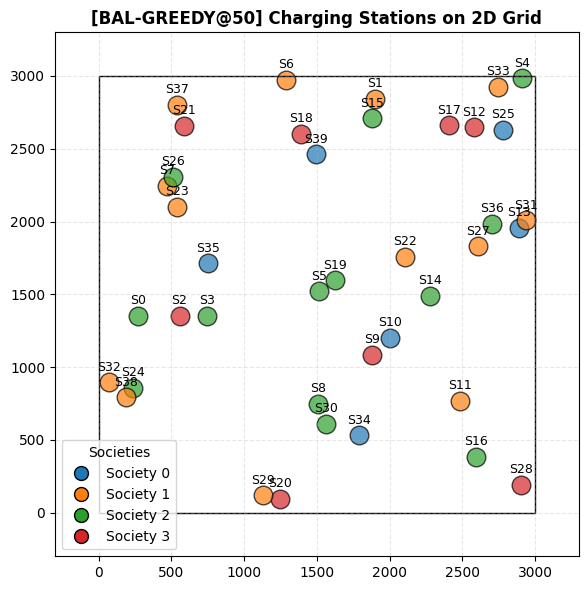

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

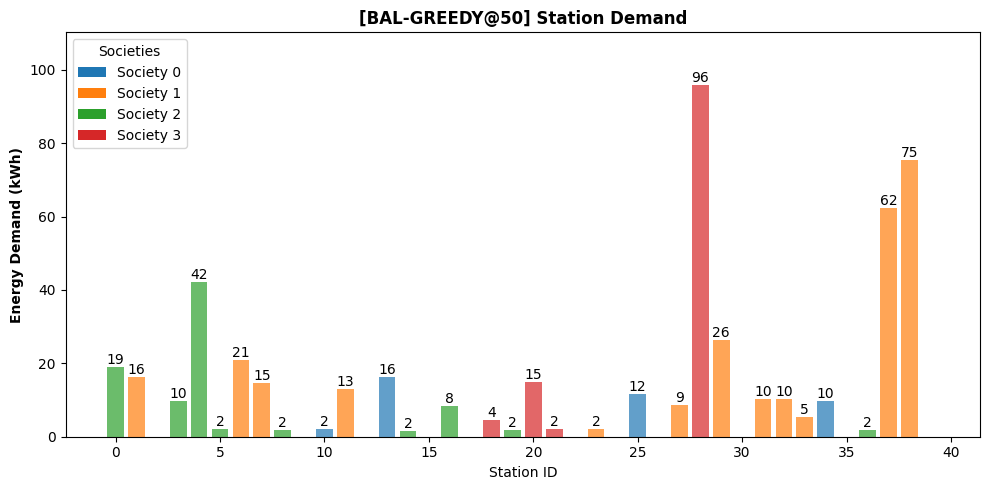

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

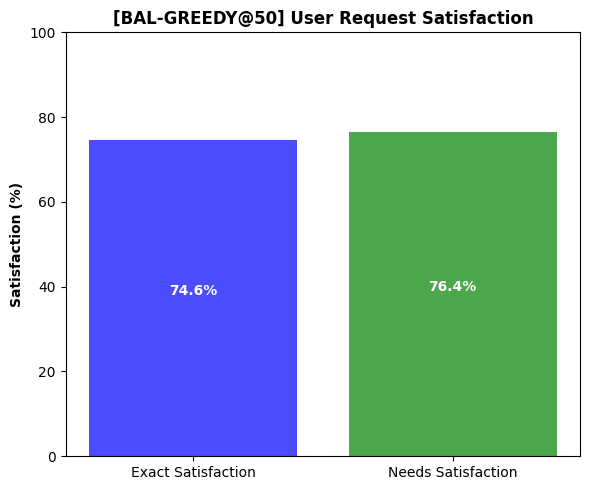

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

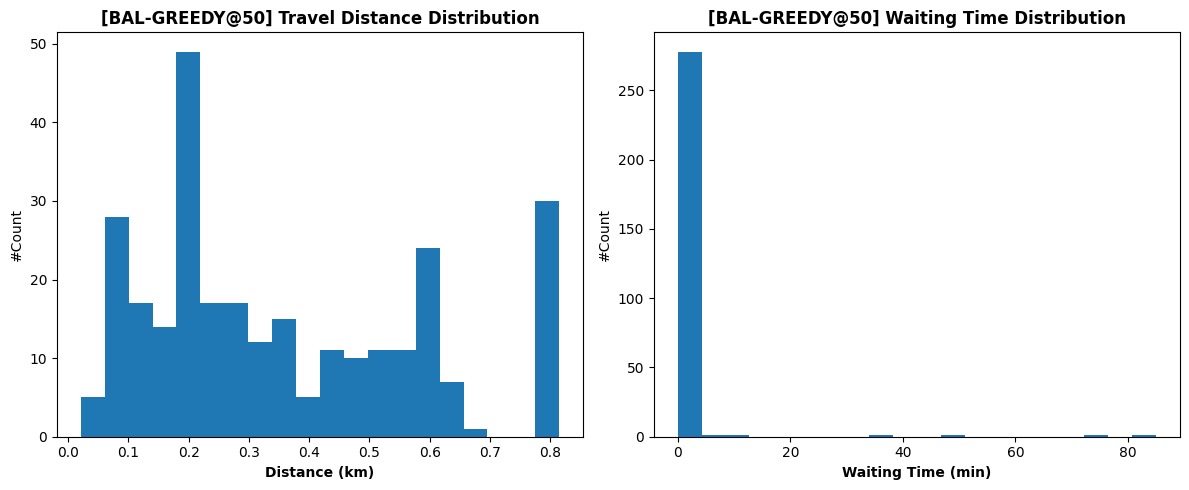

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

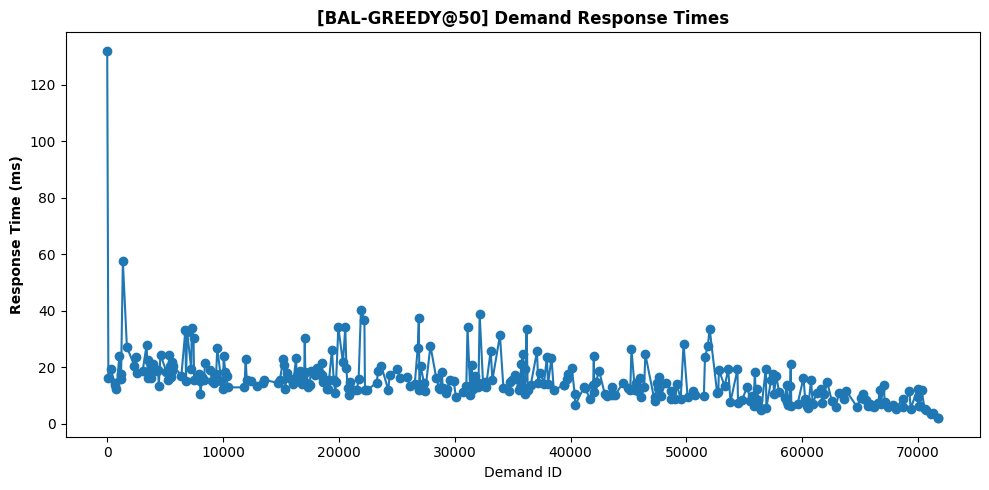

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

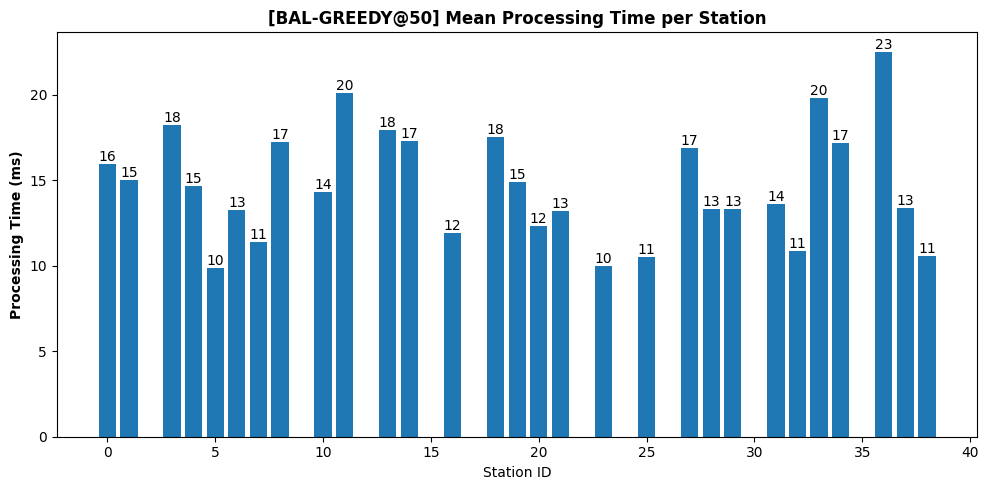

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [26]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0          10  0.036111  0.000000  0.000000  0.000000  0.000000   
1            0          13  0.236806  0.000000  0.000000  0.000000  0.000000   
2            0          25  0.086806  0.043750  0.000000  0.054167       NaN   
3            0          34  0.044444  0.091667  0.000000  0.000000  0.000000   
4            0          35  0.000000  0.000000  0.000000  0.000000       NaN   
5            0          39  0.000000  0.000000  0.000000  0.000000       NaN   
6            1           1  0.220139  0.030556  0.000000  0.000000  0.000000   
7            1           6  0.184722  0.094444  0.012500  0.000000  0.034028   
8            1           7  0.134722  0.074306  0.000000  0.000000       NaN   
9            1          11  0.201389  0.000000  0.000000  0.000000  0.000000   
10           1          22  0.000000  0.000000  0.000000  0.000000  0.000000   
11           1          23  0.027778  0.

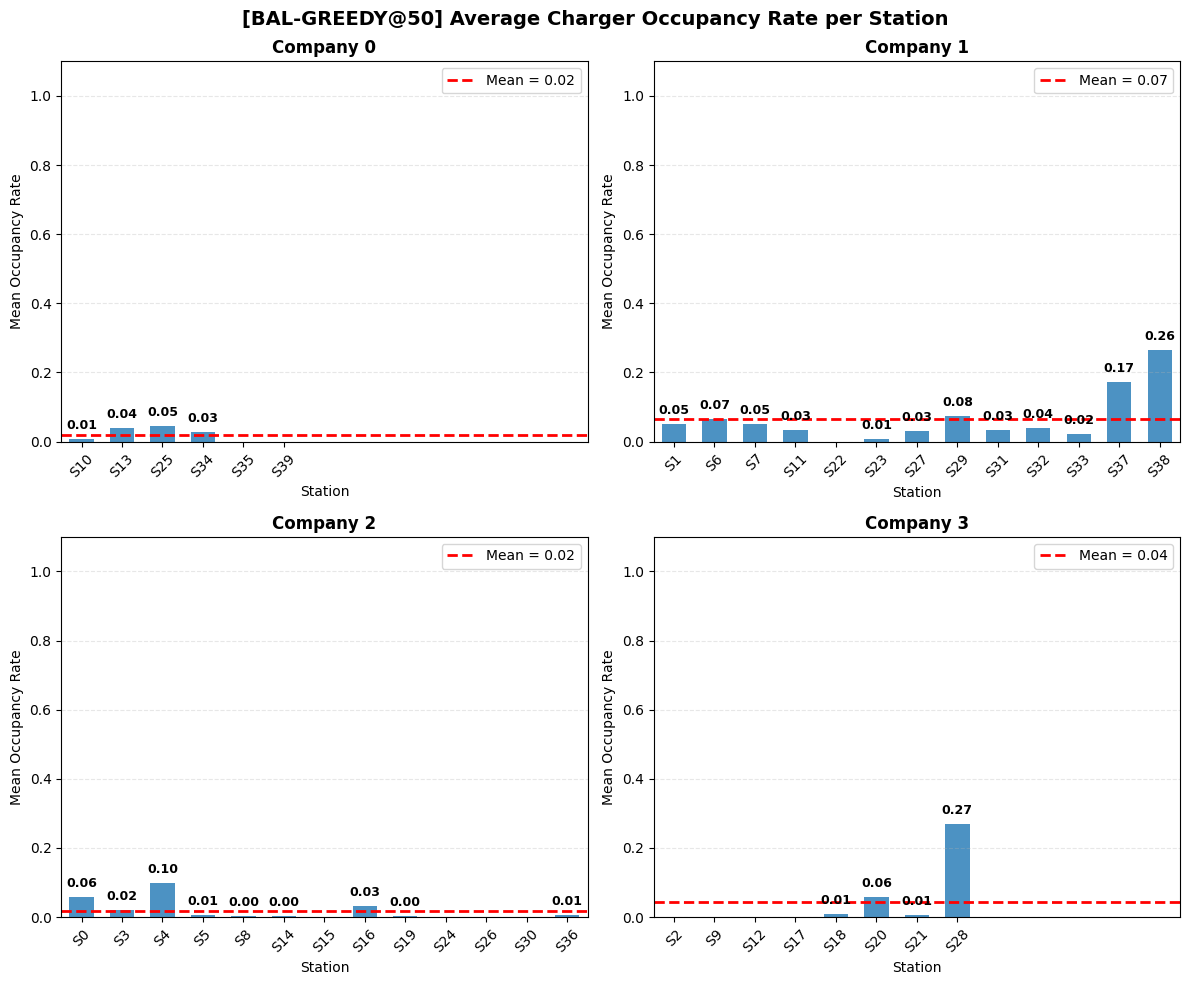

In [27]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

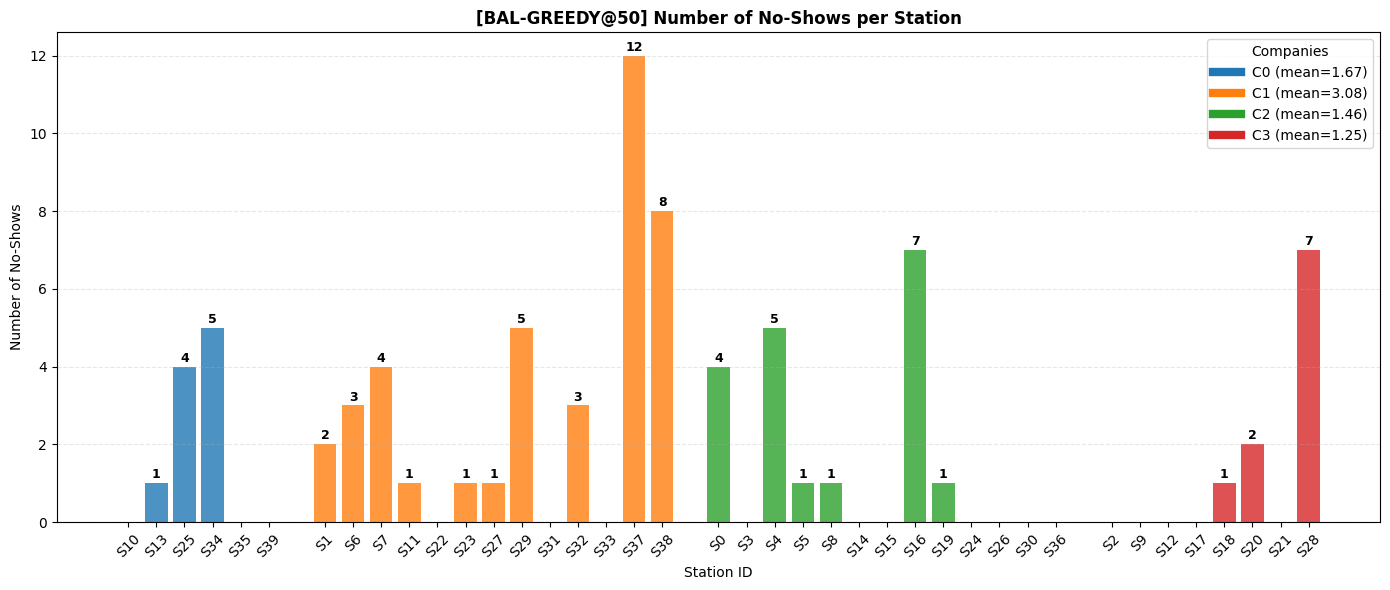

In [28]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [29]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,10,1,1,0,0,0,1.000000,0.000000,0.0,0.0
1,0,13,10,9,1,0,0,0.900000,0.100000,0.0,0.0
2,0,25,9,5,4,0,0,0.555556,0.444444,0.0,0.0
3,0,34,10,5,5,0,0,0.500000,0.500000,0.0,0.0
4,0,35,0,0,0,0,0,NaN,NaN,NaN,NaN
5,0,39,0,0,0,0,0,NaN,NaN,NaN,NaN
6,1,1,12,10,2,0,0,0.833333,0.166667,0.0,0.0
7,1,6,15,12,3,0,0,0.800000,0.200000,0.0,0.0
8,1,7,13,9,4,0,0,0.692308,0.307692,0.0,0.0
9,1,11,9,7,1,0,0,0.777778,0.111111,0.0,0.0


NUMBER OF REJECTED REQUESTS

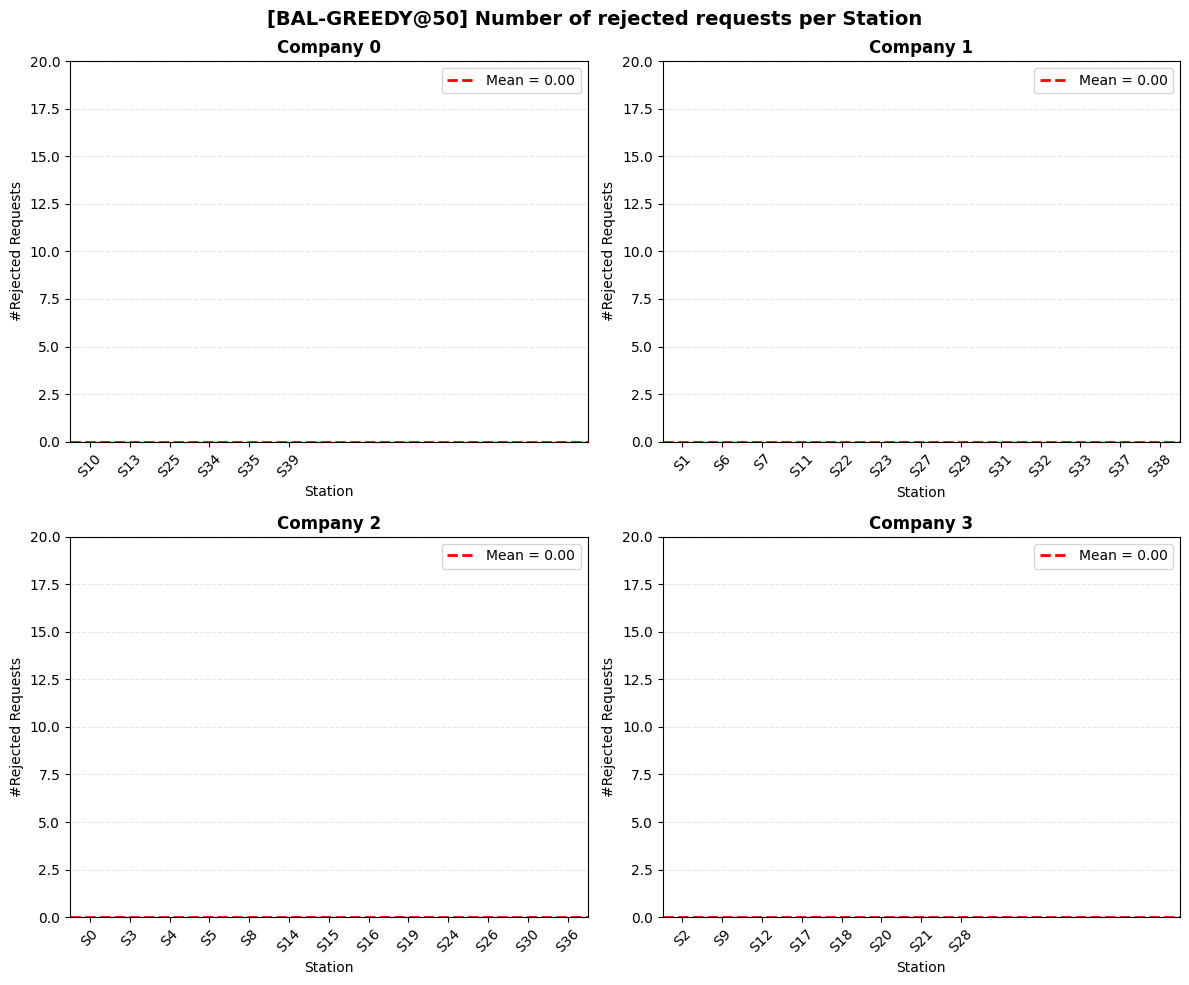

In [30]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [31]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [32]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [33]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:46:56.700 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:46:56.770 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:46:57.173 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:46:58.332 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:46:59.330 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:46:59.400 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:47:00.028 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:47:00.731 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:47:01.147 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:47:01.677 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:47:02.450 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [34]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 1.57 kWh
  Station 2: 19.45 kWh
  Station 3: 77.38 kWh
  Station 4: 13.62 kWh
  Station 5: 20.82 kWh
  Station 6: 0.00 kWh
  Station 7: 13.42 kWh
  Station 8: 4.73 kWh
  Station 9: 0.00 kWh
  Station 10: 1.93 kWh
  Station 11: 17.54 kWh
  Station 12: 10.44 kWh
  Station 13: 9.22 kWh
  Station 14: 43.72 kWh
  Station 15: 3.13 kWh
  Station 16: 4.36 kWh
  Station 17: 7.27 kWh
  Station 18: 3.20 kWh
  Station 19: 1.87 kWh
  Station 20: 51.85 kWh
  Station 21: 29.22 kWh
  Station 22: 2.07 kWh
  Station 23: 16.14 kWh
  Station 24: 6.02 kWh
  Station 25: 3.07 kWh
  Station 26: 12.79 kWh
  Station 27: 18.52 kWh
  Station 28: 0.00 kWh
  Station 29: 24.80 kWh
  Station 30: 0.00 kWh
  Station 31: 13.47 kWh
  Station 32: 3.96 kWh
  Station 33: 47.97 kWh
  Station 34: 24.76 kWh
  Station 35: 5.33 kWh
  Station 36: 1.93 kWh
  Station 37: 0.00 kWh
  Station 38: 4.13 kWh
  Station 39: 12.49 kWh

--- User

In [35]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

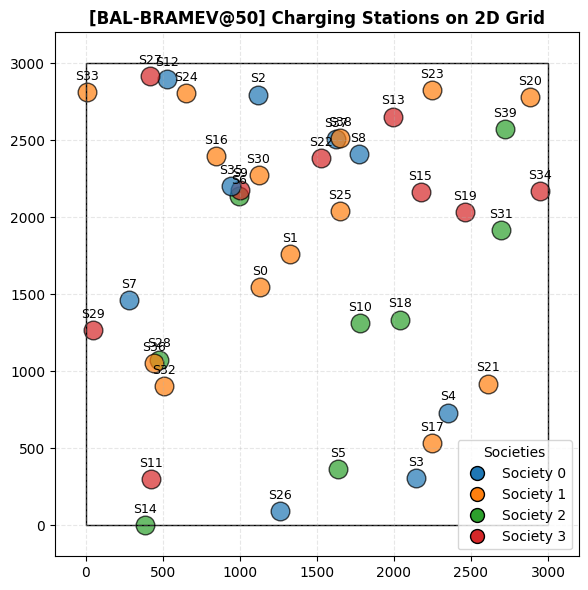

In [36]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

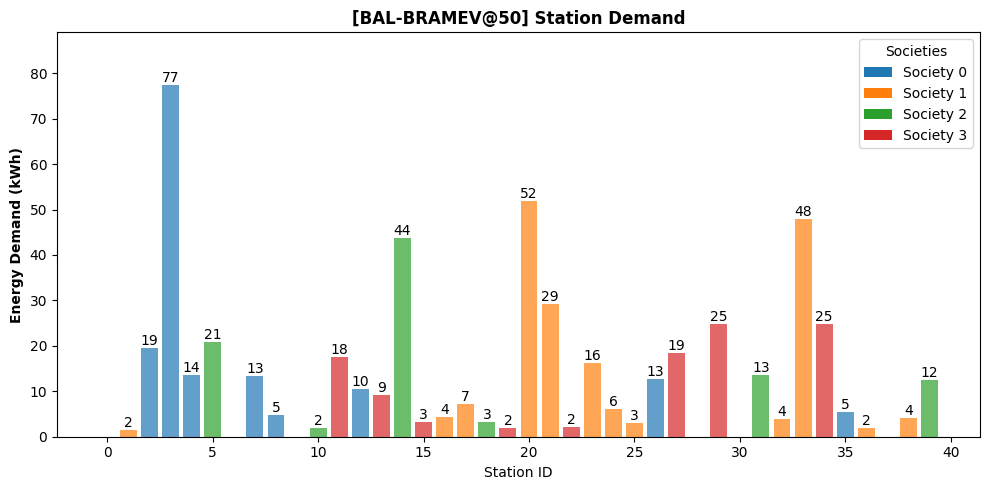

In [37]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

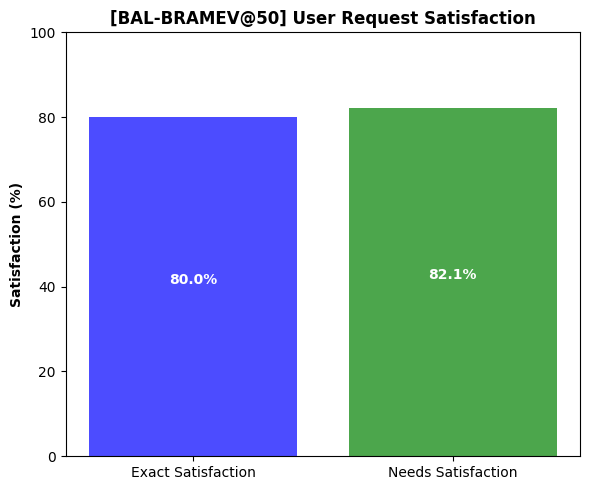

In [38]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

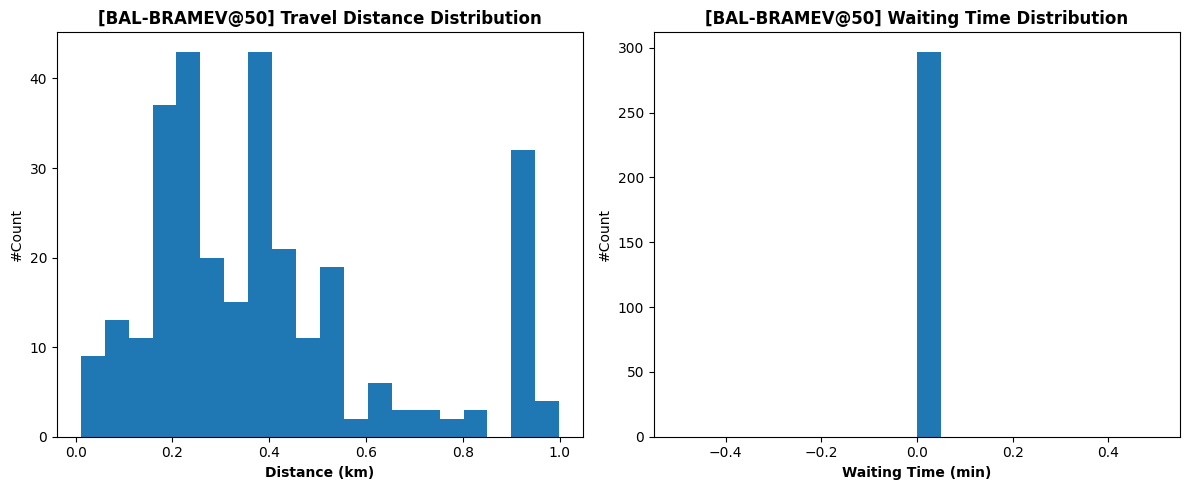

In [39]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

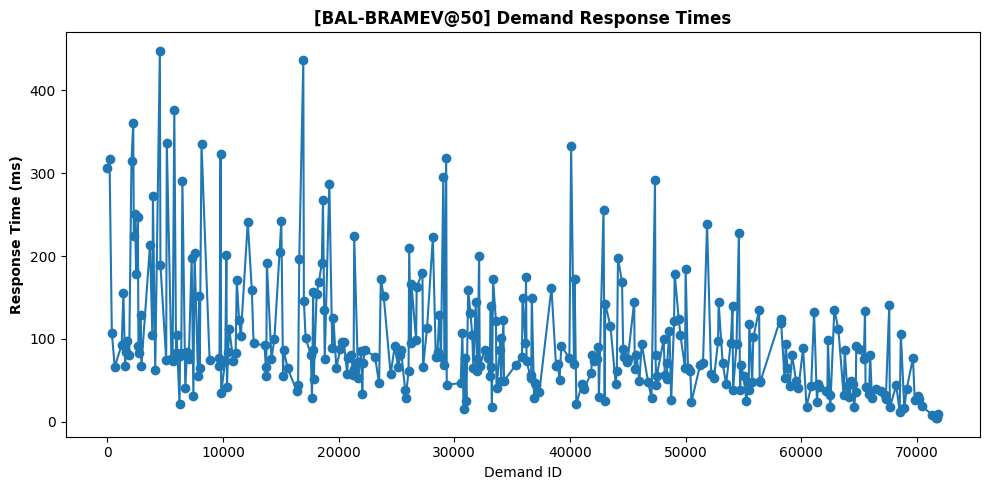

In [40]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

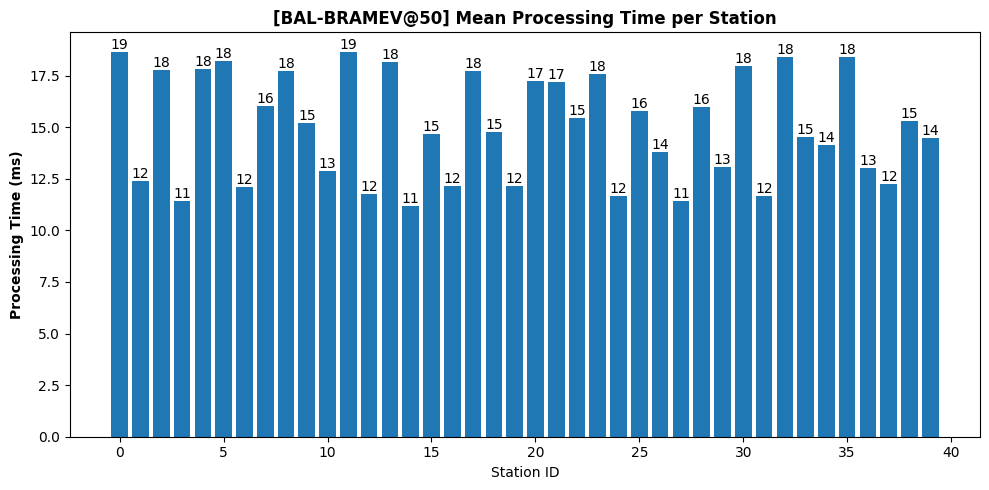

In [41]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

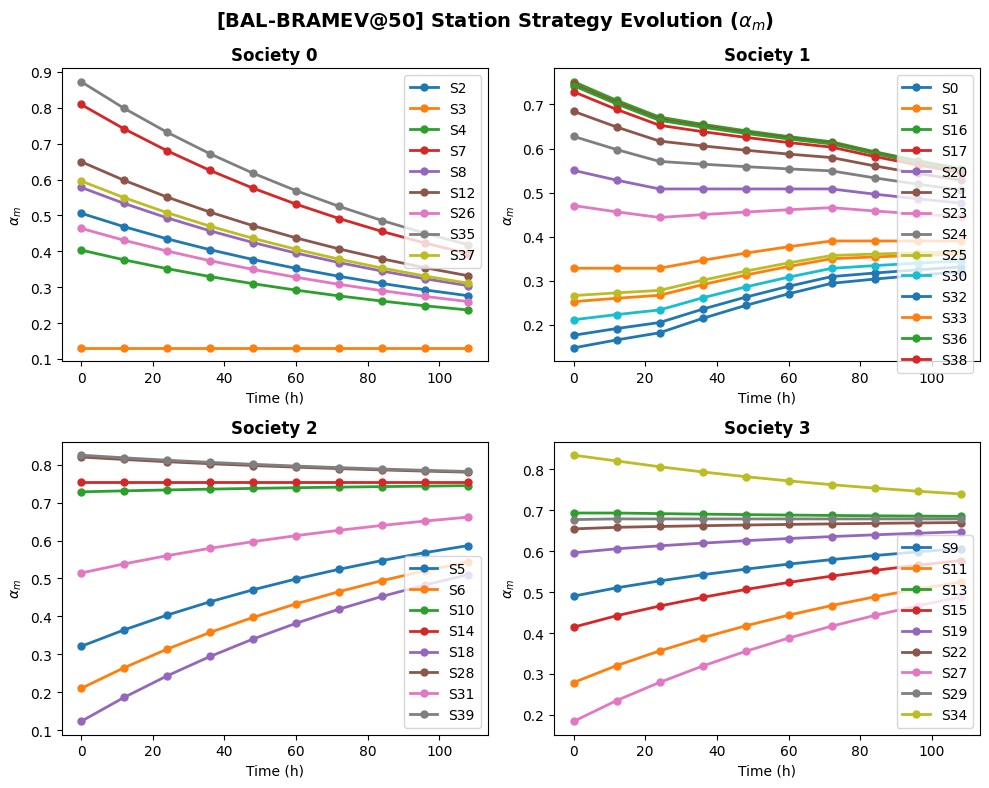

In [42]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [43]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.279167  0.000000  0.000000  0.000000  0.000000   
1            0           3  0.488194  0.451389  0.109028  0.169444       NaN   
2            0           4  0.188889  0.055556  0.000000  0.000000  0.000000   
3            0           7  0.195139  0.000000  0.000000  0.000000  0.000000   
4            0           8  0.057639  0.000000  0.000000  0.000000  0.000000   
5            0          12  0.178472  0.000000  0.000000  0.000000       NaN   
6            0          26  0.171528  0.011111  0.000000  0.000000  0.000000   
7            0          35  0.089583  0.000000  0.000000  0.000000  0.000000   
8            0          37  0.000000  0.000000  0.000000  0.000000       NaN   
9            1           0  0.000000  0.000000  0.000000  0.000000  0.000000   
10           1           1  0.032639  0.000000  0.000000  0.000000       NaN   
11           1          16  0.061806  0.

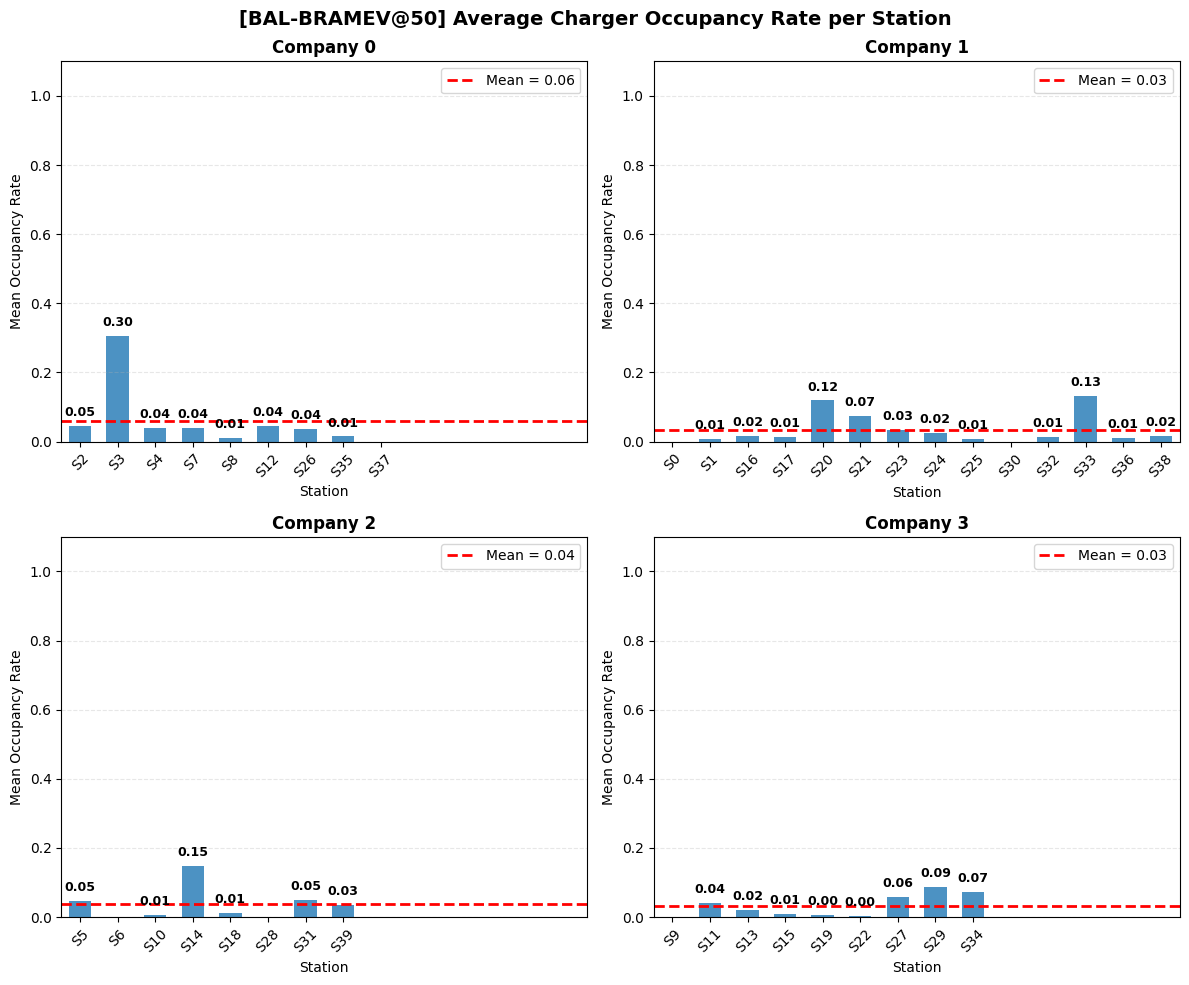

In [44]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

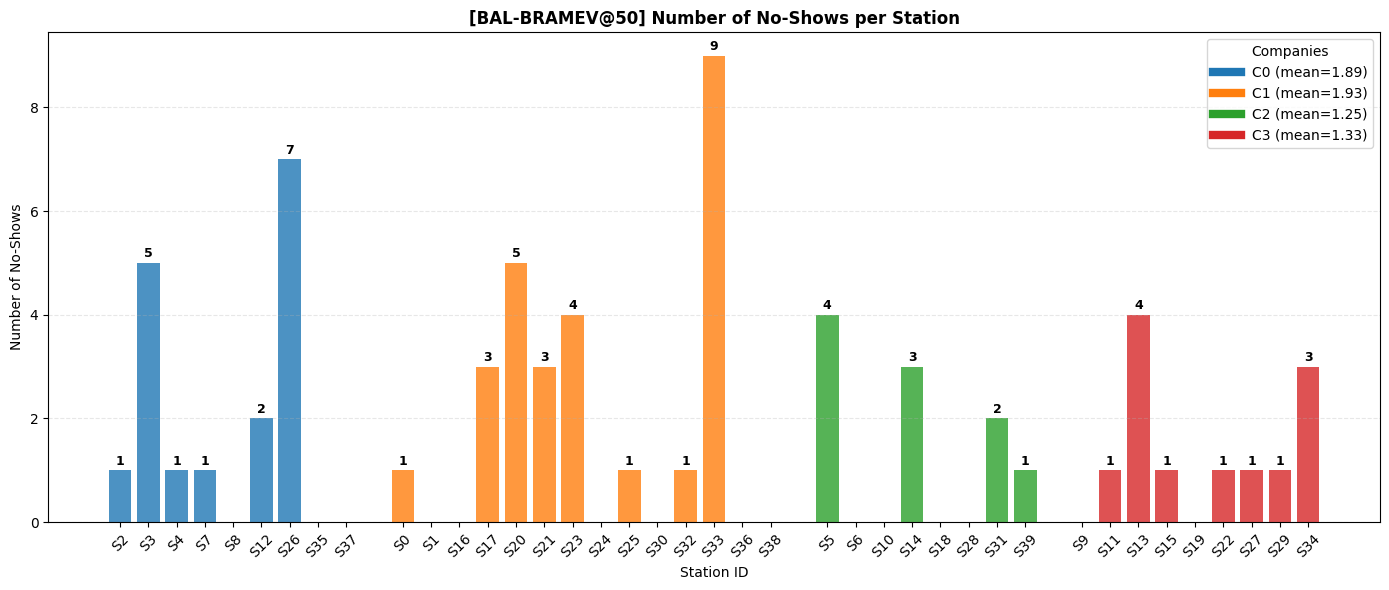

In [45]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [46]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,12,11,1,0,0,0.916667,0.083333,0.0,0.0
1,0,3,50,45,5,0,0,0.900000,0.100000,0.0,0.0
2,0,4,7,6,1,0,0,0.857143,0.142857,0.0,0.0
3,0,7,9,8,1,0,0,0.888889,0.111111,0.0,0.0
4,0,8,2,2,0,0,0,1.000000,0.000000,0.0,0.0
5,0,12,7,5,2,0,0,0.714286,0.285714,0.0,0.0
6,0,26,14,7,7,0,0,0.500000,0.500000,0.0,0.0
7,0,35,3,3,0,0,0,1.000000,0.000000,0.0,0.0
8,0,37,0,0,0,0,0,NaN,NaN,NaN,NaN
9,1,0,1,0,1,0,0,0.000000,1.000000,0.0,0.0


NUMBER OF REJECTED REQUESTS

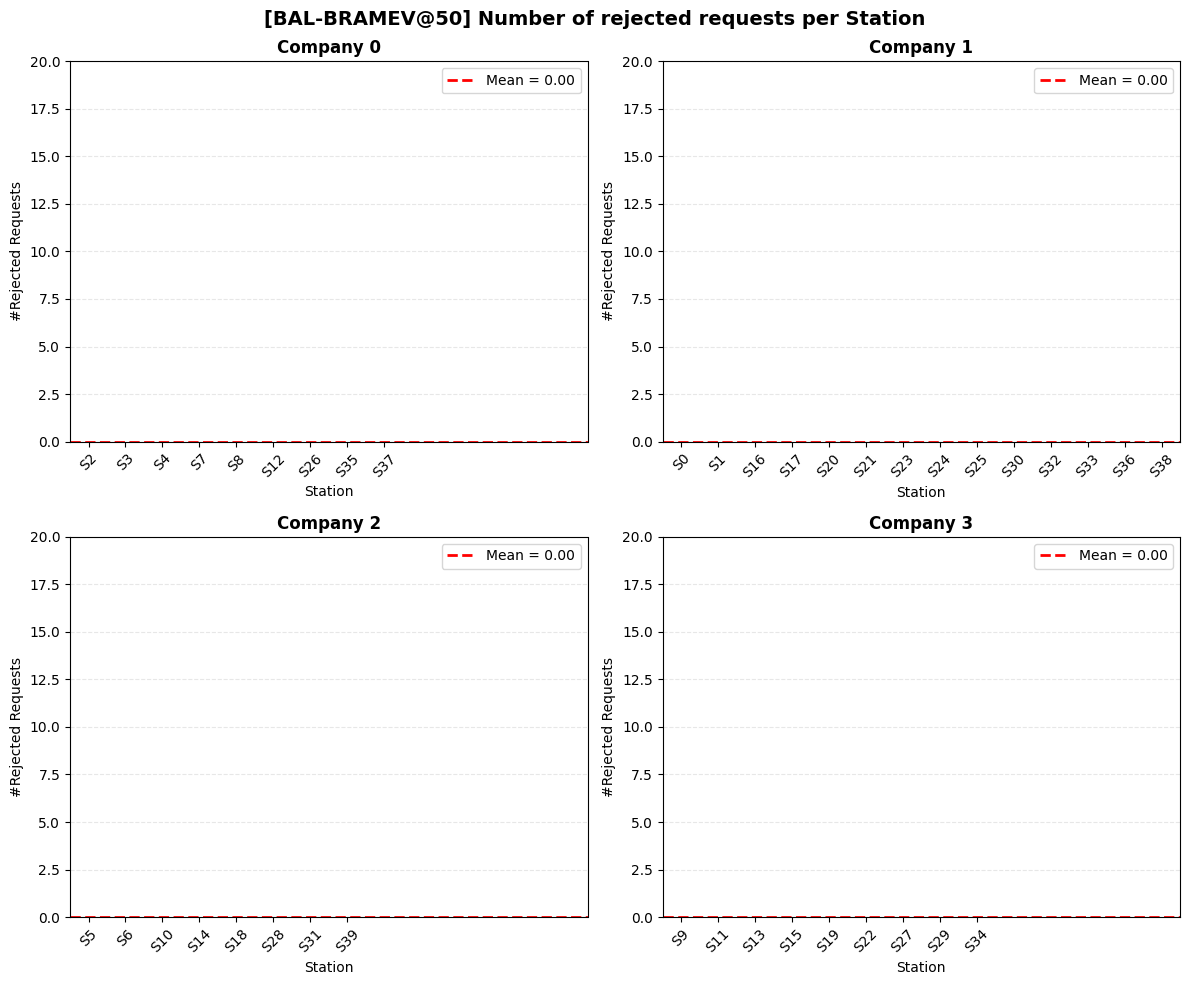

In [47]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [48]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

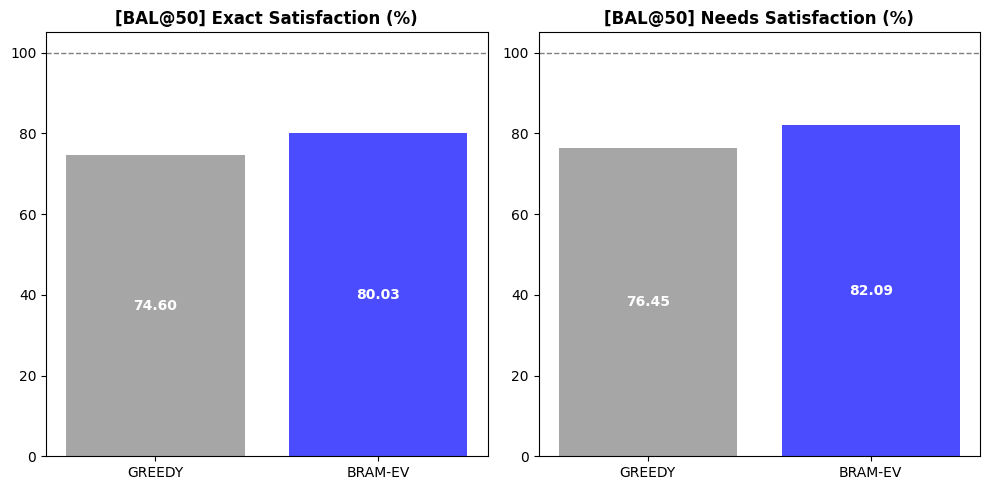

In [49]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

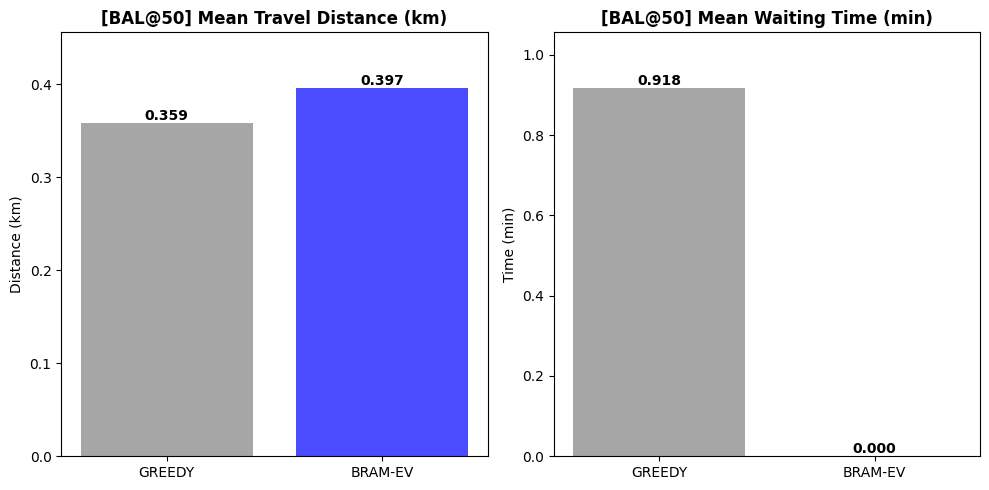

In [50]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

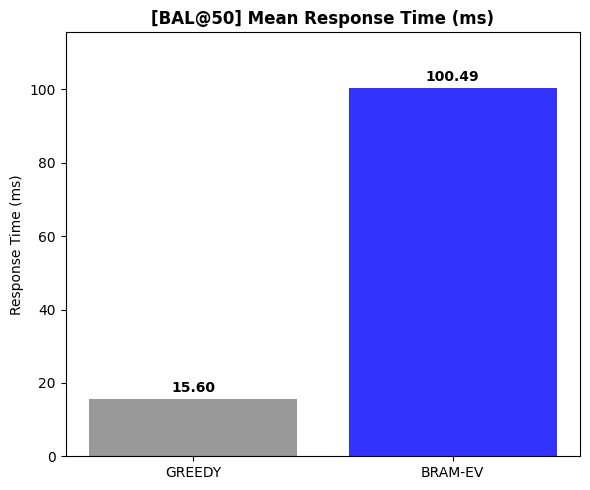

In [51]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [52]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [53]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [54]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [55]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:47:31.895 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:47:32.039 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:47:32.114 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:47:32.299 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:47:32.468 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:47:32.635 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:47:32.742 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:47:32.901 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:47:33.017 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:47:33.115 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:47:33.486 | IN

##### *Metrics*

In [56]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 26.93 kWh
  Station 1: 3.00 kWh
  Station 2: 7.29 kWh
  Station 3: 1.67 kWh
  Station 4: 0.85 kWh
  Station 5: 10.89 kWh
  Station 6: 0.00 kWh
  Station 7: 26.27 kWh
  Station 8: 4.33 kWh
  Station 9: 0.99 kWh
  Station 10: 1.27 kWh
  Station 11: 155.51 kWh
  Station 12: 15.27 kWh
  Station 13: 13.32 kWh
  Station 14: 126.11 kWh
  Station 15: 14.28 kWh
  Station 16: 5.22 kWh
  Station 17: 7.05 kWh
  Station 18: 5.52 kWh
  Station 19: 32.05 kWh
  Station 20: 0.00 kWh
  Station 21: 148.47 kWh
  Station 22: 7.33 kWh
  Station 23: 0.00 kWh
  Station 24: 3.73 kWh
  Station 25: 13.22 kWh
  Station 26: 10.87 kWh
  Station 27: 4.88 kWh
  Station 28: 40.53 kWh
  Station 29: 4.47 kWh
  Station 30: 4.83 kWh
  Station 31: 11.96 kWh
  Station 32: 3.76 kWh
  Station 33: 68.43 kWh
  Station 34: 48.19 kWh
  Station 35: 144.32 kWh
  Station 36: 3.97 kWh
  Station 37: 31.94 kWh
  Station 38: 65.33 kWh
  Station 39: 23.89 kWh

--

In [57]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

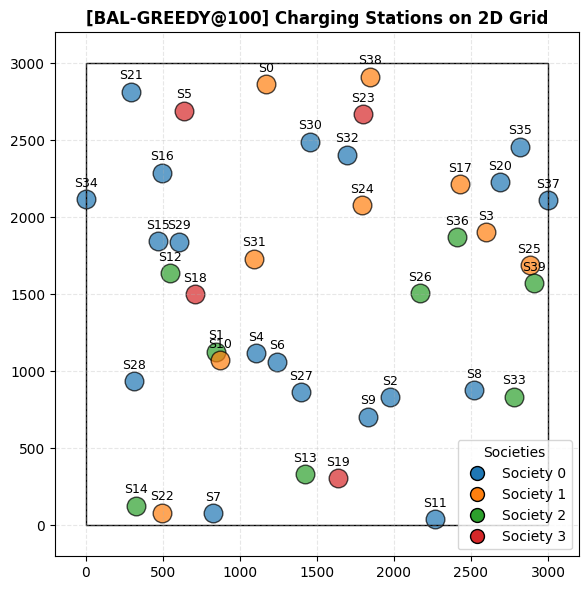

In [58]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

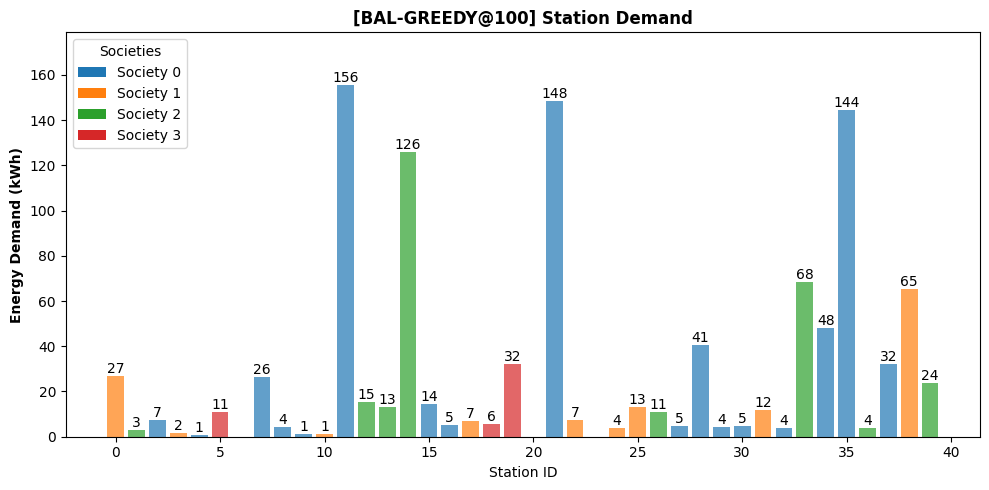

In [59]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

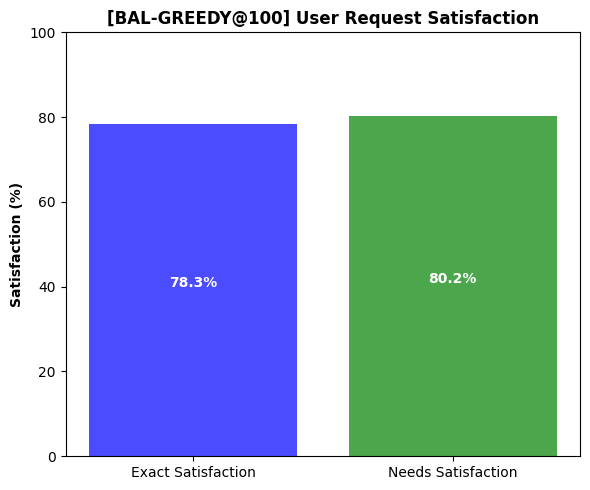

In [60]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

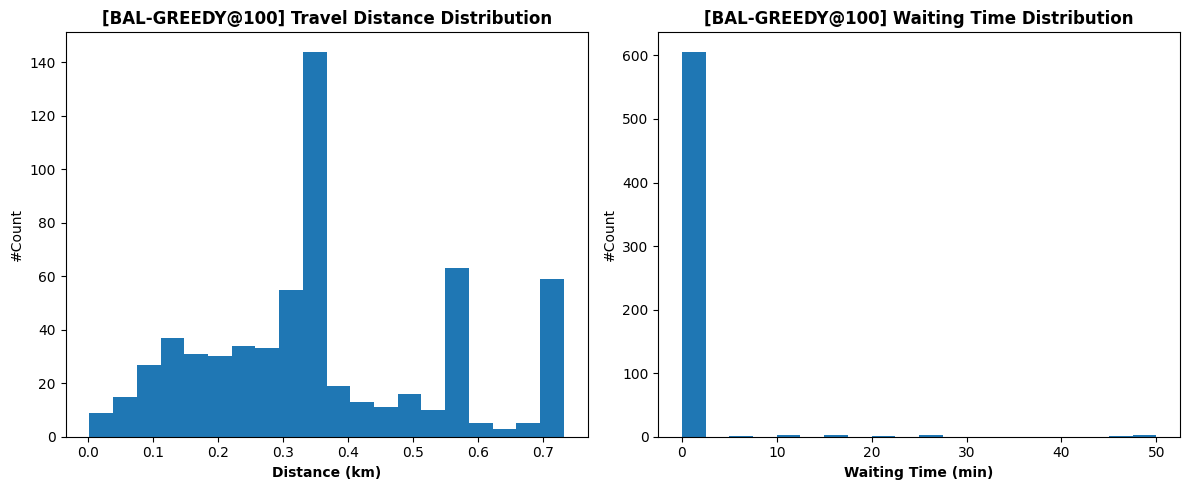

In [61]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

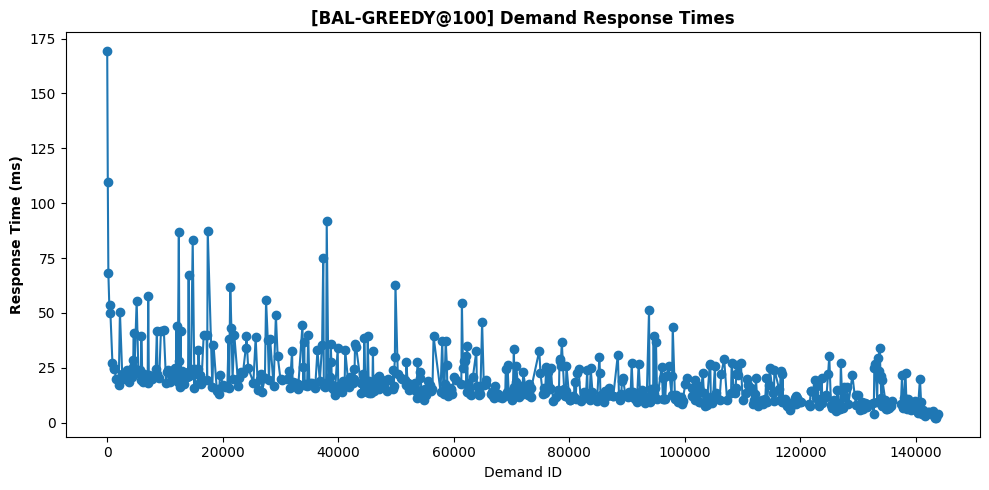

In [62]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

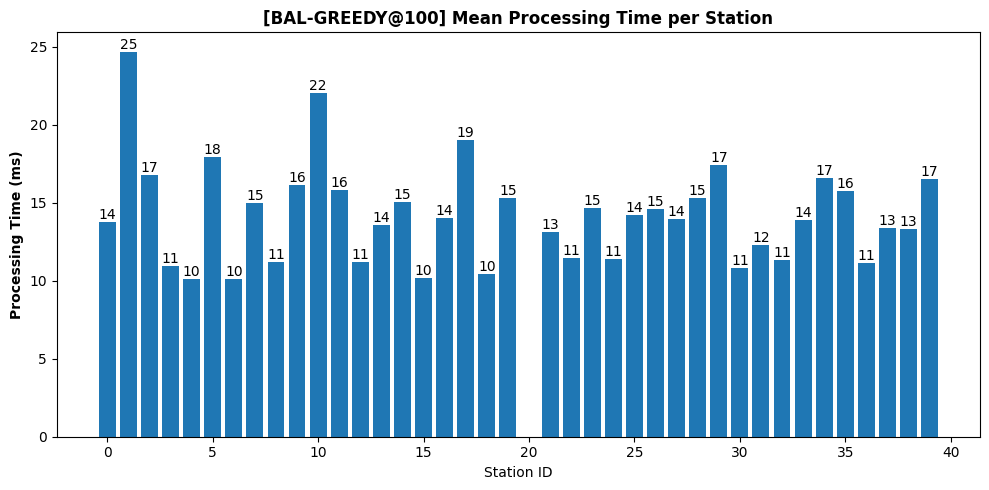

In [63]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [64]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.071528  0.023611  0.000000  0.000000  0.000000   
1            0           4  0.011806  0.000000  0.000000  0.000000  0.000000   
2            0           6  0.000000  0.000000  0.000000  0.000000  0.000000   
3            0           7  0.200694  0.109028  0.022222  0.000000  0.021528   
4            0           8  0.058333  0.000000  0.000000  0.000000  0.000000   
5            0           9  0.011806  0.000000  0.000000  0.000000  0.000000   
6            0          11  0.527778  0.539583  0.170833  0.161111  0.252778   
7            0          15  0.154167  0.029167  0.000000  0.000000       NaN   
8            0          16  0.036806  0.025000  0.000000  0.000000  0.000000   
9            0          20  0.000000  0.000000  0.000000  0.000000       NaN   
10           0          21  0.534722  0.505556  0.234722  0.218056  0.335417   
11           0          27  0.057639  0.

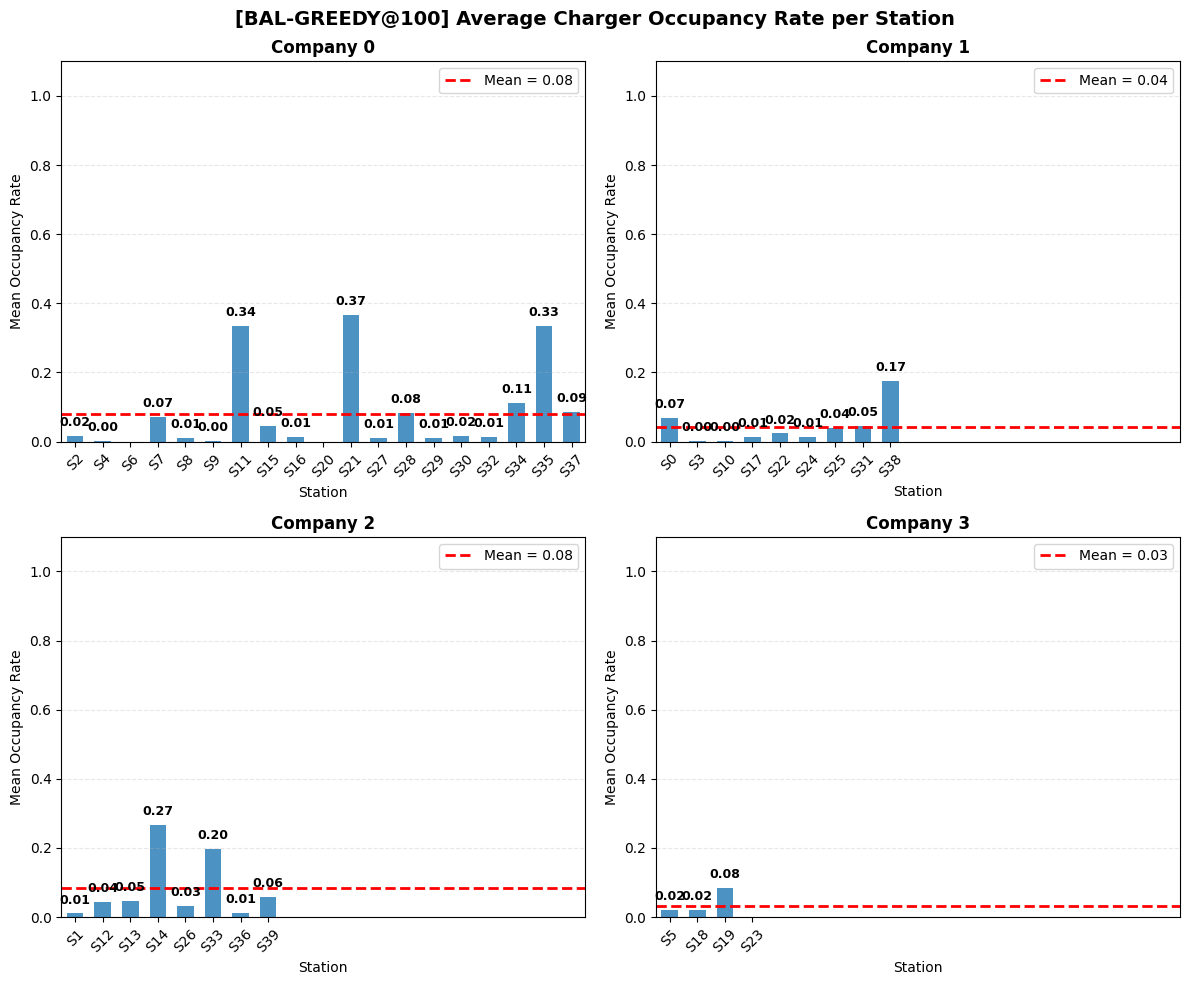

In [65]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

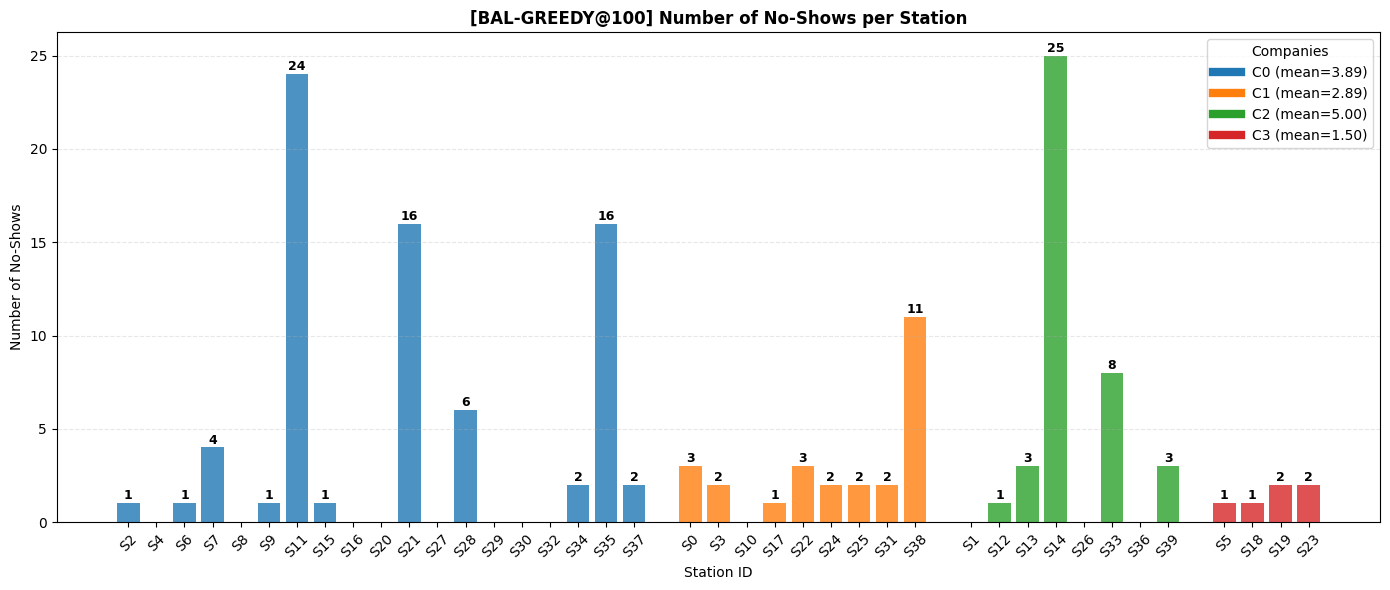

In [66]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [67]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,5,4,1,0,0,0.800000,0.200000,0.0,0.0
1,0,4,1,1,0,0,0,1.000000,0.000000,0.0,0.0
2,0,6,1,0,1,0,0,0.000000,1.000000,0.0,0.0
3,0,7,19,15,4,0,0,0.789474,0.210526,0.0,0.0
4,0,8,3,3,0,0,0,1.000000,0.000000,0.0,0.0
5,0,9,2,1,1,0,0,0.500000,0.500000,0.0,0.0
6,0,11,110,86,24,0,0,0.781818,0.218182,0.0,0.0
7,0,15,8,7,1,0,0,0.875000,0.125000,0.0,0.0
8,0,16,3,3,0,0,0,1.000000,0.000000,0.0,0.0
9,0,20,0,0,0,0,0,NaN,NaN,NaN,NaN


NUMBER OF REJECTED REQUESTS

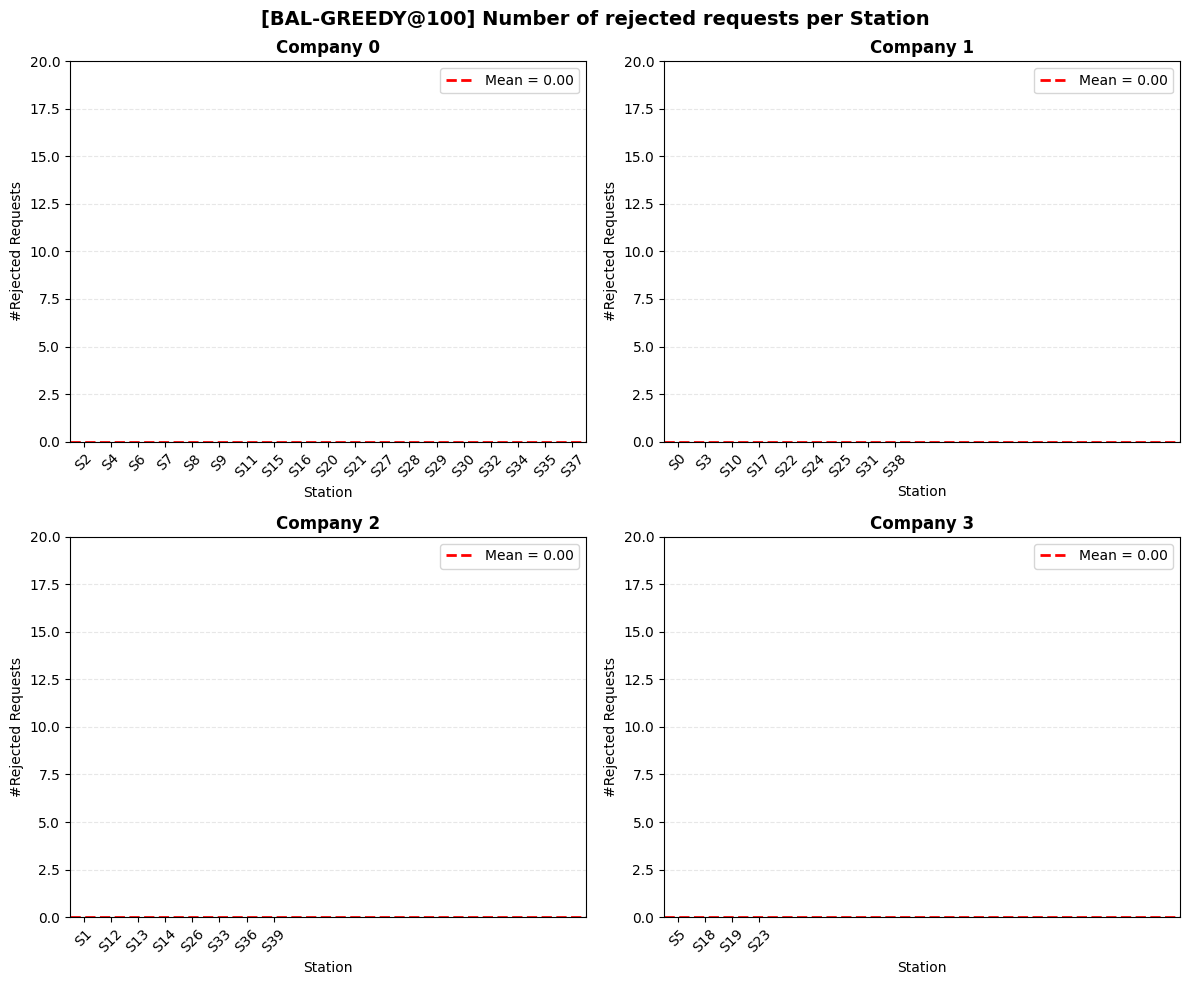

In [68]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [69]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [70]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [71]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:47:47.647 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:47:48.105 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:47:49.040 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:47:49.557 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:47:50.694 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:47:52.028 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:47:52.470 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:47:53.256 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:47:53.792 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:47:55.118 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:47:56.654 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [72]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 46.84 kWh
  Station 1: 10.18 kWh
  Station 2: 41.23 kWh
  Station 3: 5.17 kWh
  Station 4: 8.98 kWh
  Station 5: 103.99 kWh
  Station 6: 10.72 kWh
  Station 7: 0.00 kWh
  Station 8: 1.67 kWh
  Station 9: 5.43 kWh
  Station 10: 11.11 kWh
  Station 11: 28.90 kWh
  Station 12: 4.26 kWh
  Station 13: 107.66 kWh
  Station 14: 4.43 kWh
  Station 15: 21.77 kWh
  Station 16: 1.87 kWh
  Station 17: 5.95 kWh
  Station 18: 12.53 kWh
  Station 19: 32.03 kWh
  Station 20: 96.02 kWh
  Station 21: 11.66 kWh
  Station 22: 7.25 kWh
  Station 23: 31.35 kWh
  Station 24: 14.78 kWh
  Station 25: 29.62 kWh
  Station 26: 4.13 kWh
  Station 27: 2.39 kWh
  Station 28: 5.88 kWh
  Station 29: 5.57 kWh
  Station 30: 7.40 kWh
  Station 31: 12.56 kWh
  Station 32: 69.90 kWh
  Station 33: 2.04 kWh
  Station 34: 43.00 kWh
  Station 35: 156.08 kWh
  Station 36: 7.18 kWh
  Station 37: 14.03 kWh
  Station 38: 6.50 kWh
  Station 39: 52.83 kWh

-

In [73]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

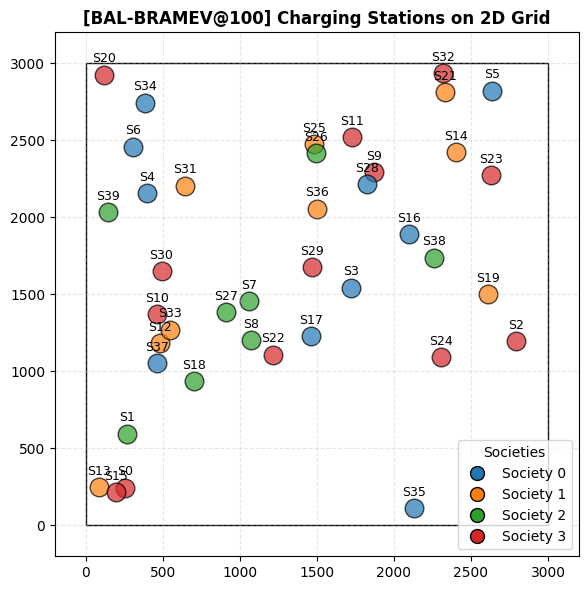

In [74]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

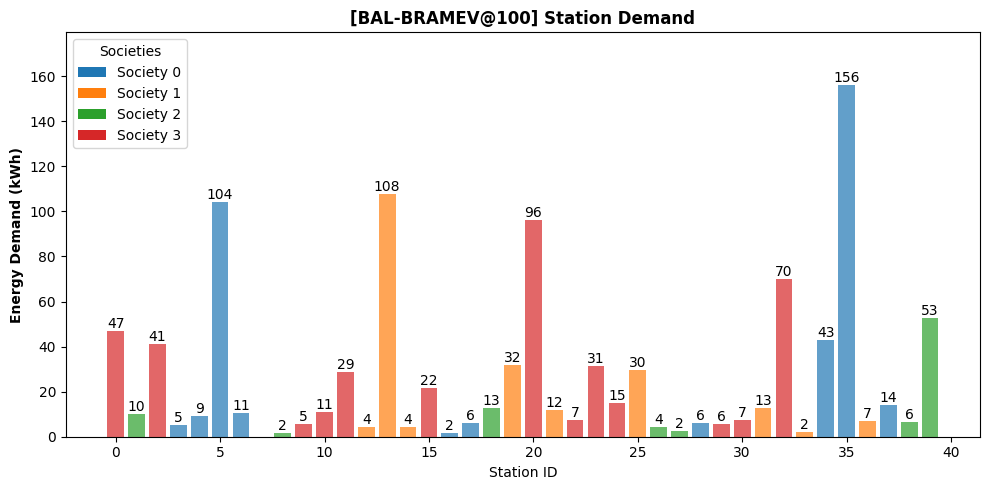

In [75]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

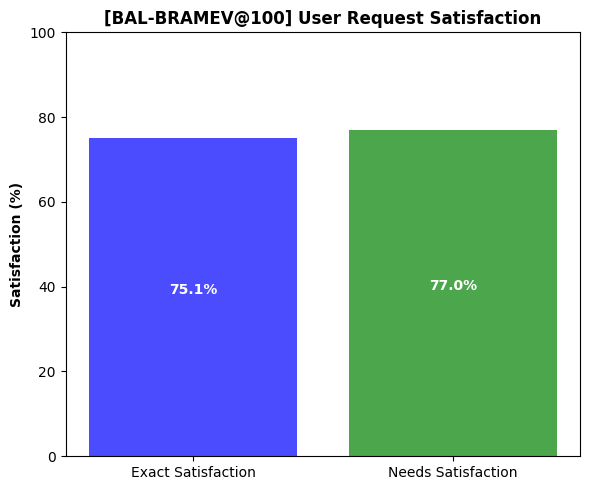

In [76]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

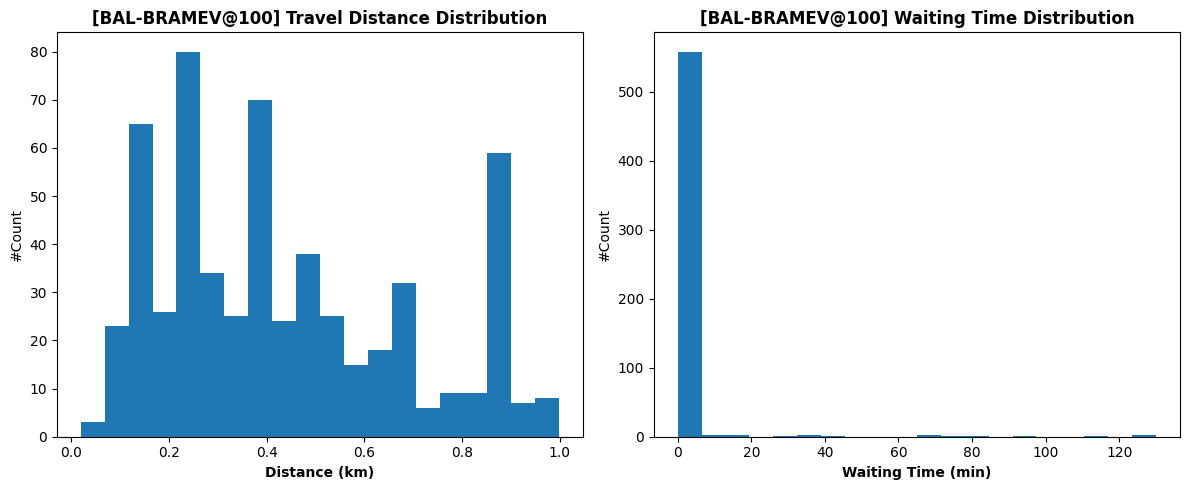

In [77]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

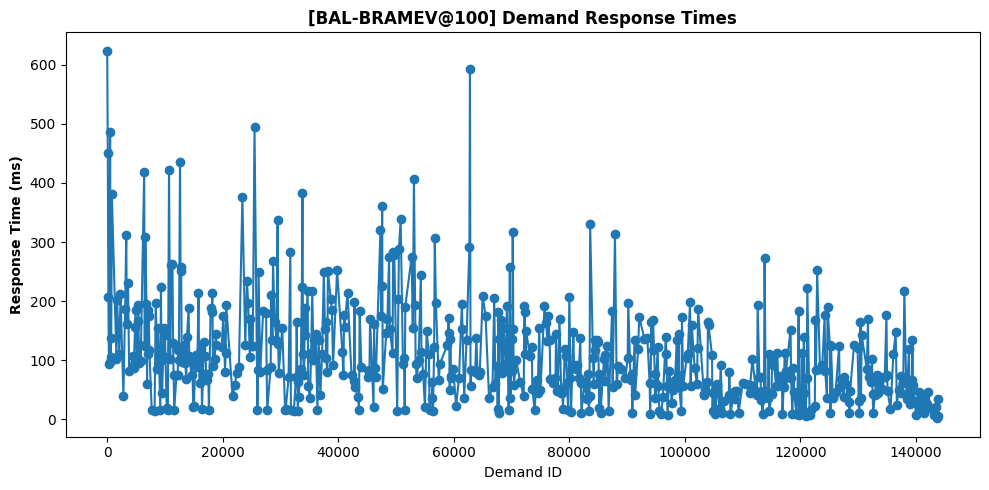

In [78]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

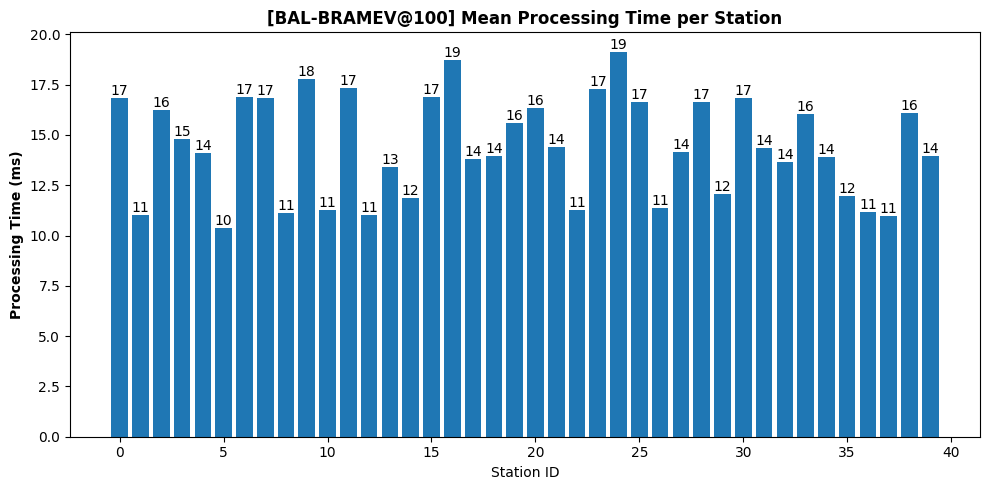

In [79]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

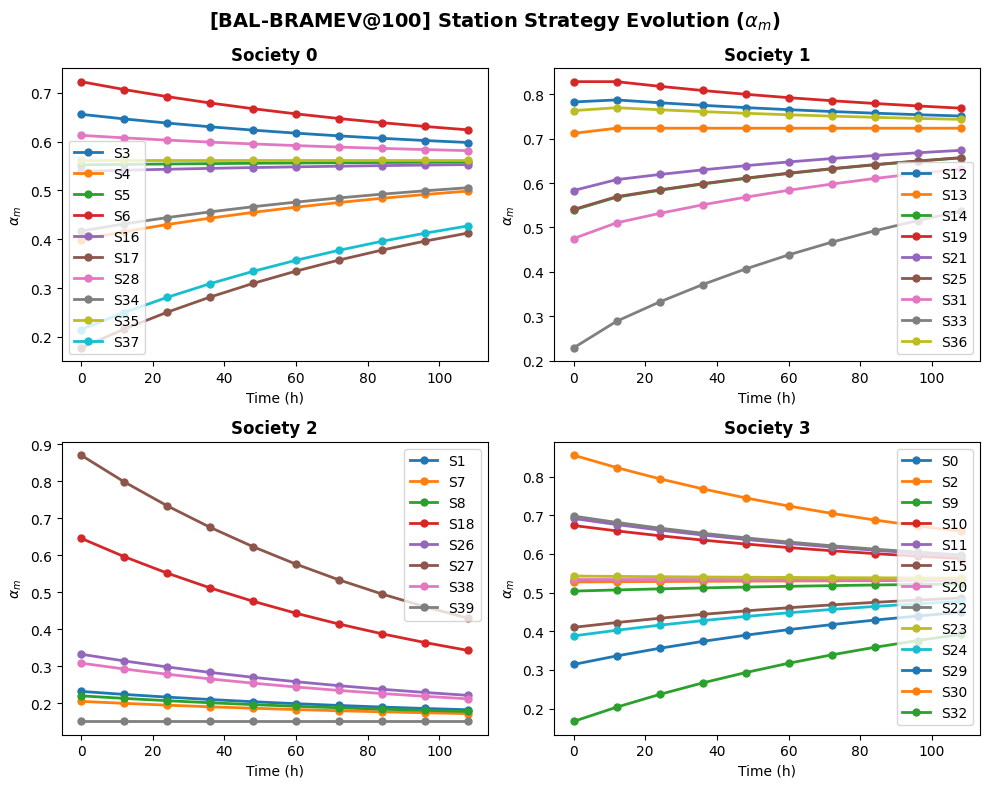

In [80]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [81]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.085417  0.000000  0.000000  0.000000  0.000000   
1            0           4  0.118056  0.000000  0.000000  0.000000  0.000000   
2            0           5  0.480556  0.388194  0.233333  0.257639       NaN   
3            0           6  0.134722  0.018056  0.000000  0.000000  0.000000   
4            0          16  0.038889  0.000000  0.000000  0.000000  0.000000   
5            0          17  0.042361  0.048611  0.000000  0.000000  0.000000   
6            0          28  0.080556  0.000000  0.000000  0.000000  0.000000   
7            0          34  0.361111  0.195139  0.000000  0.031250  0.032639   
8            0          35  0.667361  0.593750  0.384722  0.306944  0.237500   
9            0          37  0.200694  0.020833  0.000000  0.000000       NaN   
10           1          12  0.055556  0.000000  0.000000  0.000000       NaN   
11           1          13  0.533333  0.

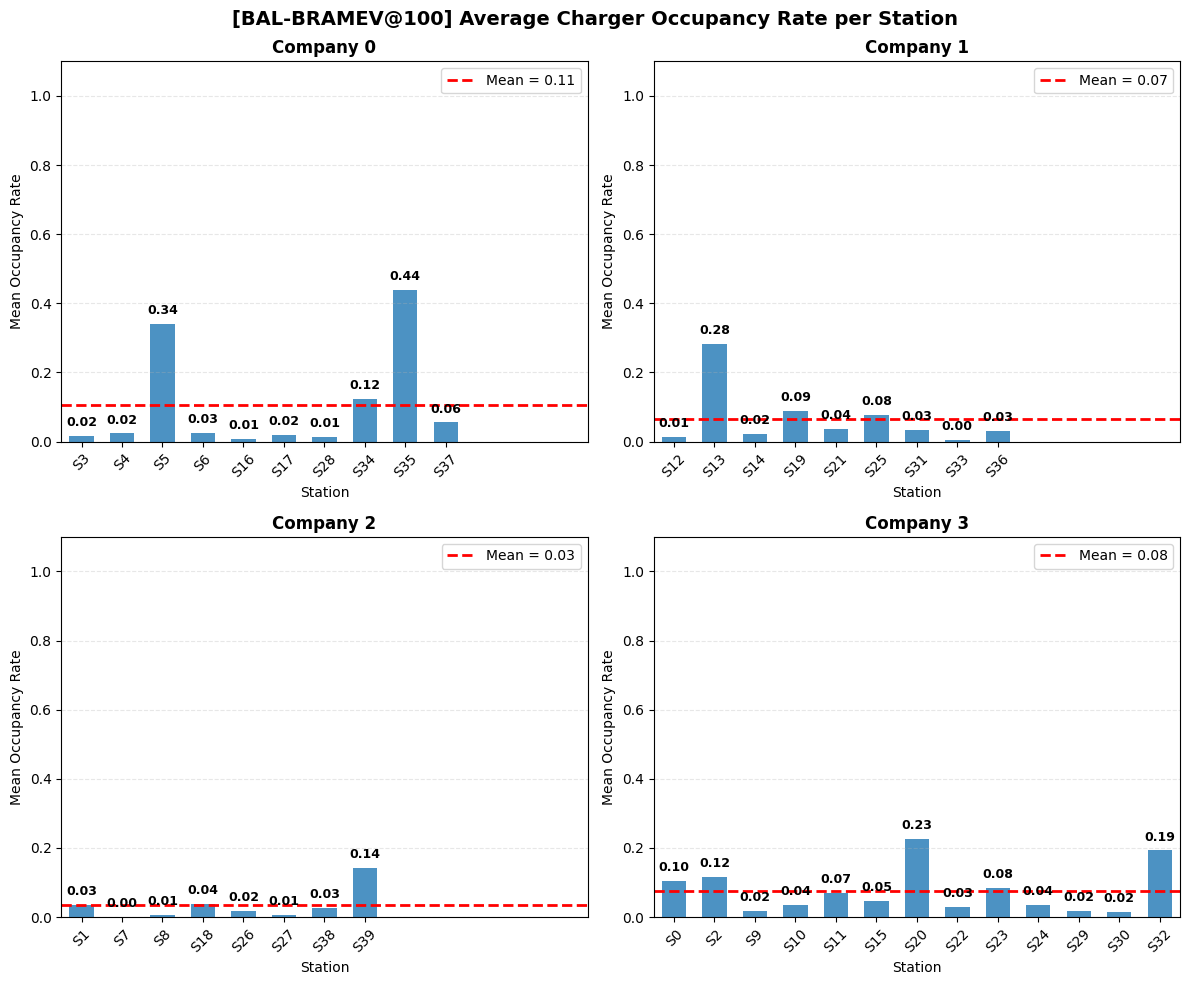

In [82]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

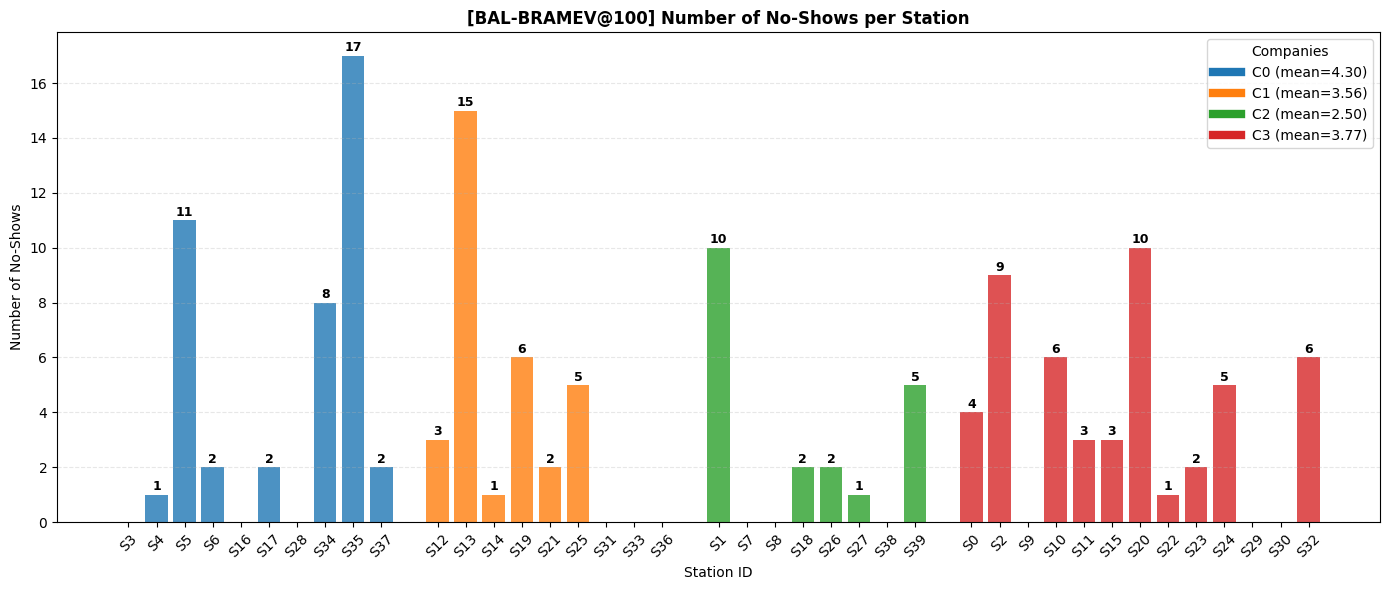

In [83]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [84]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,4,3,0,0,0,0.750000,0.000000,0.000000,0.0
1,0,4,6,5,1,0,0,0.833333,0.166667,0.000000,0.0
2,0,5,69,56,11,0,0,0.811594,0.159420,0.000000,0.0
3,0,6,9,7,2,0,0,0.777778,0.222222,0.000000,0.0
4,0,16,1,1,0,0,0,1.000000,0.000000,0.000000,0.0
5,0,17,5,3,2,0,0,0.600000,0.400000,0.000000,0.0
6,0,28,3,3,0,0,0,1.000000,0.000000,0.000000,0.0
7,0,34,30,22,8,0,0,0.733333,0.266667,0.000000,0.0
8,0,35,110,86,17,2,0,0.781818,0.154545,0.018182,0.0
9,0,37,10,8,2,0,0,0.800000,0.200000,0.000000,0.0


NUMBER OF REJECTED REQUESTS

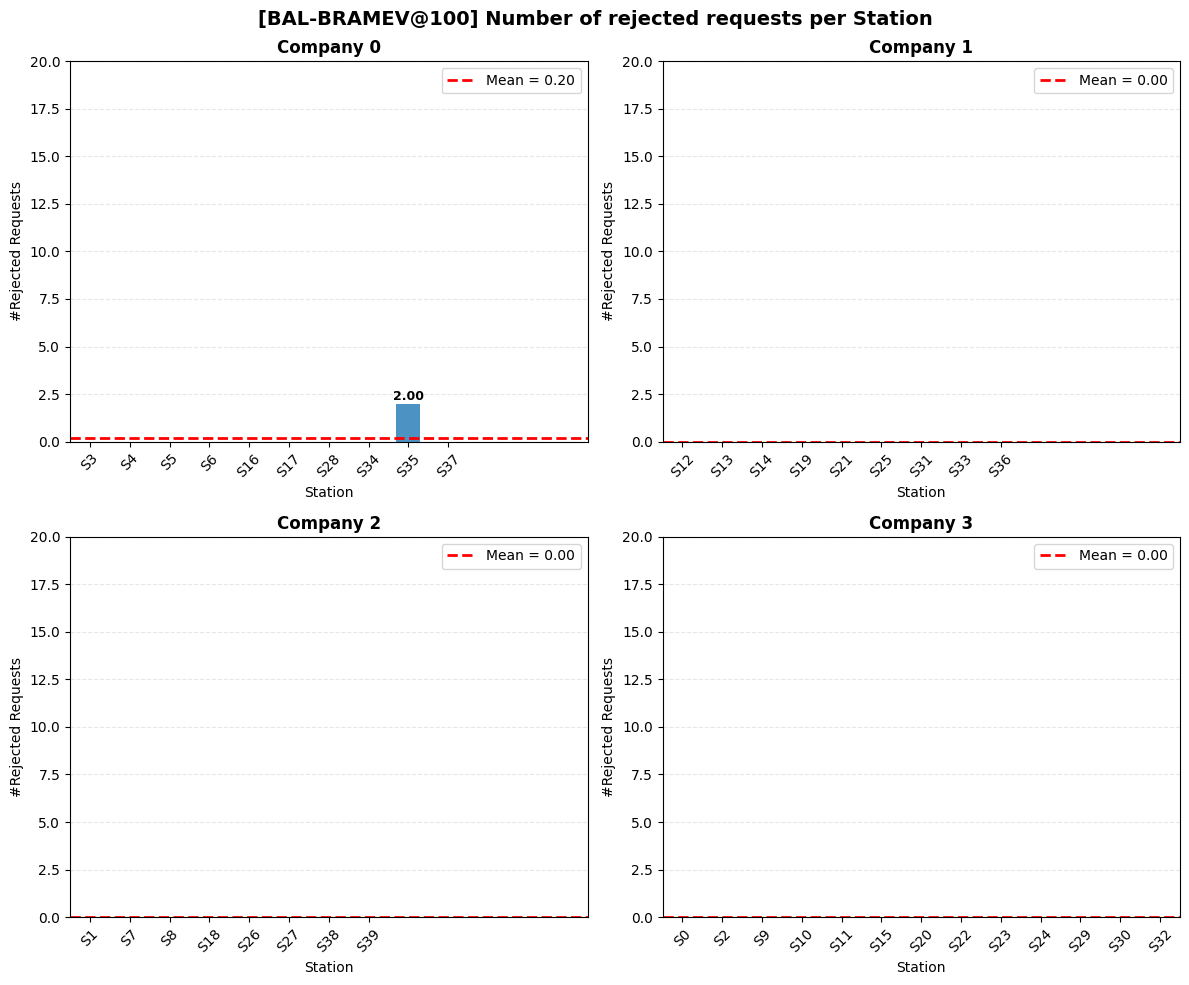

In [85]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [86]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

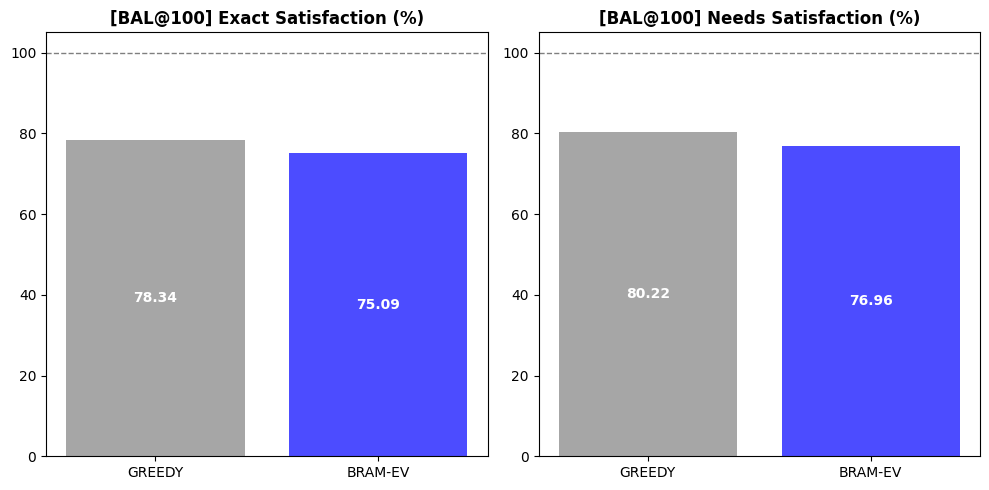

In [87]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

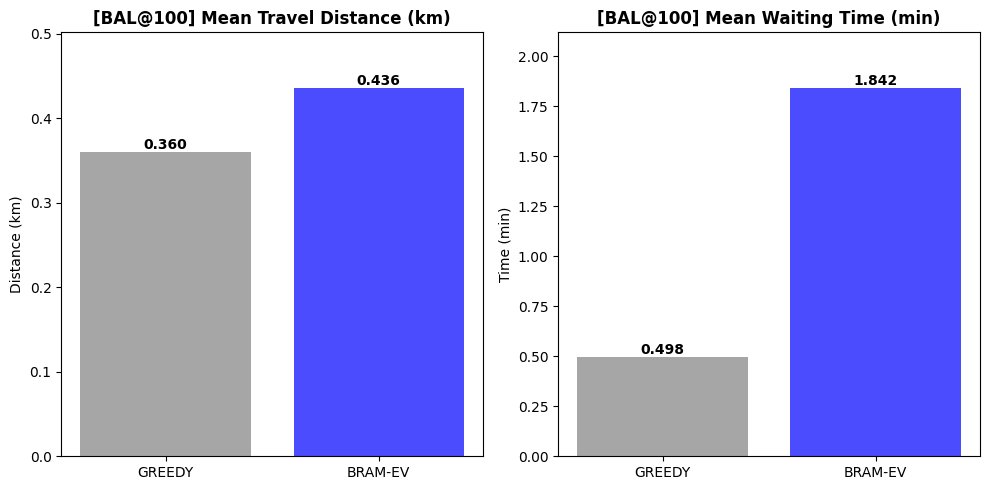

In [88]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

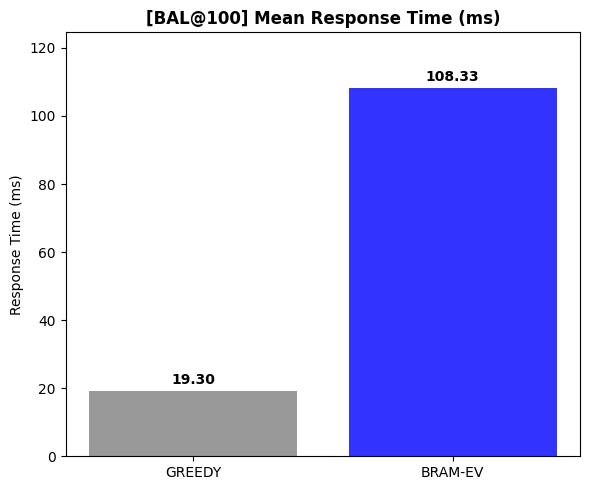

In [89]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [90]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [91]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [92]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [93]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:48:53.064 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:48:53.314 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:48:53.604 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:48:53.829 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:48:54.073 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:48:54.259 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:48:54.383 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:48:54.626 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:48:54.908 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:48:55.273 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:48:55.744 | IN

##### *Metrics*

In [94]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.99 kWh
  Station 1: 3.66 kWh
  Station 2: 1.67 kWh
  Station 3: 0.00 kWh
  Station 4: 58.14 kWh
  Station 5: 7.60 kWh
  Station 6: 15.44 kWh
  Station 7: 89.07 kWh
  Station 8: 1.87 kWh
  Station 9: 5.89 kWh
  Station 10: 7.98 kWh
  Station 11: 1.67 kWh
  Station 12: 10.38 kWh
  Station 13: 11.85 kWh
  Station 14: 4.00 kWh
  Station 15: 176.68 kWh
  Station 16: 52.57 kWh
  Station 17: 214.28 kWh
  Station 18: 226.23 kWh
  Station 19: 7.41 kWh
  Station 20: 11.28 kWh
  Station 21: 9.14 kWh
  Station 22: 6.65 kWh
  Station 23: 1.85 kWh
  Station 24: 10.93 kWh
  Station 25: 91.93 kWh
  Station 26: 207.13 kWh
  Station 27: 0.00 kWh
  Station 28: 18.51 kWh
  Station 29: 10.68 kWh
  Station 30: 5.15 kWh
  Station 31: 5.60 kWh
  Station 32: 3.38 kWh
  Station 33: 62.72 kWh
  Station 34: 30.63 kWh
  Station 35: 4.63 kWh
  Station 36: 26.49 kWh
  Station 37: 67.16 kWh
  Station 38: 46.33 kWh
  Station 39: 83.76 kWh

-

In [95]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

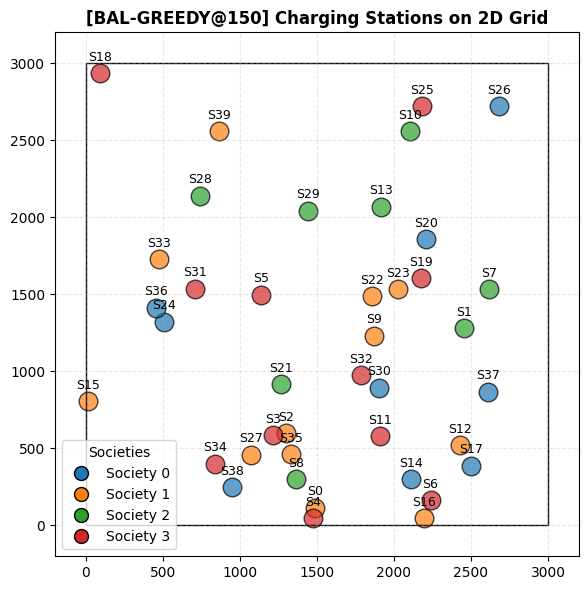

In [96]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

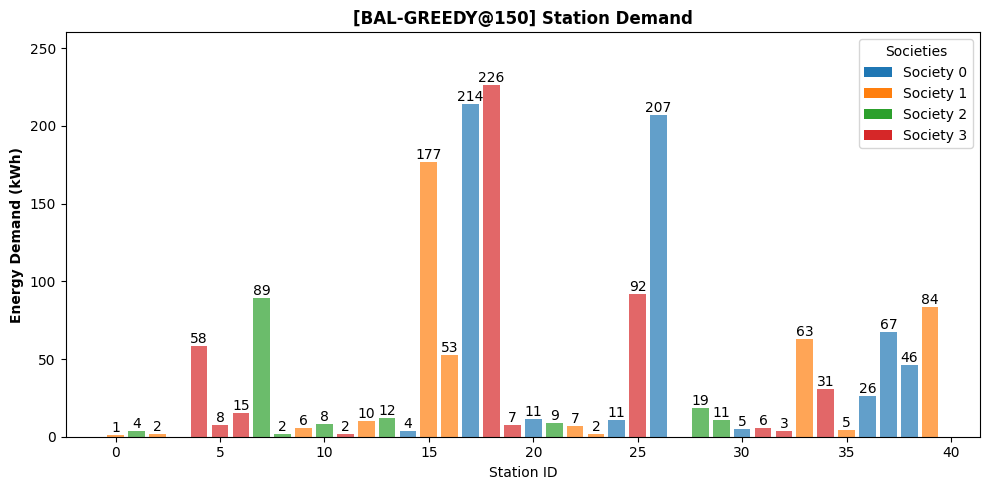

In [97]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

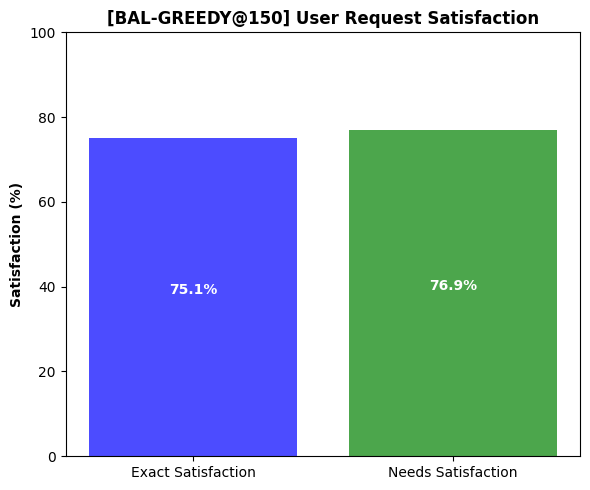

In [98]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

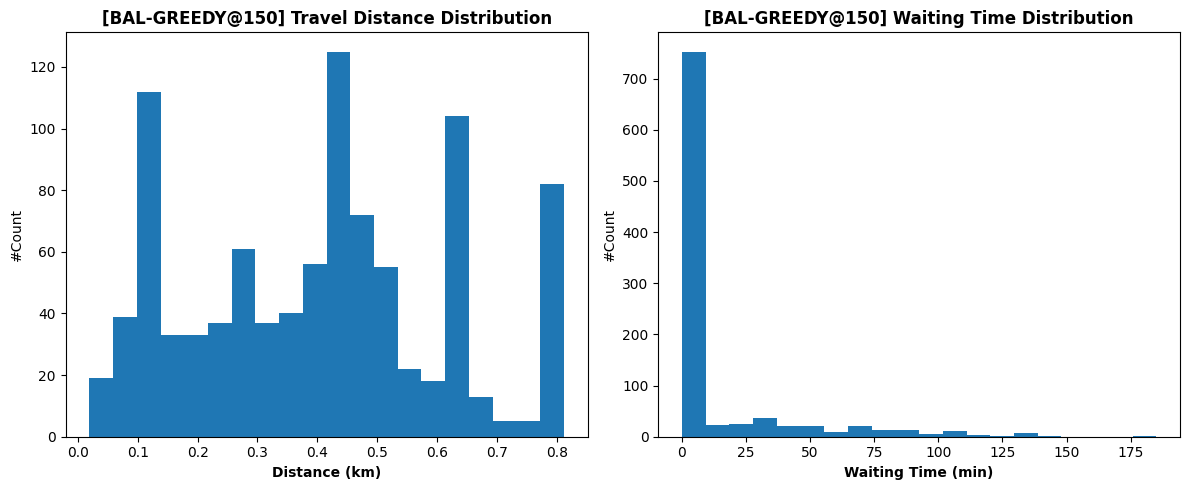

In [99]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

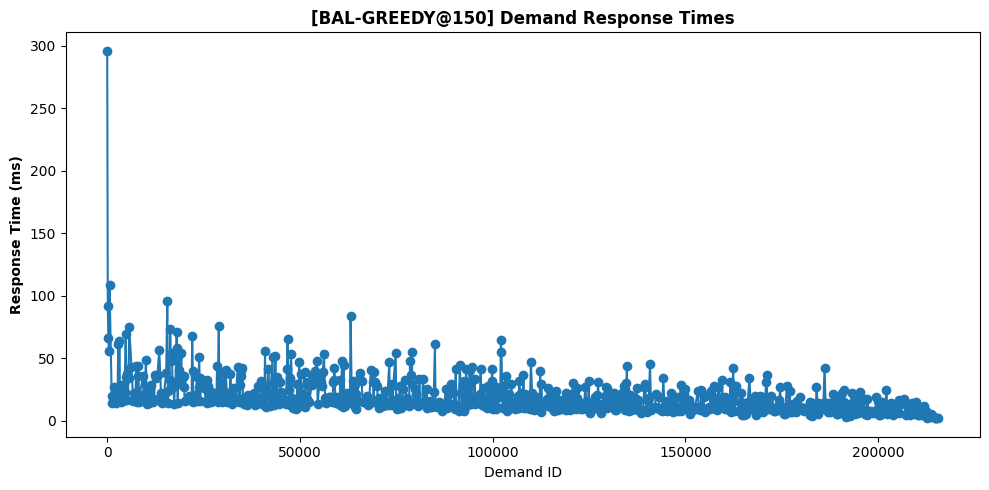

In [100]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

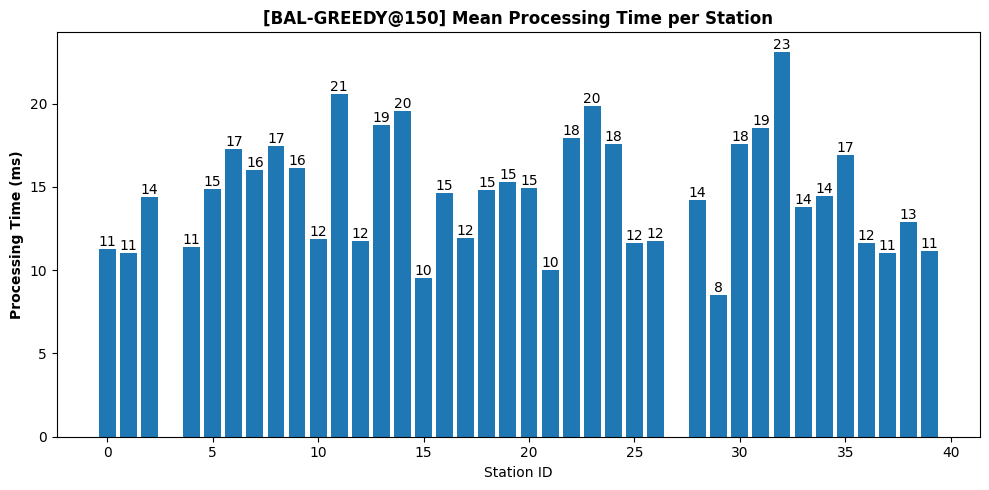

In [101]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [102]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0          14  0.083333  0.000000  0.000000  0.000000  0.000000   
1            0          17  0.759028  0.545833  0.602778  0.668750  0.568056   
2            0          20  0.156944  0.022917  0.000000  0.000000  0.000000   
3            0          24  0.182639  0.000000  0.000000  0.000000  0.000000   
4            0          26  0.739583  0.730556  0.497917  0.560417  0.546528   
5            0          30  0.056250  0.000000  0.000000  0.000000  0.000000   
6            0          36  0.292361  0.100000  0.000000  0.000000       NaN   
7            0          37  0.472917  0.251389  0.106944  0.111111       NaN   
8            0          38  0.365278  0.199306  0.017361  0.024306  0.067361   
9            1           0  0.011806  0.000000  0.000000  0.000000  0.000000   
10           1           2  0.017361  0.000000  0.000000  0.000000  0.000000   
11           1           9  0.086806  0.

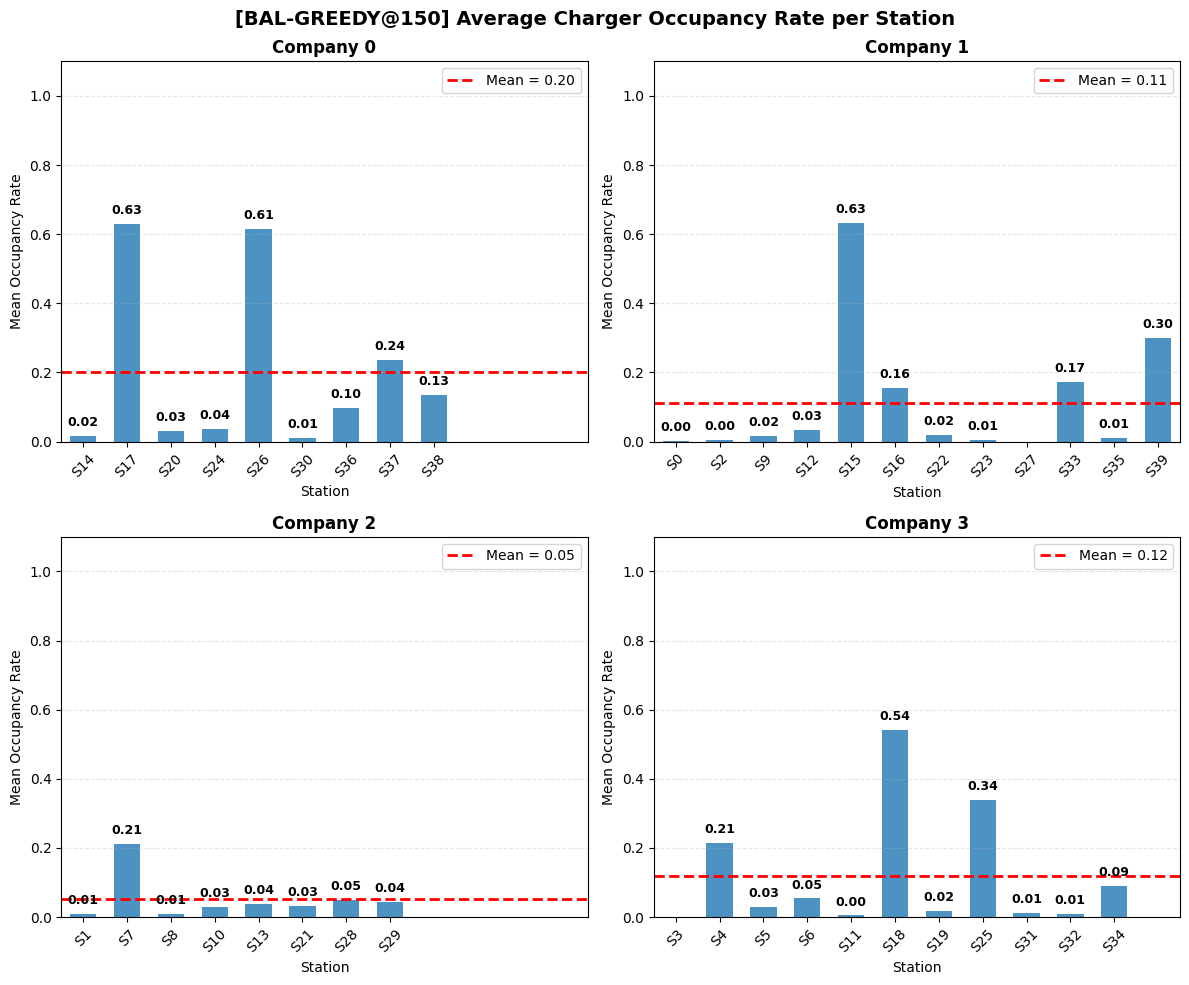

In [103]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

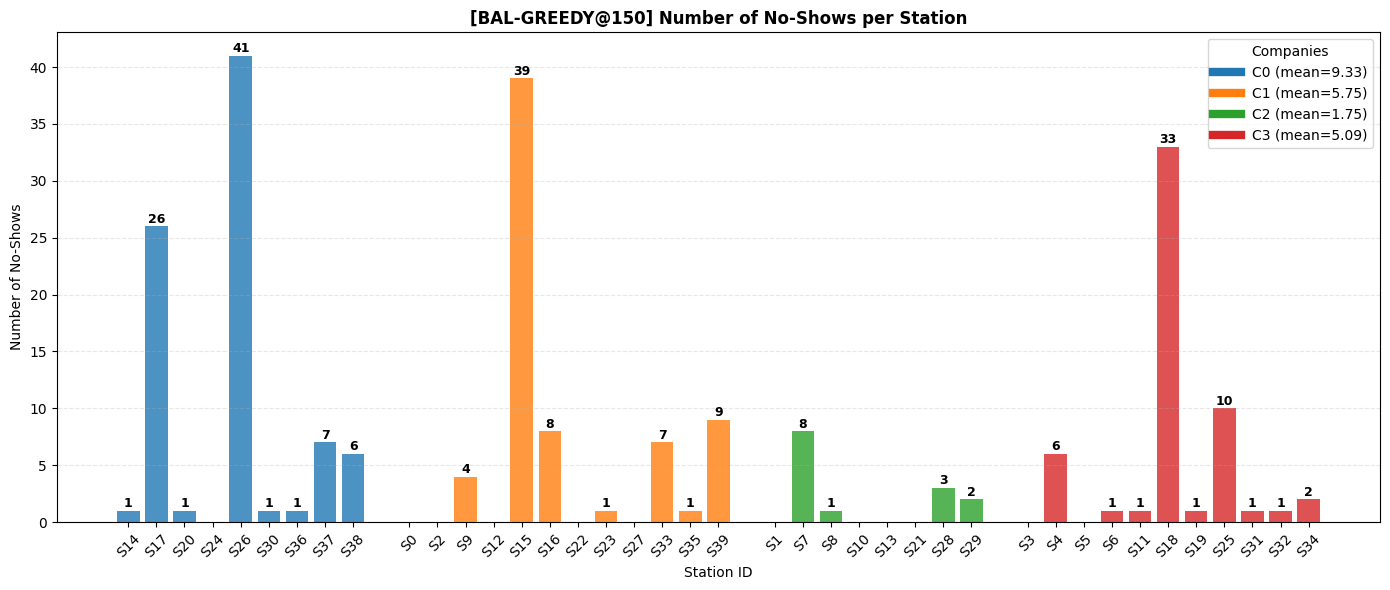

In [104]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [105]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,14,3,2,1,0,0,0.666667,0.333333,0.000000,0.000000
1,0,17,158,130,26,0,0,0.822785,0.164557,0.000000,0.000000
2,0,20,7,6,1,0,0,0.857143,0.142857,0.000000,0.000000
3,0,24,5,5,0,0,0,1.000000,0.000000,0.000000,0.000000
4,0,26,179,134,41,1,0,0.748603,0.229050,0.005587,0.000000
5,0,30,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
6,0,36,17,15,1,0,0,0.882353,0.058824,0.000000,0.000000
7,0,37,46,39,7,0,0,0.847826,0.152174,0.000000,0.000000
8,0,38,33,27,6,0,0,0.818182,0.181818,0.000000,0.000000
9,1,0,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000


NUMBER OF REJECTED REQUESTS

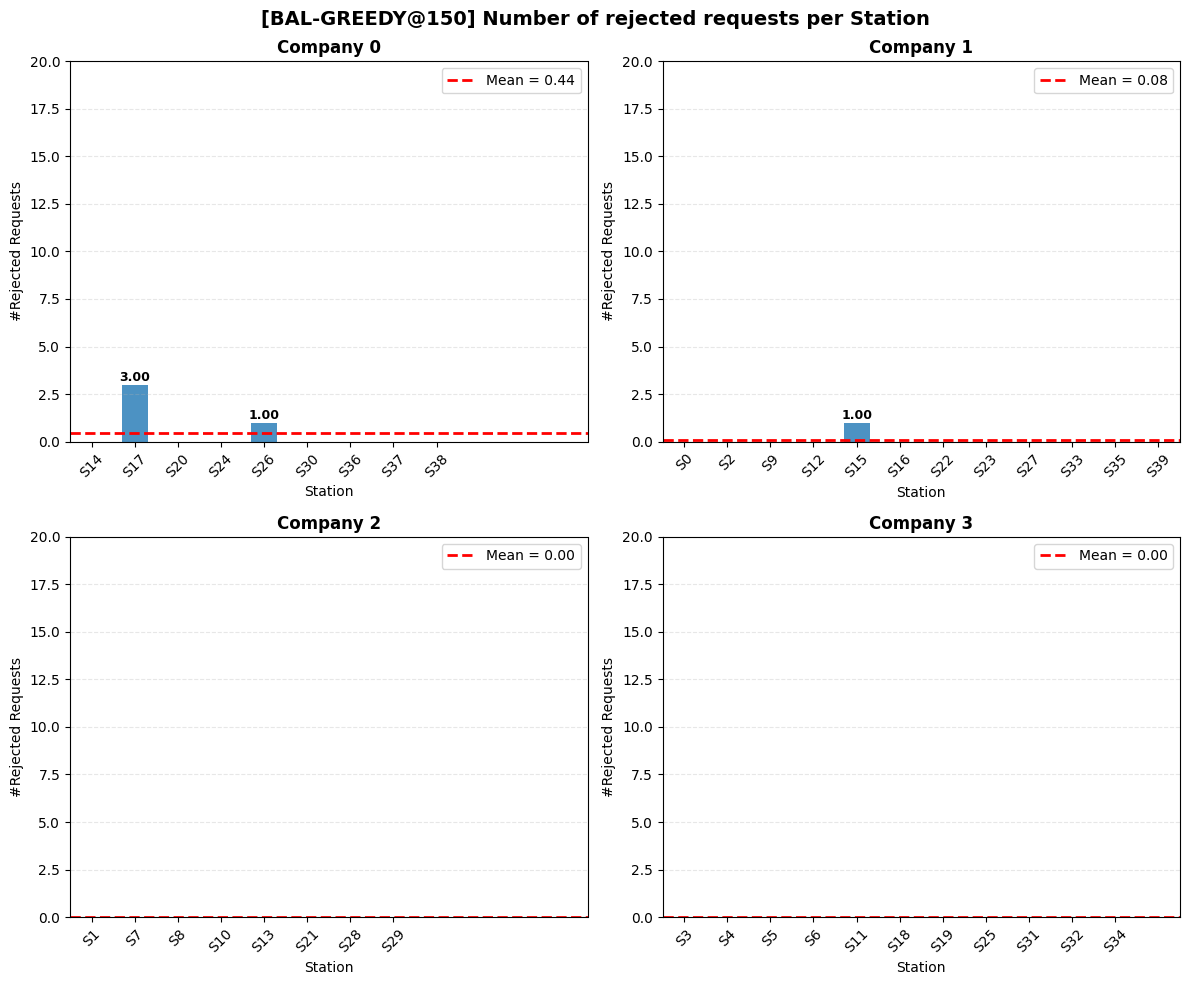

In [106]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [107]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [108]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [109]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:49:15.407 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:49:16.985 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:49:18.464 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:49:20.445 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:49:22.940 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:49:23.870 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:49:24.526 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:49:26.214 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:49:27.855 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:49:28.684 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:49:29.988 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [110]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 23.07 kWh
  Station 1: 32.65 kWh
  Station 2: 40.15 kWh
  Station 3: 4.50 kWh
  Station 4: 2.07 kWh
  Station 5: 156.84 kWh
  Station 6: 14.97 kWh
  Station 7: 14.69 kWh
  Station 8: 127.38 kWh
  Station 9: 160.57 kWh
  Station 10: 32.83 kWh
  Station 11: 12.68 kWh
  Station 12: 44.35 kWh
  Station 13: 66.12 kWh
  Station 14: 6.88 kWh
  Station 15: 43.42 kWh
  Station 16: 9.15 kWh
  Station 17: 14.09 kWh
  Station 18: 2.12 kWh
  Station 19: 8.72 kWh
  Station 20: 37.10 kWh
  Station 21: 30.08 kWh
  Station 22: 13.24 kWh
  Station 23: 61.77 kWh
  Station 24: 15.86 kWh
  Station 25: 81.03 kWh
  Station 26: 1.60 kWh
  Station 27: 20.18 kWh
  Station 28: 30.02 kWh
  Station 29: 11.97 kWh
  Station 30: 11.97 kWh
  Station 31: 21.31 kWh
  Station 32: 66.74 kWh
  Station 33: 8.02 kWh
  Station 34: 58.69 kWh
  Station 35: 42.71 kWh
  Station 36: 21.80 kWh
  Station 37: 169.88 kWh
  Station 38: 27.68 kWh
  Station 39: 4

In [111]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

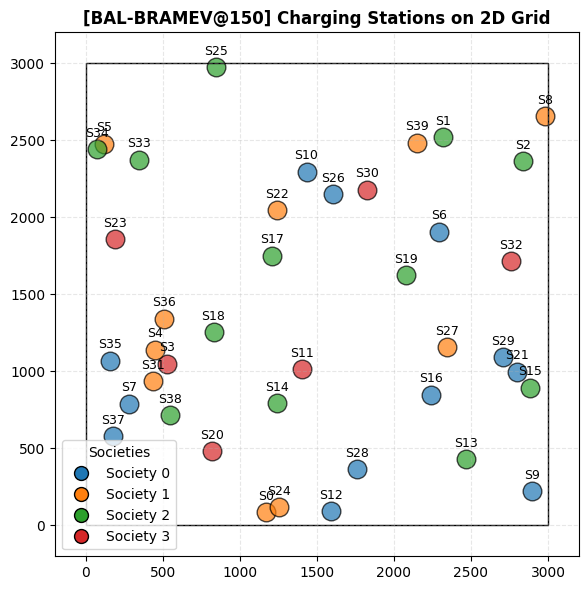

In [112]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

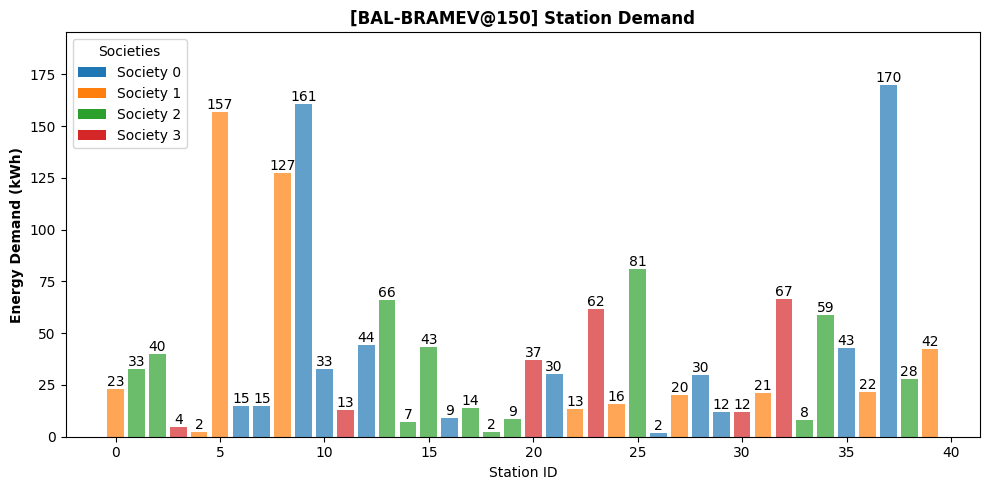

In [113]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

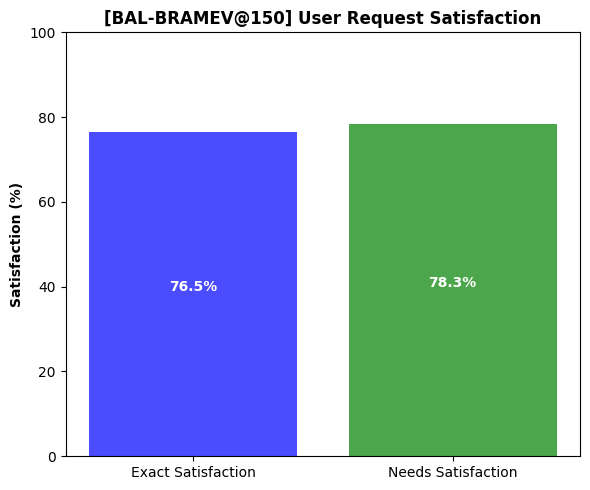

In [114]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

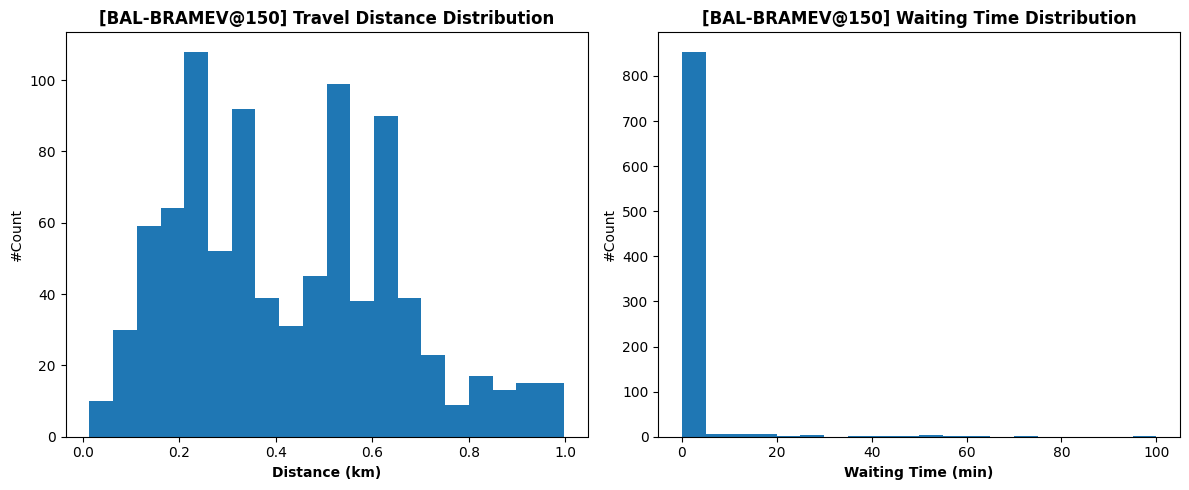

In [115]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

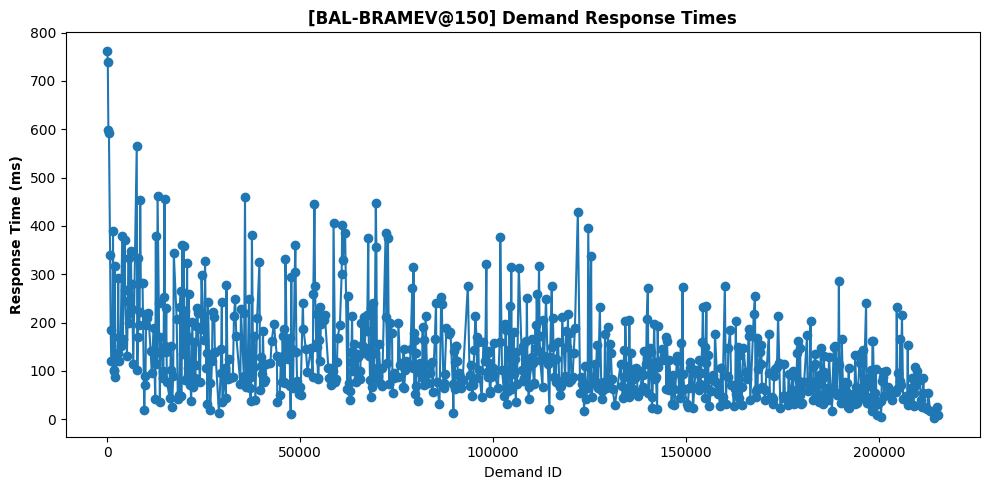

In [116]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

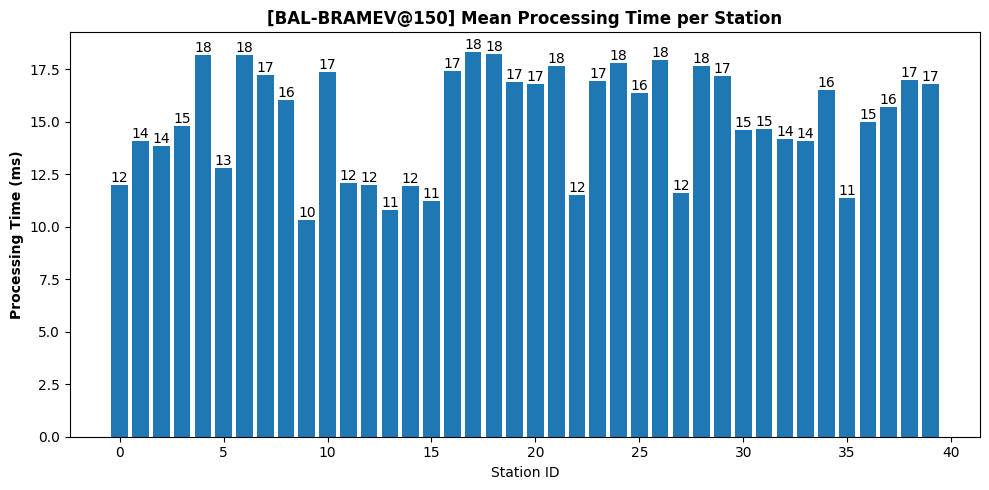

In [117]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

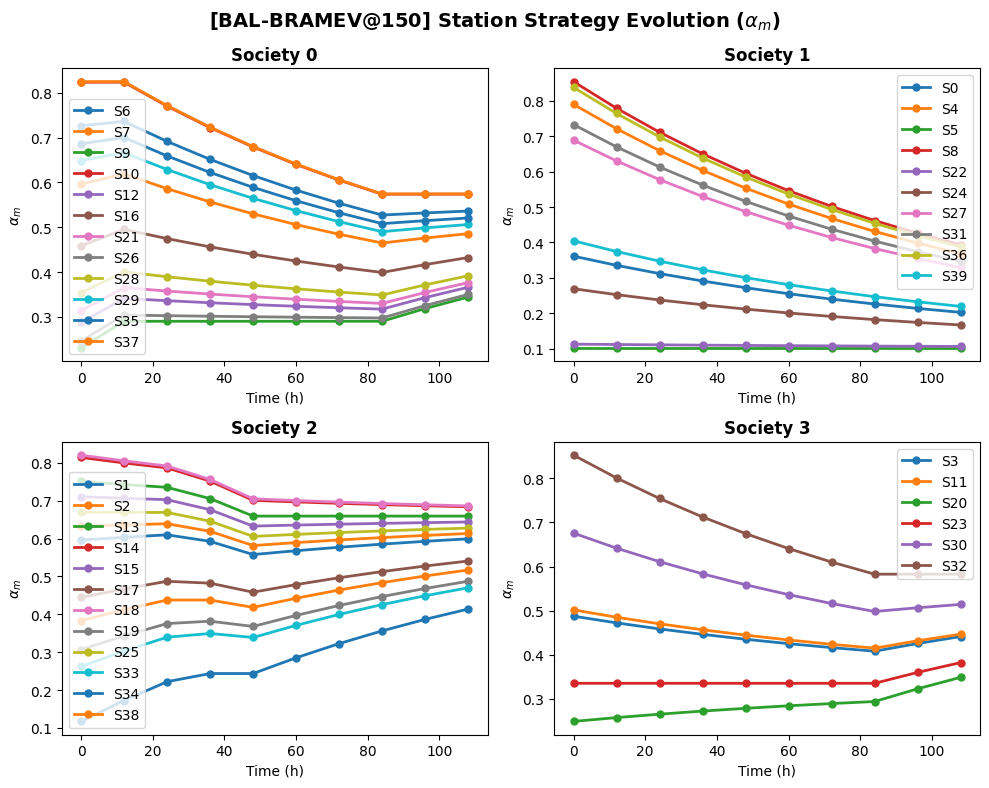

In [118]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [119]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           6  0.225000  0.000000  0.000000  0.000000  0.000000   
1            0           7  0.115972  0.083333  0.000000  0.000000  0.000000   
2            0           9  0.656944  0.637500  0.538889  0.506250       NaN   
3            0          10  0.262500  0.168750  0.038194  0.000000  0.000000   
4            0          12  0.327083  0.204861  0.040278  0.066667       NaN   
5            0          16  0.125694  0.000000  0.000000  0.000000  0.000000   
6            0          21  0.281944  0.106250  0.000000  0.000000  0.000000   
7            0          26  0.016667  0.000000  0.000000  0.000000  0.000000   
8            0          28  0.315972  0.166667  0.000000  0.000000  0.000000   
9            0          29  0.137500  0.018056  0.000000  0.000000  0.000000   
10           0          35  0.403472  0.161111  0.000000  0.081250       NaN   
11           0          37  0.680556  0.

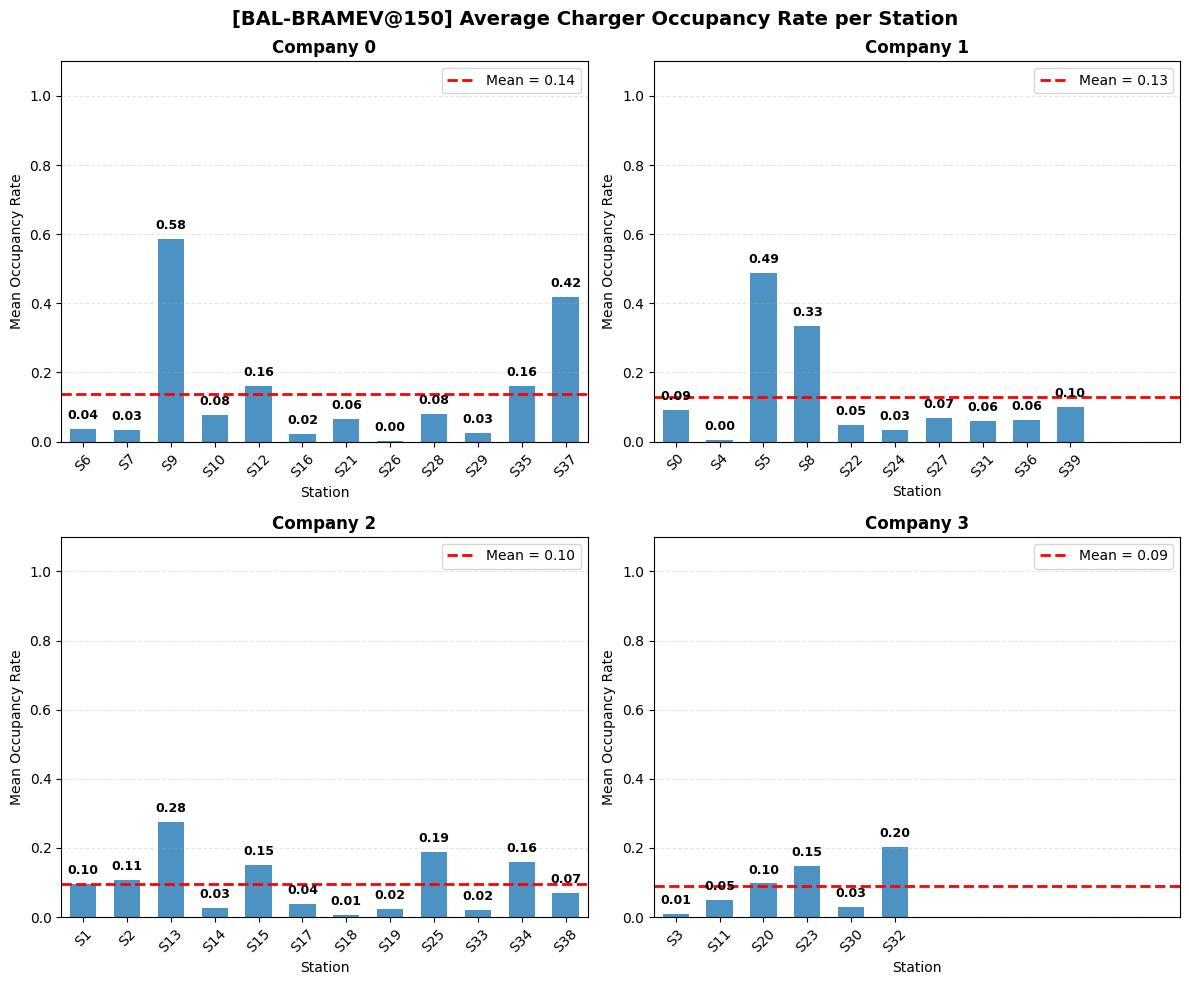

In [120]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

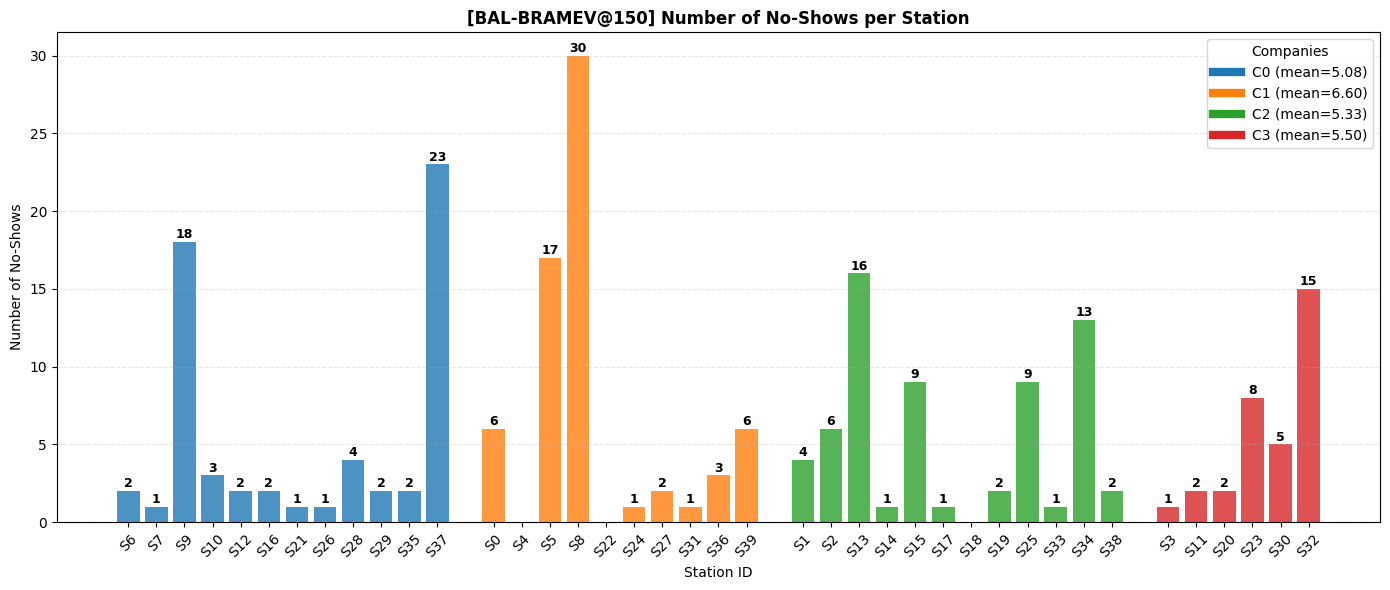

In [121]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [122]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,6,10,8,2,0,0,0.800000,0.200000,0.0,0.0
1,0,7,9,8,1,0,0,0.888889,0.111111,0.0,0.0
2,0,9,103,84,18,0,0,0.815534,0.174757,0.0,0.0
3,0,10,23,19,3,0,0,0.826087,0.130435,0.0,0.0
4,0,12,28,26,2,0,0,0.928571,0.071429,0.0,0.0
5,0,16,7,5,2,0,0,0.714286,0.285714,0.0,0.0
6,0,21,17,16,1,0,0,0.941176,0.058824,0.0,0.0
7,0,26,2,1,1,0,0,0.500000,0.500000,0.0,0.0
8,0,28,21,17,4,0,0,0.809524,0.190476,0.0,0.0
9,0,29,8,6,2,0,0,0.750000,0.250000,0.0,0.0


NUMBER OF REJECTED REQUESTS

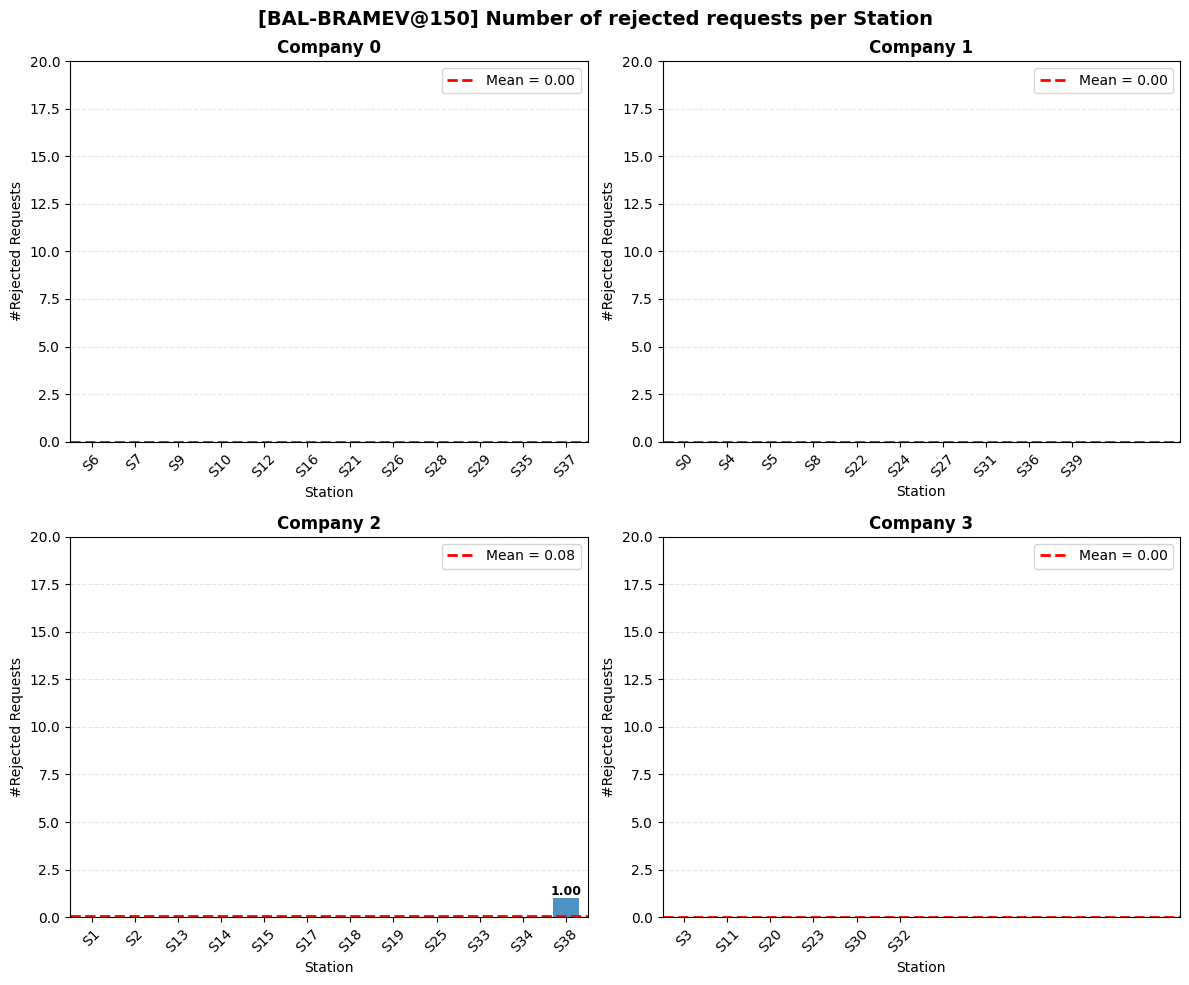

In [123]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [124]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

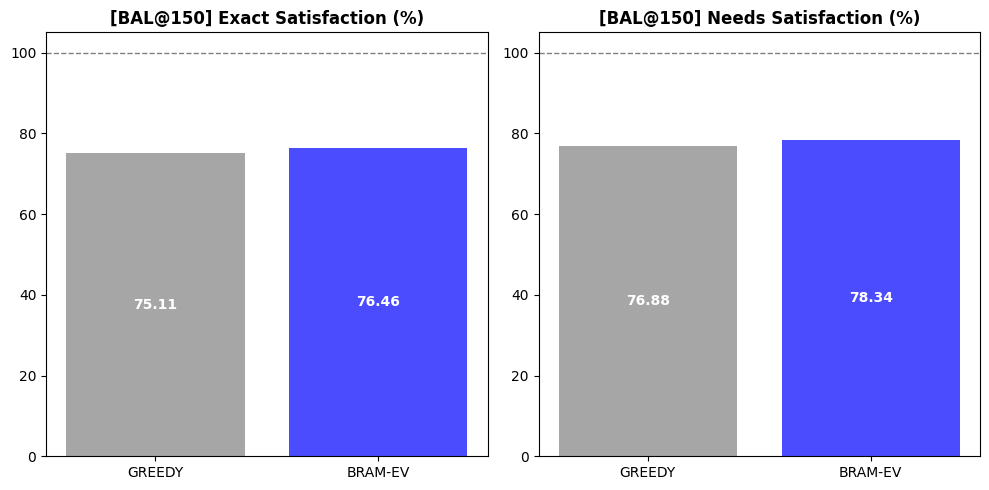

In [125]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

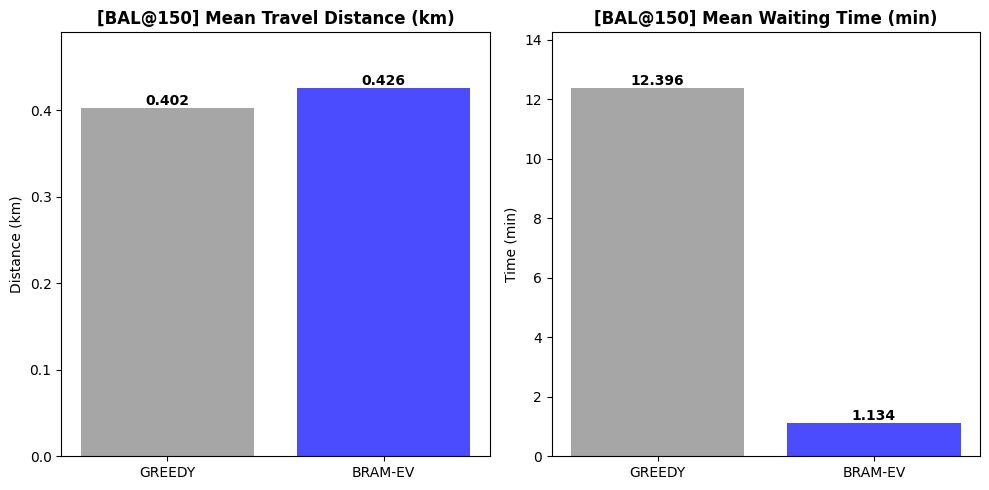

In [126]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

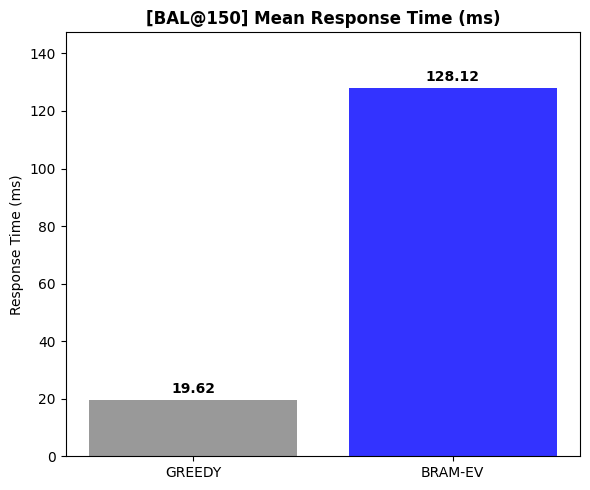

In [127]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [128]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [129]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [130]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [131]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:51:01.287 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:51:01.623 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:51:01.954 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:51:02.245 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:51:02.648 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:51:02.970 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:51:03.409 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:51:03.750 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:51:04.174 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:51:04.526 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:51:04.729 | IN

##### *Metrics*

In [132]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 74.28 kWh
  Station 1: 265.96 kWh
  Station 2: 33.68 kWh
  Station 3: 11.53 kWh
  Station 4: 2.37 kWh
  Station 5: 2.10 kWh
  Station 6: 264.08 kWh
  Station 7: 38.13 kWh
  Station 8: 84.02 kWh
  Station 9: 17.41 kWh
  Station 10: 260.49 kWh
  Station 11: 11.77 kWh
  Station 12: 8.47 kWh
  Station 13: 28.63 kWh
  Station 14: 50.13 kWh
  Station 15: 8.62 kWh
  Station 16: 5.66 kWh
  Station 17: 214.56 kWh
  Station 18: 6.31 kWh
  Station 19: 8.26 kWh
  Station 20: 43.95 kWh
  Station 21: 100.43 kWh
  Station 22: 1.67 kWh
  Station 23: 32.51 kWh
  Station 24: 4.32 kWh
  Station 25: 9.82 kWh
  Station 26: 114.88 kWh
  Station 27: 14.28 kWh
  Station 28: 15.19 kWh
  Station 29: 7.23 kWh
  Station 30: 1.98 kWh
  Station 31: 20.75 kWh
  Station 32: 84.33 kWh
  Station 33: 13.53 kWh
  Station 34: 77.99 kWh
  Station 35: 1.15 kWh
  Station 36: 12.63 kWh
  Station 37: 11.92 kWh
  Station 38: 35.78 kWh
  Station 39: 116.

In [133]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

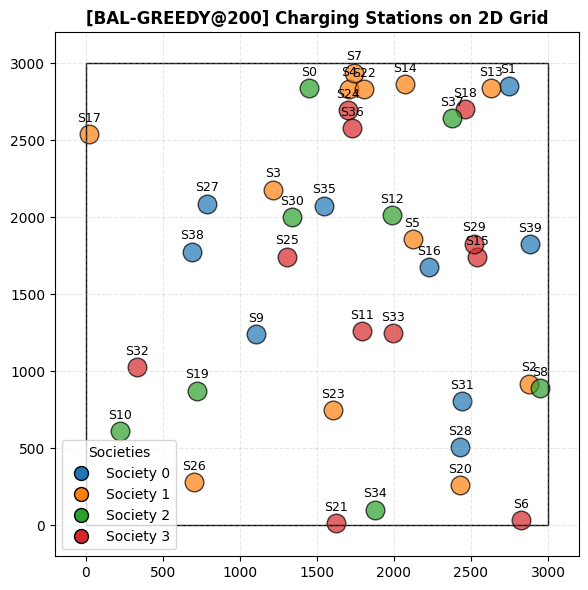

In [134]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

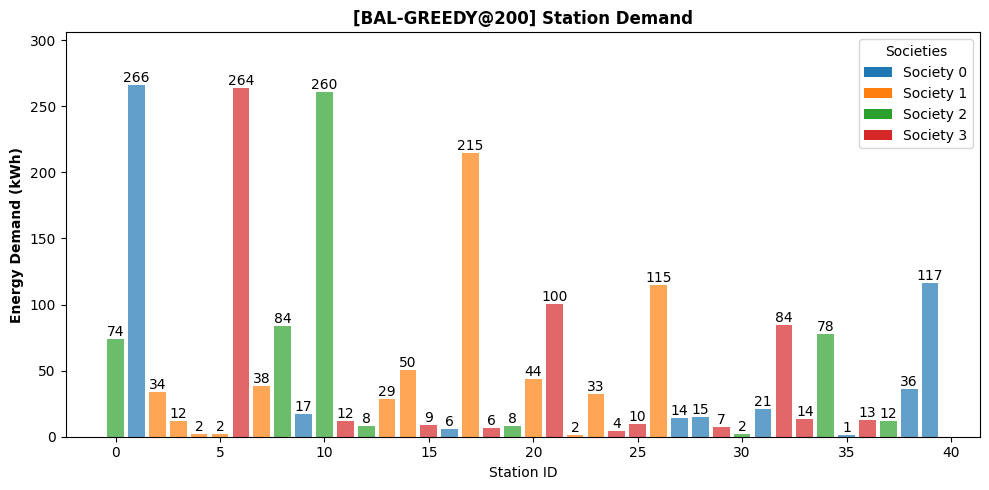

In [135]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

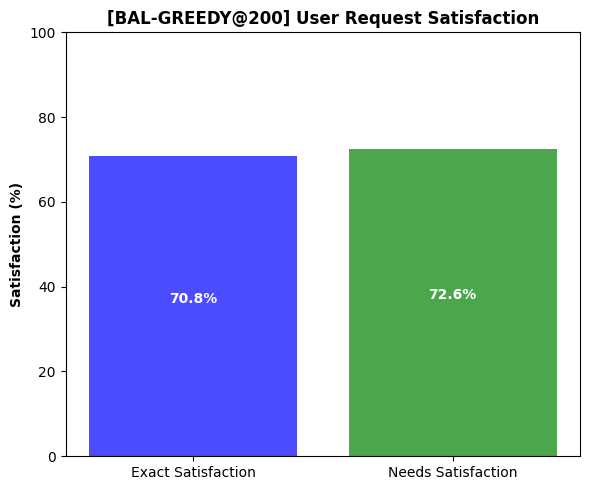

In [136]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

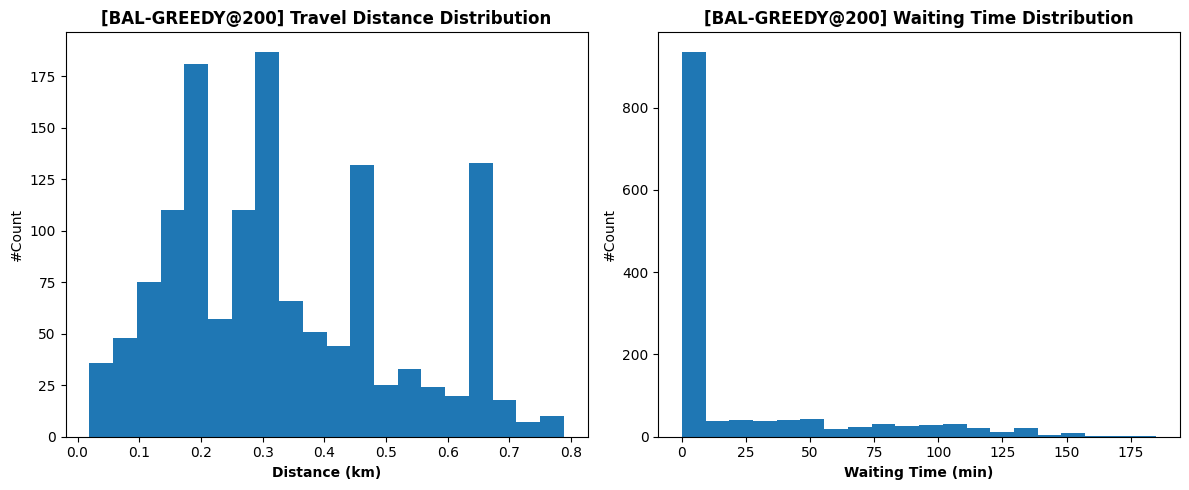

In [137]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

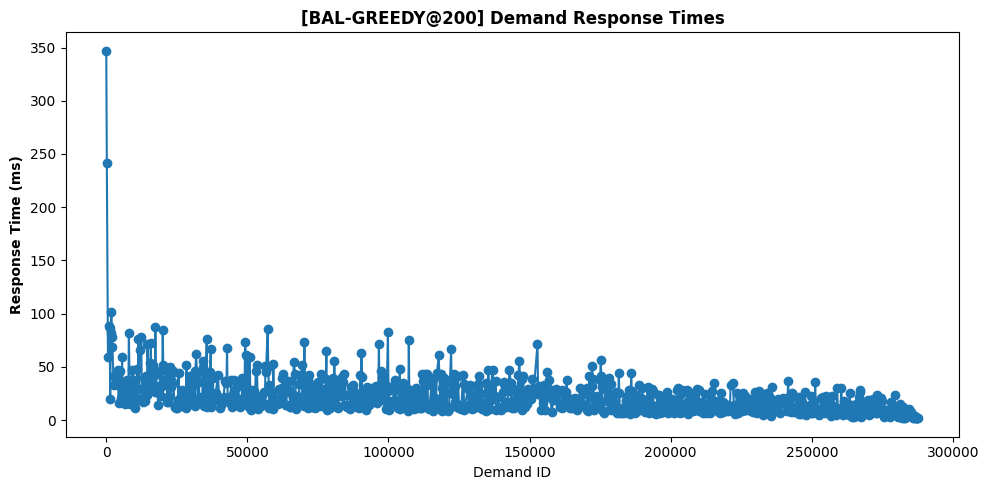

In [138]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

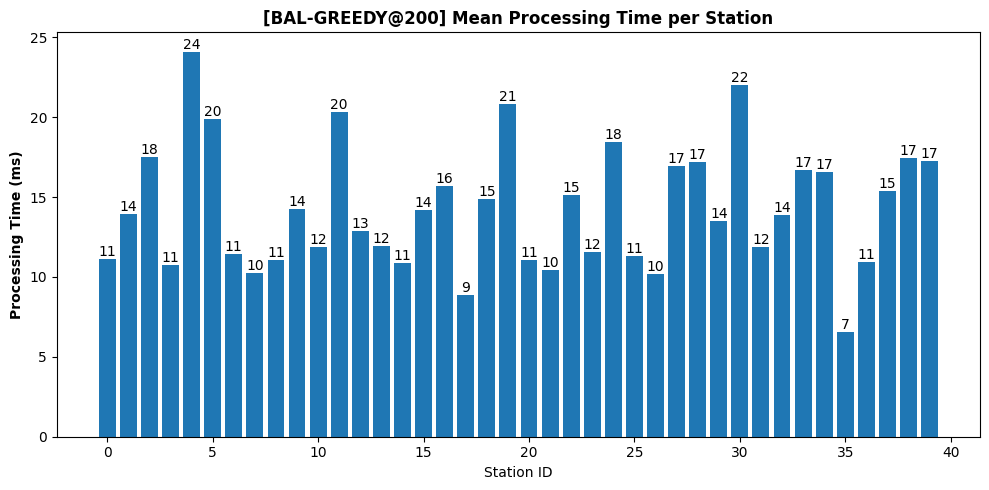

In [139]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [140]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.677778  0.729167  0.672917  0.485417  0.513889   
1            0           9  0.138889  0.045833  0.000000  0.039583       NaN   
2            0          16  0.052083  0.018750  0.000000  0.000000  0.000000   
3            0          27  0.208333  0.029861  0.000000  0.000000  0.000000   
4            0          28  0.187500  0.017361  0.000000  0.000000  0.000000   
5            0          31  0.207639  0.043750  0.000000  0.000000       NaN   
6            0          35  0.015972  0.000000  0.000000  0.000000  0.000000   
7            0          38  0.384722  0.095833  0.000000  0.000000  0.000000   
8            0          39  0.556944  0.549306  0.118056  0.083333  0.221528   
9            1           2  0.296528  0.129861  0.000000  0.000000  0.000000   
10           1           3  0.152778  0.000000  0.000000  0.000000       NaN   
11           1           4  0.049306  0.

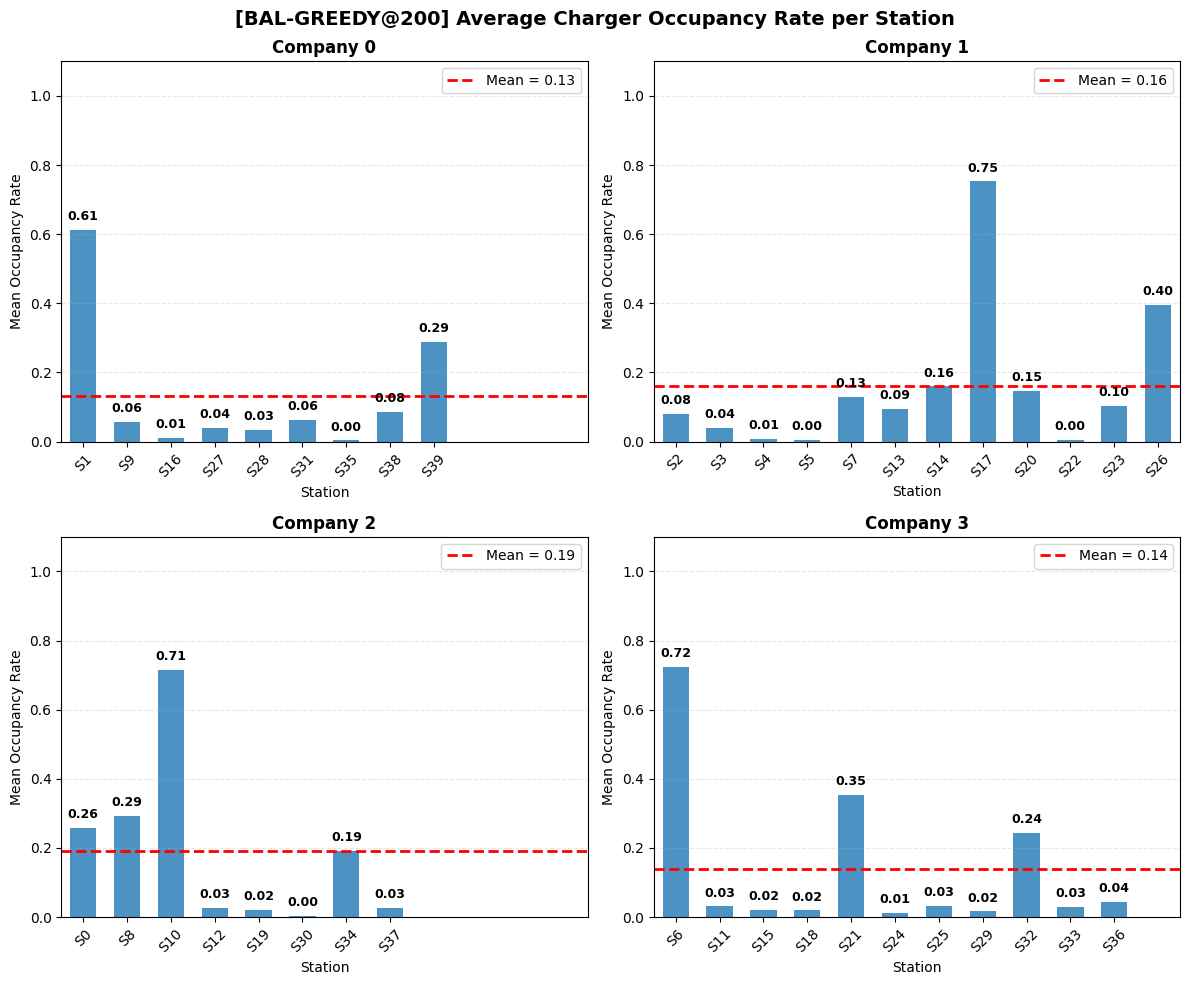

In [141]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

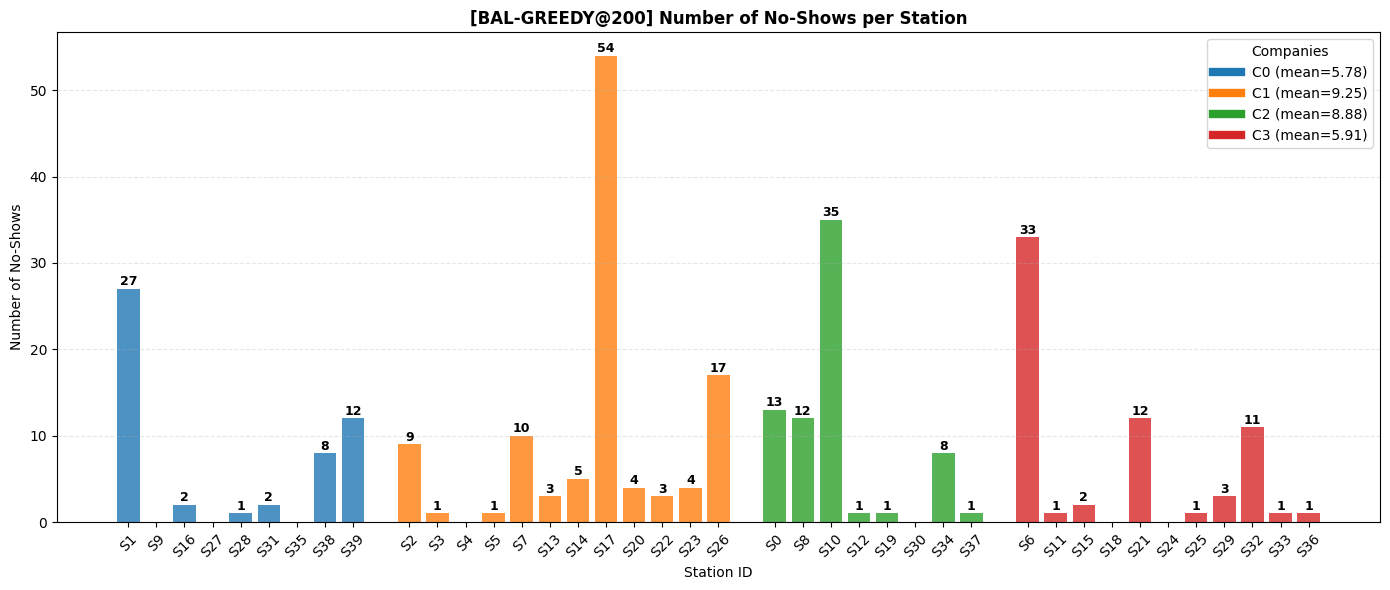

In [142]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [143]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,191,161,27,0,0,0.842932,0.141361,0.000000,0.000000
1,0,9,9,9,0,0,0,1.000000,0.000000,0.000000,0.000000
2,0,16,5,3,2,0,0,0.600000,0.400000,0.000000,0.000000
3,0,27,8,8,0,0,0,1.000000,0.000000,0.000000,0.000000
4,0,28,9,8,1,0,0,0.888889,0.111111,0.000000,0.000000
5,0,31,14,12,2,0,0,0.857143,0.142857,0.000000,0.000000
6,0,35,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
7,0,38,31,22,8,0,0,0.709677,0.258065,0.000000,0.000000
8,0,39,78,66,12,0,0,0.846154,0.153846,0.000000,0.000000
9,1,2,27,18,9,0,0,0.666667,0.333333,0.000000,0.000000


NUMBER OF REJECTED REQUESTS

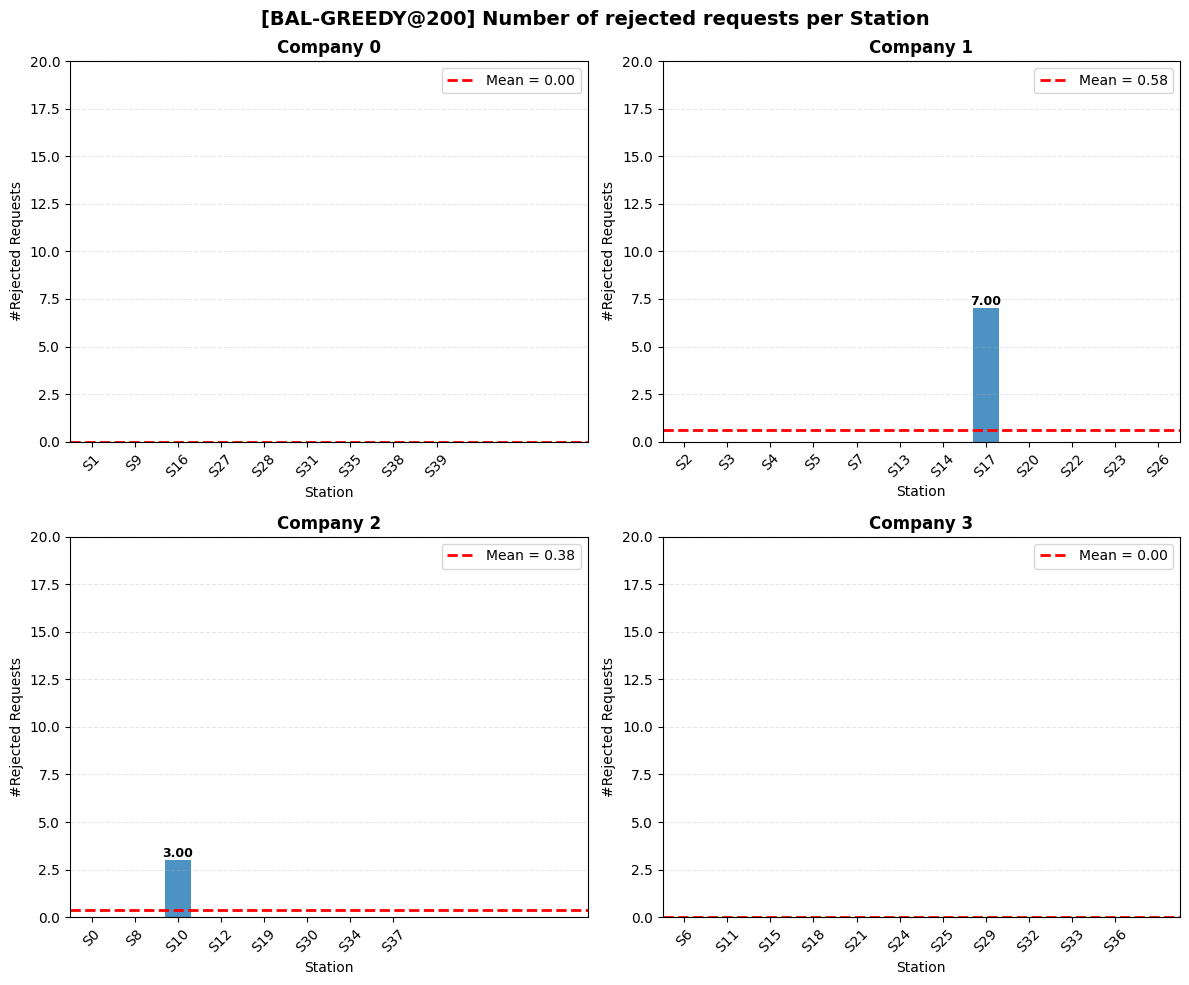

In [144]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [145]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [146]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [147]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:51:34.134 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:51:37.666 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:51:39.409 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:51:41.167 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:51:42.484 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:51:44.031 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:51:44.989 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:51:46.679 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:51:47.634 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:51:49.356 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:51:50.511 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [148]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 35.08 kWh
  Station 1: 102.97 kWh
  Station 2: 49.17 kWh
  Station 3: 48.86 kWh
  Station 4: 46.65 kWh
  Station 5: 127.83 kWh
  Station 6: 9.49 kWh
  Station 7: 68.46 kWh
  Station 8: 2.57 kWh
  Station 9: 2.83 kWh
  Station 10: 88.18 kWh
  Station 11: 28.48 kWh
  Station 12: 11.38 kWh
  Station 13: 35.78 kWh
  Station 14: 6.62 kWh
  Station 15: 6.67 kWh
  Station 16: 18.46 kWh
  Station 17: 10.72 kWh
  Station 18: 50.77 kWh
  Station 19: 7.03 kWh
  Station 20: 27.54 kWh
  Station 21: 9.08 kWh
  Station 22: 13.77 kWh
  Station 23: 84.56 kWh
  Station 24: 11.56 kWh
  Station 25: 88.22 kWh
  Station 26: 232.03 kWh
  Station 27: 26.68 kWh
  Station 28: 8.68 kWh
  Station 29: 75.97 kWh
  Station 30: 20.50 kWh
  Station 31: 31.01 kWh
  Station 32: 127.43 kWh
  Station 33: 39.69 kWh
  Station 34: 86.46 kWh
  Station 35: 213.68 kWh
  Station 36: 236.57 kWh
  Station 37: 58.49 kWh
  Station 38: 15.84 kWh
  Station 39:

In [149]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

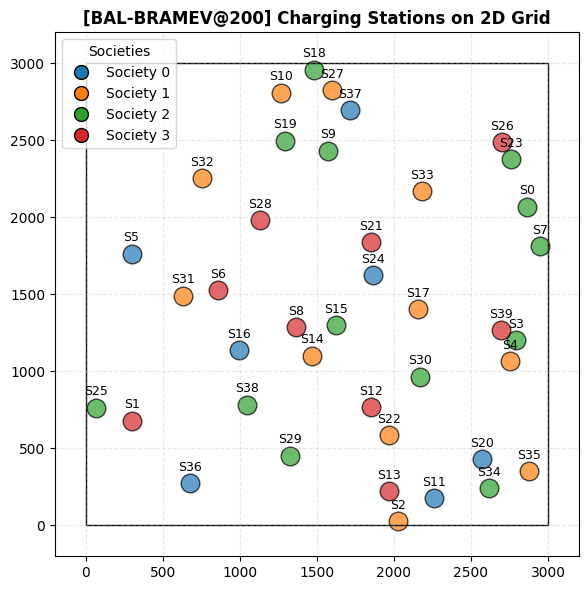

In [150]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

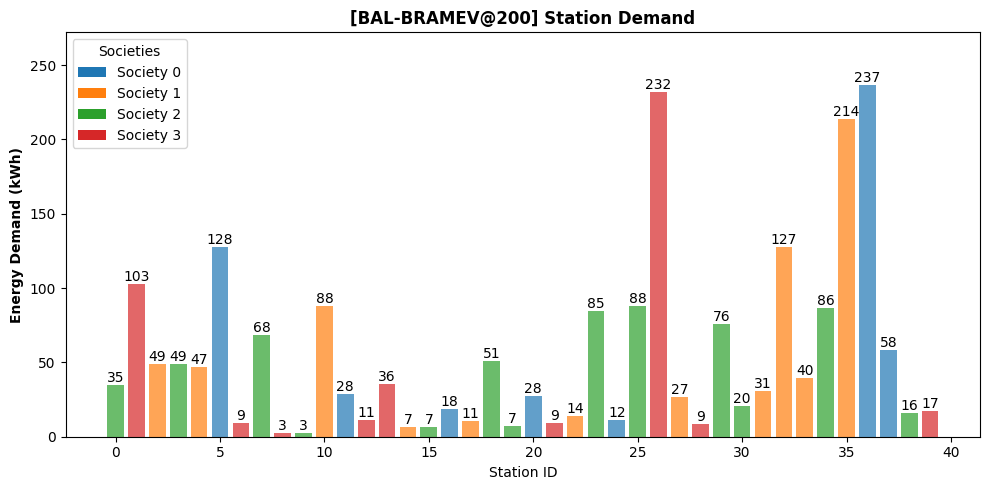

In [151]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

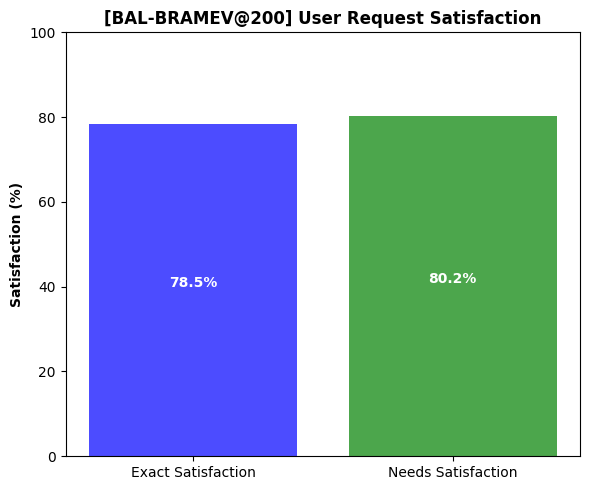

In [152]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

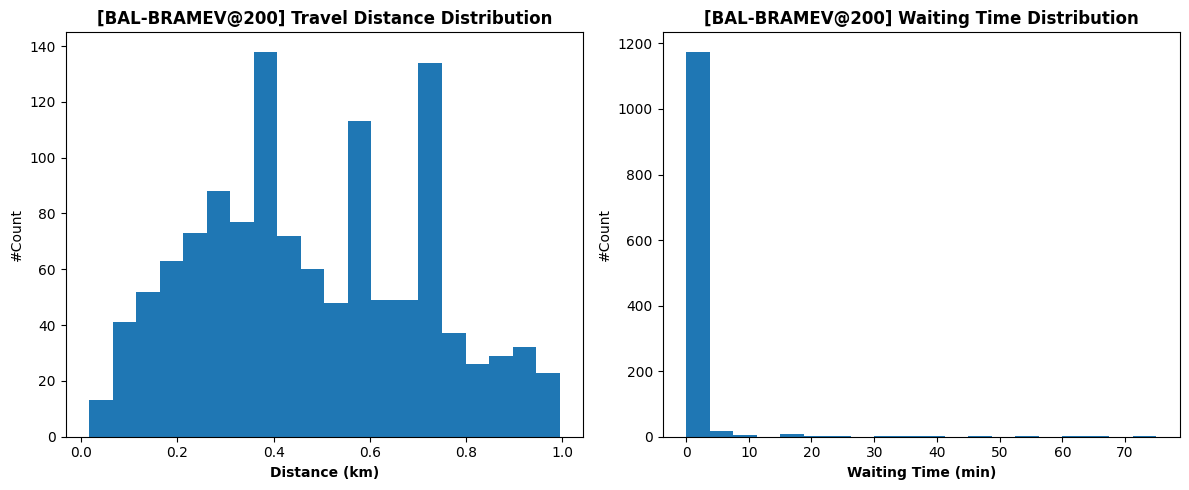

In [153]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

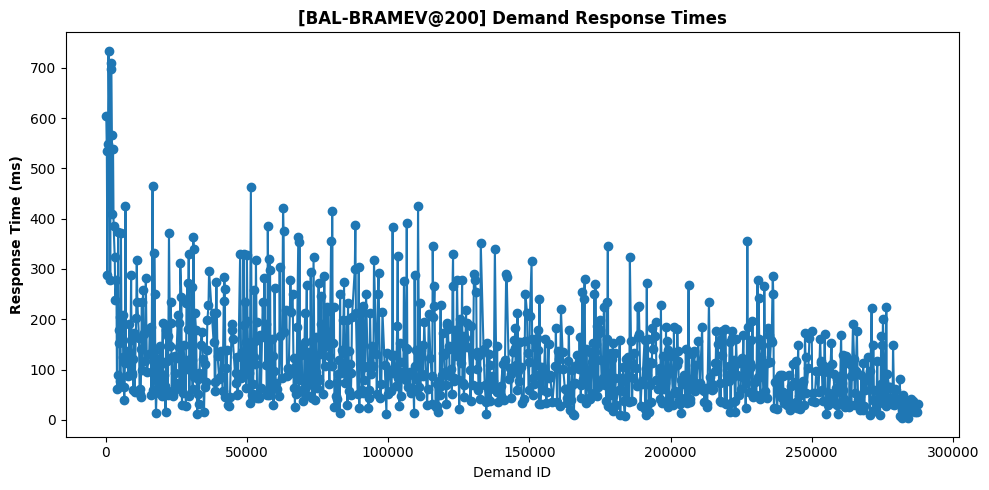

In [154]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

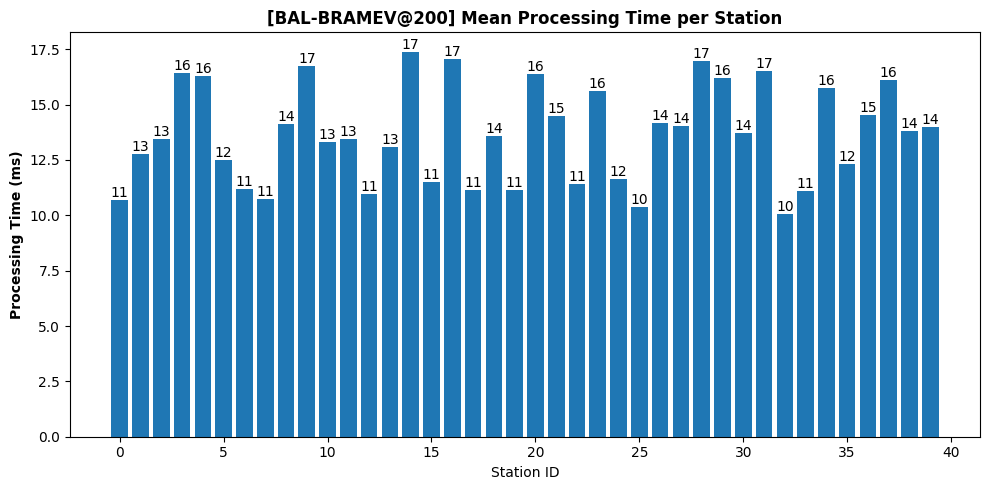

In [155]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

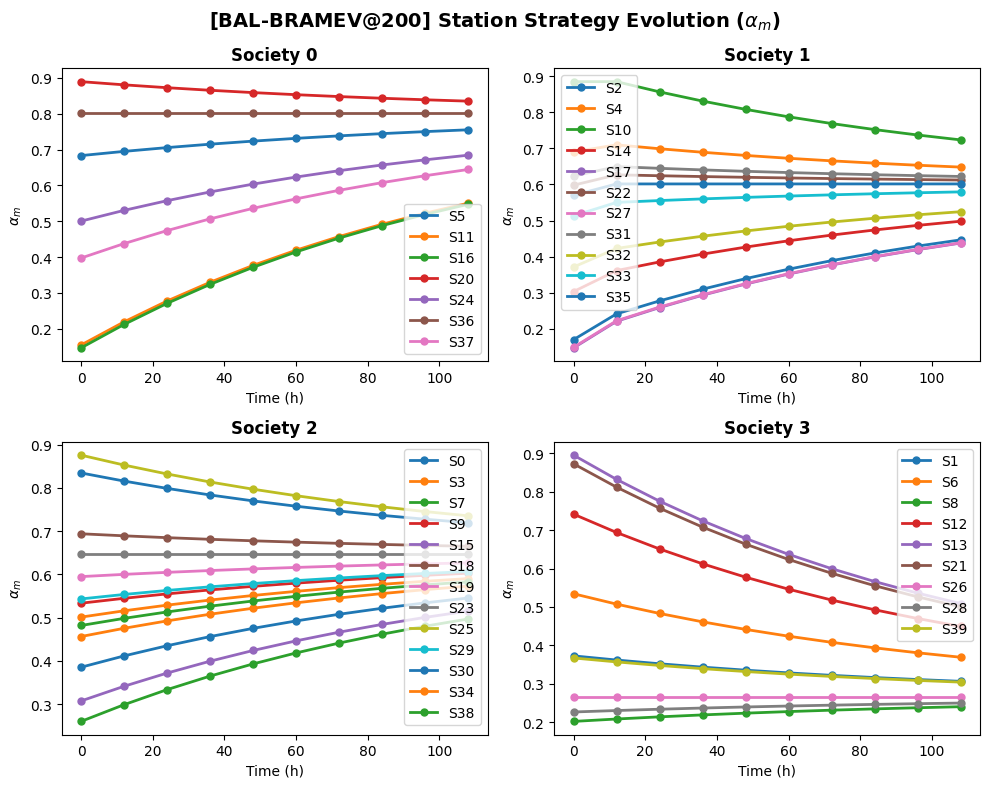

In [156]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [157]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.585417  0.396528  0.318750  0.157639  0.320139   
1            0          11  0.241667  0.114583  0.000000  0.000000  0.025694   
2            0          16  0.219444  0.063194  0.000000  0.000000  0.000000   
3            0          20  0.205556  0.086111  0.017361  0.027083  0.000000   
4            0          24  0.106944  0.036111  0.000000  0.000000       NaN   
5            0          36  0.838194  0.715278  0.581250  0.514583  0.443750   
6            0          37  0.440972  0.250000  0.000000  0.000000  0.024306   
7            1           2  0.438194  0.215278  0.052778  0.000000  0.011111   
8            1           4  0.461111  0.182639  0.020139  0.000000  0.000000   
9            1          10  0.520139  0.343750  0.067361  0.148611  0.177083   
10           1          14  0.090972  0.000000  0.000000  0.000000  0.000000   
11           1          17  0.075000  0.

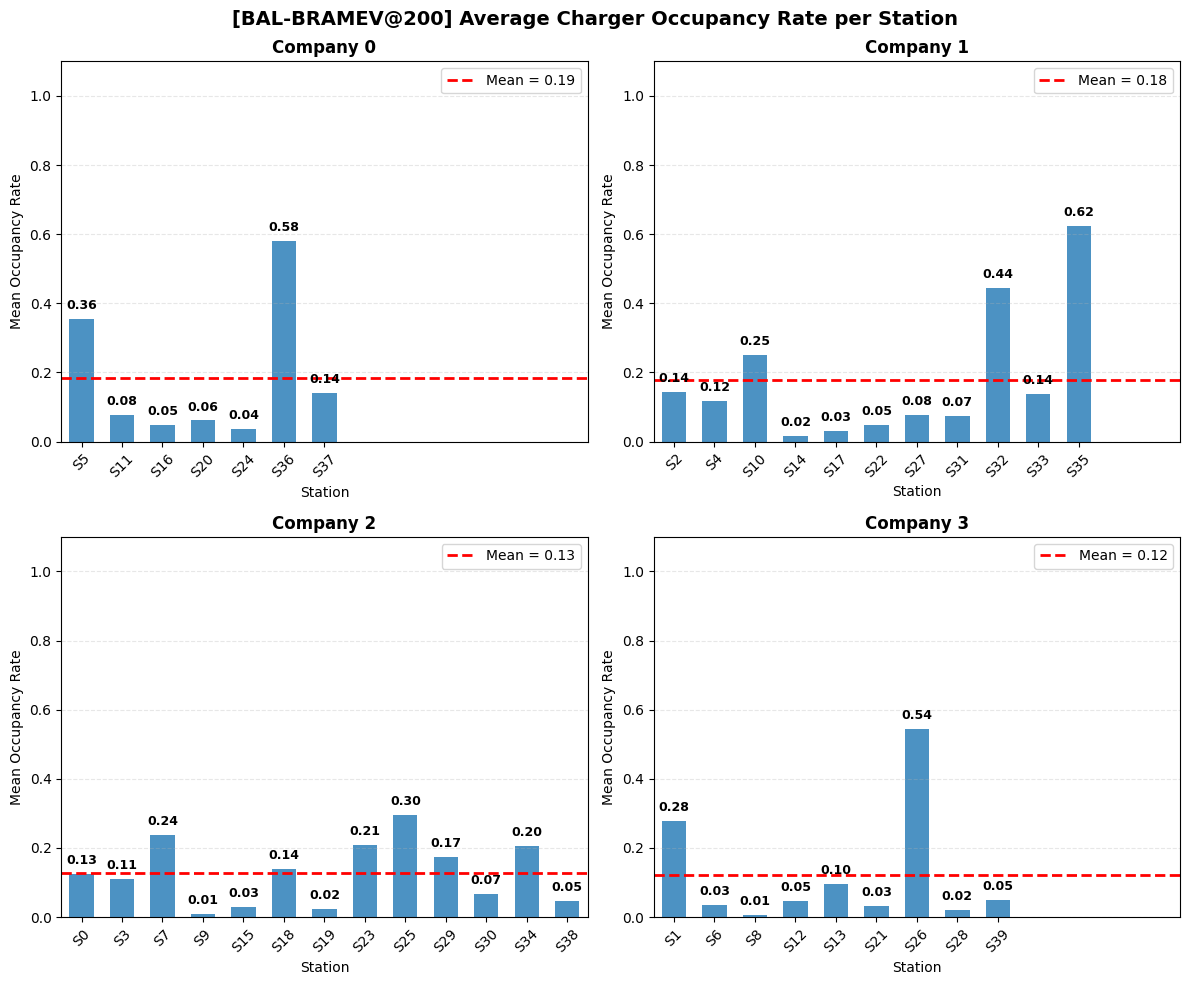

In [158]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

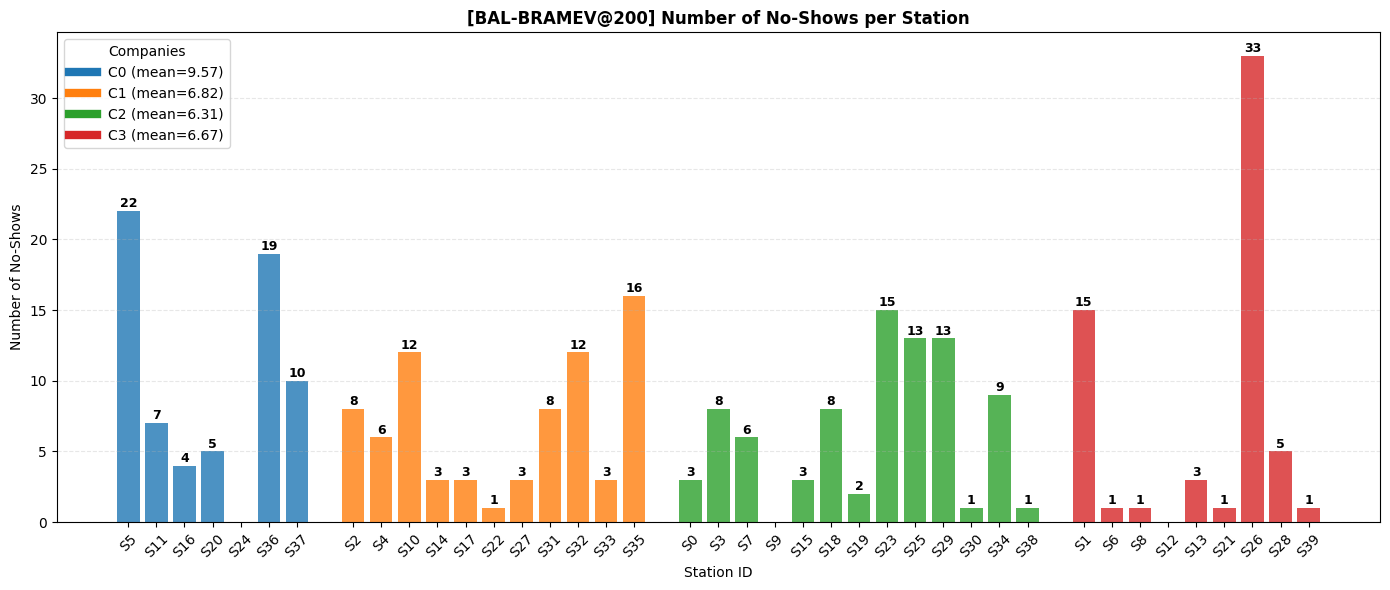

In [159]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [160]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,99,76,22,0,0,0.767677,0.222222,0.0,0.0
1,0,11,23,16,7,0,0,0.695652,0.304348,0.0,0.0
2,0,16,14,10,4,0,0,0.714286,0.285714,0.0,0.0
3,0,20,21,15,5,0,0,0.714286,0.238095,0.0,0.0
4,0,24,8,8,0,0,0,1.000000,0.000000,0.0,0.0
5,0,36,155,135,19,0,0,0.870968,0.122581,0.0,0.0
6,0,37,43,32,10,0,0,0.744186,0.232558,0.0,0.0
7,1,2,34,26,8,0,0,0.764706,0.235294,0.0,0.0
8,1,4,30,24,6,0,0,0.800000,0.200000,0.0,0.0
9,1,10,61,49,12,0,0,0.803279,0.196721,0.0,0.0


NUMBER OF REJECTED REQUESTS

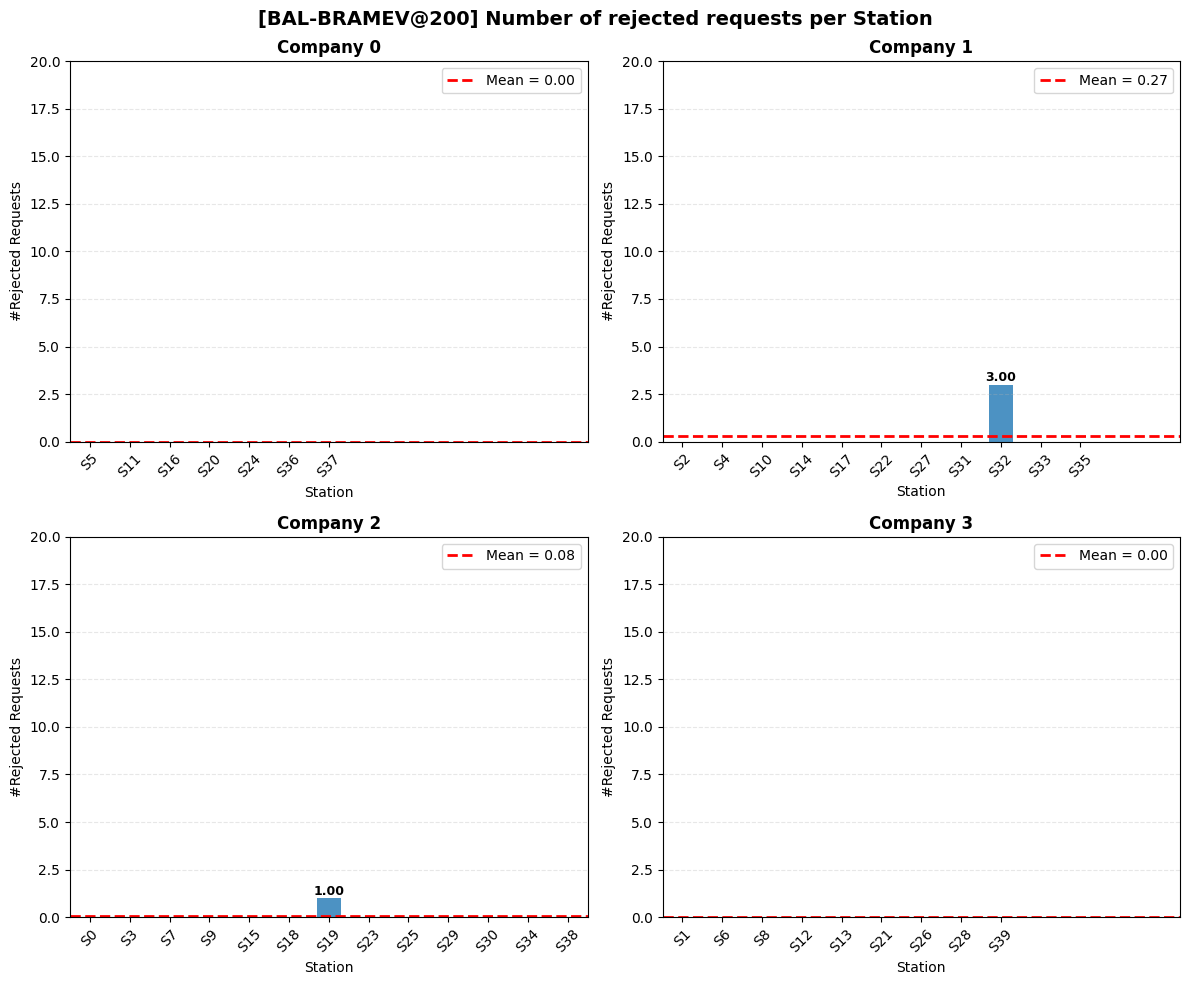

In [161]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [162]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

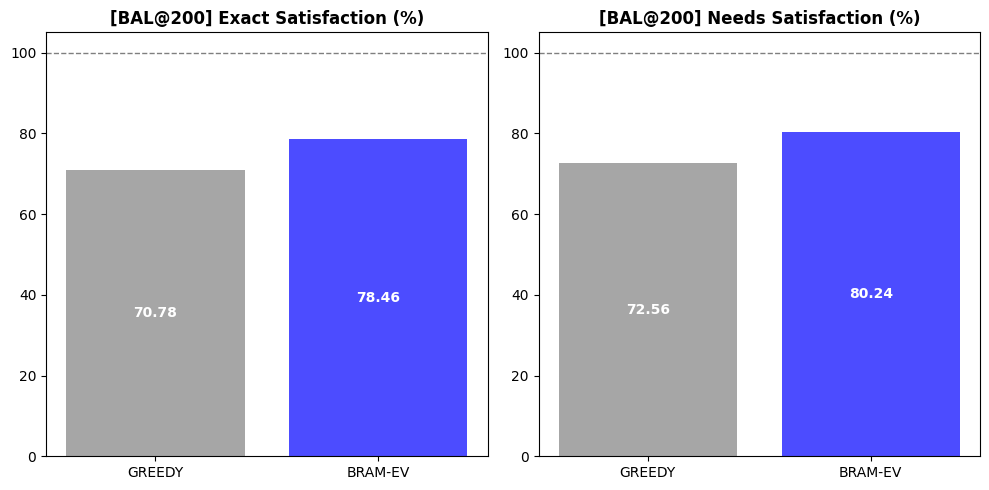

In [163]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

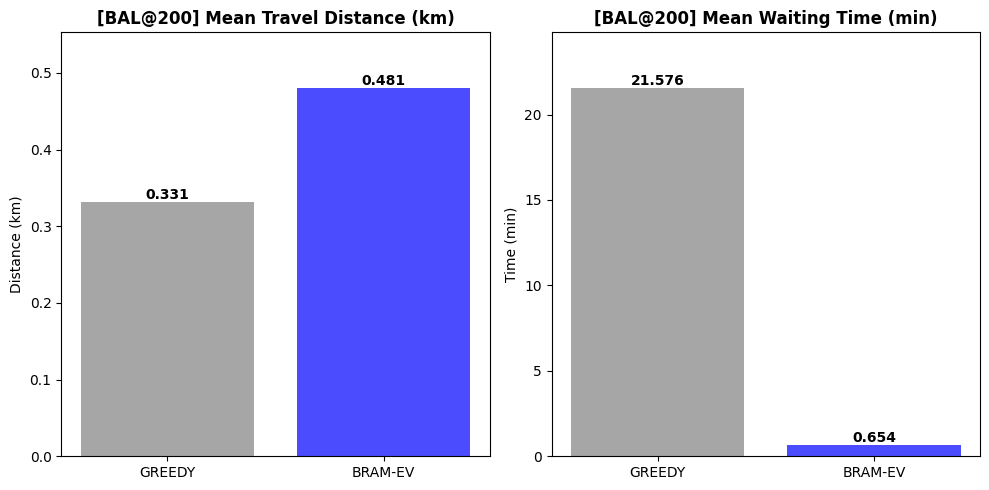

In [164]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

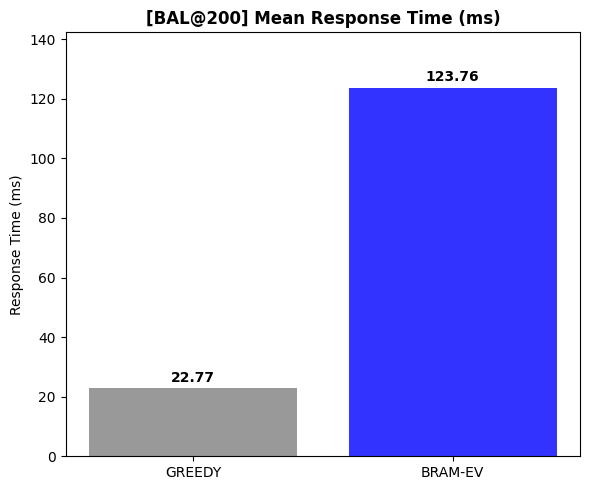

In [165]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [166]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [167]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [168]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [169]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:53:37.255 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:53:37.733 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:53:38.108 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:53:38.424 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:53:38.822 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:53:39.252 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:53:39.733 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:53:40.041 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:53:40.447 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:53:40.835 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:53:41.244 | IN

##### *Metrics*

In [170]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 99.92 kWh
  Station 1: 3.27 kWh
  Station 2: 81.73 kWh
  Station 3: 10.28 kWh
  Station 4: 11.93 kWh
  Station 5: 64.09 kWh
  Station 6: 15.82 kWh
  Station 7: 19.57 kWh
  Station 8: 60.75 kWh
  Station 9: 58.11 kWh
  Station 10: 90.31 kWh
  Station 11: 53.97 kWh
  Station 12: 217.79 kWh
  Station 13: 10.25 kWh
  Station 14: 45.21 kWh
  Station 15: 21.73 kWh
  Station 16: 40.68 kWh
  Station 17: 16.71 kWh
  Station 18: 3.59 kWh
  Station 19: 6.43 kWh
  Station 20: 19.97 kWh
  Station 21: 5.77 kWh
  Station 22: 122.24 kWh
  Station 23: 4.97 kWh
  Station 24: 79.17 kWh
  Station 25: 19.36 kWh
  Station 26: 3.80 kWh
  Station 27: 105.03 kWh
  Station 28: 93.69 kWh
  Station 29: 32.29 kWh
  Station 30: 21.84 kWh
  Station 31: 95.73 kWh
  Station 32: 141.65 kWh
  Station 33: 13.01 kWh
  Station 34: 10.82 kWh
  Station 35: 207.37 kWh
  Station 36: 116.33 kWh
  Station 37: 295.40 kWh
  Station 38: 15.33 kWh
  Station 

In [171]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

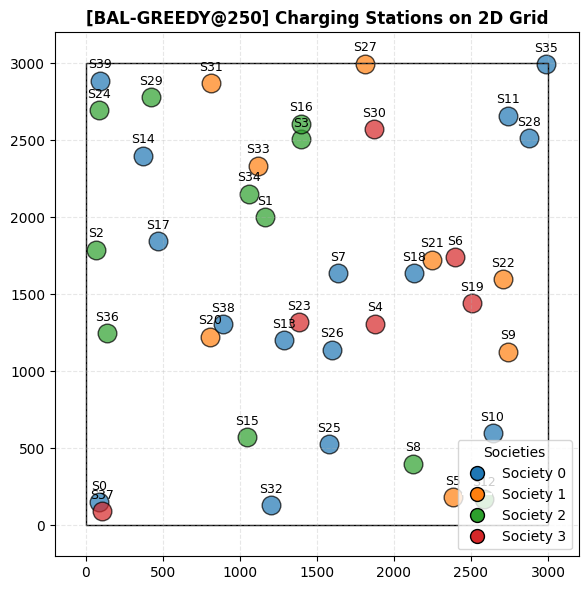

In [172]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

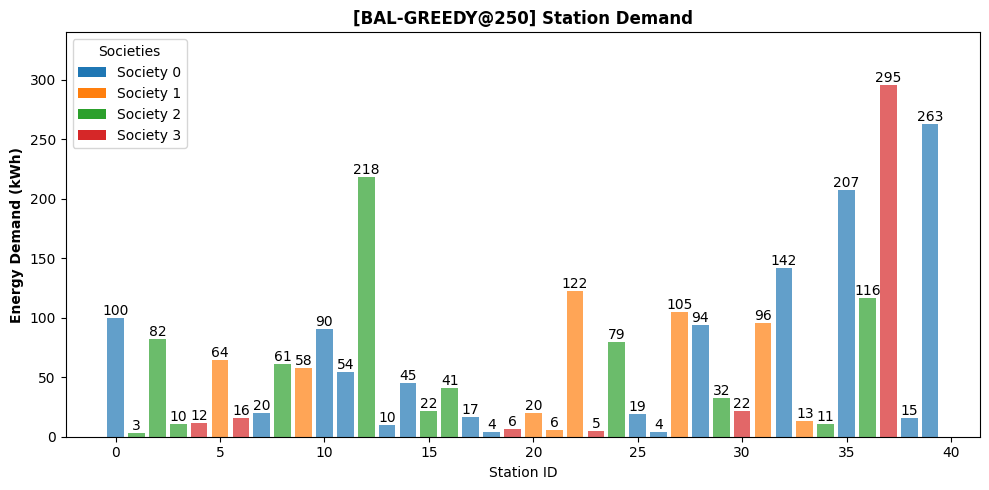

In [173]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

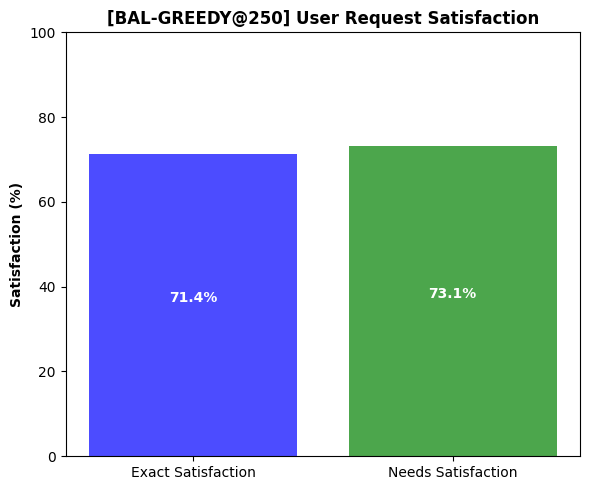

In [174]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

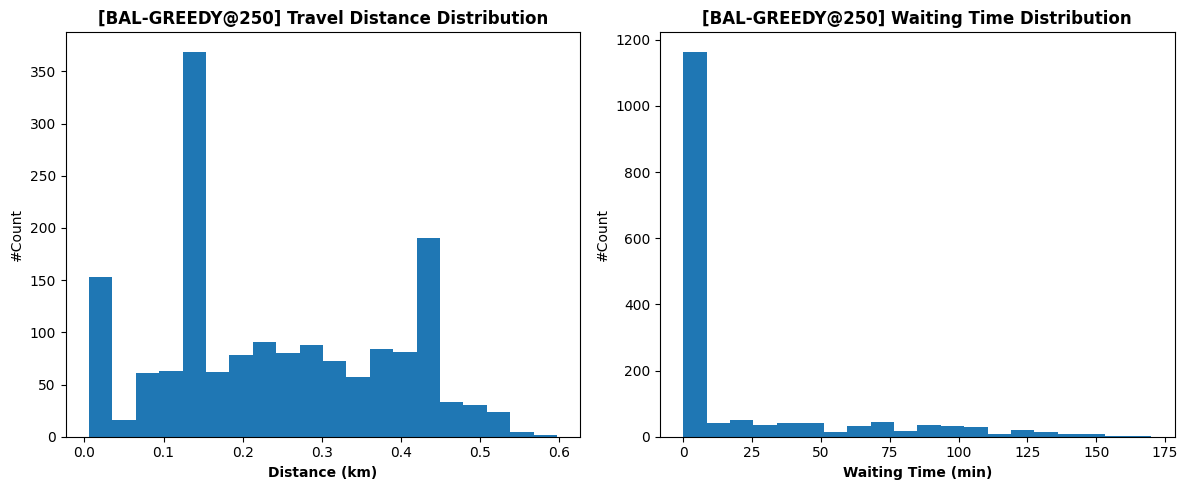

In [175]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

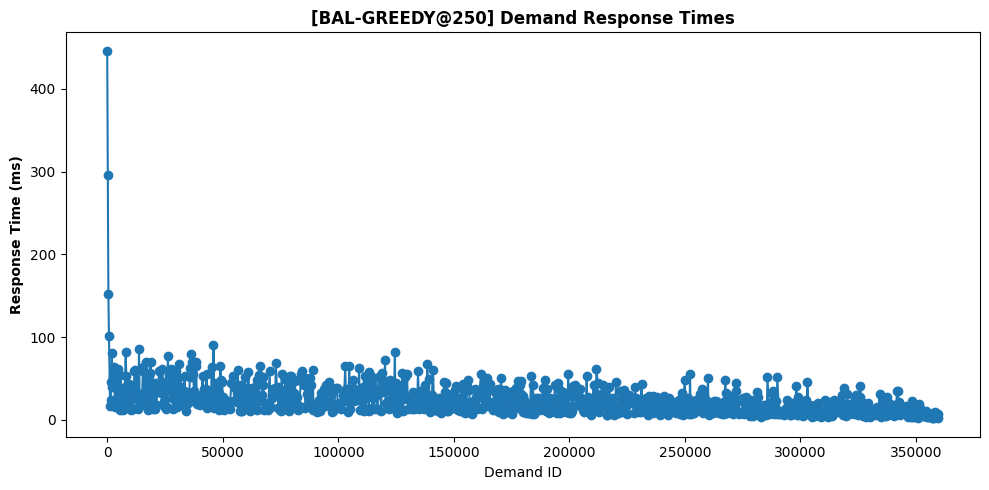

In [176]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

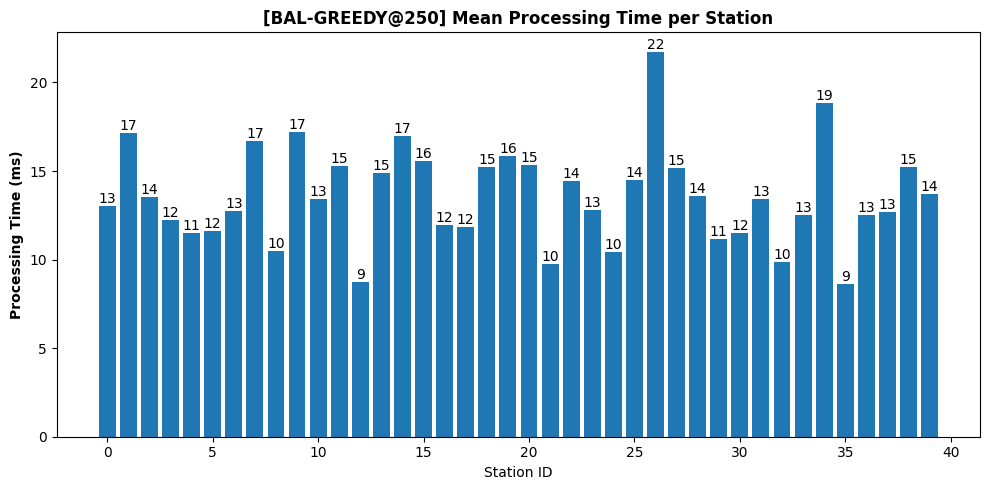

In [177]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [178]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.560417  0.458333  0.118056  0.122222  0.268056   
1            0           7  0.200694  0.043056  0.000000  0.000000  0.000000   
2            0          10  0.498611  0.379167  0.191667  0.122917  0.234028   
3            0          11  0.434722  0.156250  0.023611  0.004167  0.027083   
4            0          13  0.132639  0.000000  0.000000  0.000000  0.000000   
5            0          14  0.334722  0.247222  0.019444  0.000000  0.015278   
6            0          17  0.202778  0.029861  0.000000  0.000000  0.000000   
7            0          18  0.054861  0.000000  0.000000  0.000000  0.000000   
8            0          25  0.249306  0.018056  0.000000  0.000000  0.019444   
9            0          26  0.079167  0.000000  0.000000  0.000000  0.000000   
10           0          28  0.527083  0.483333  0.091667  0.121528  0.245139   
11           0          32  0.675000  0.

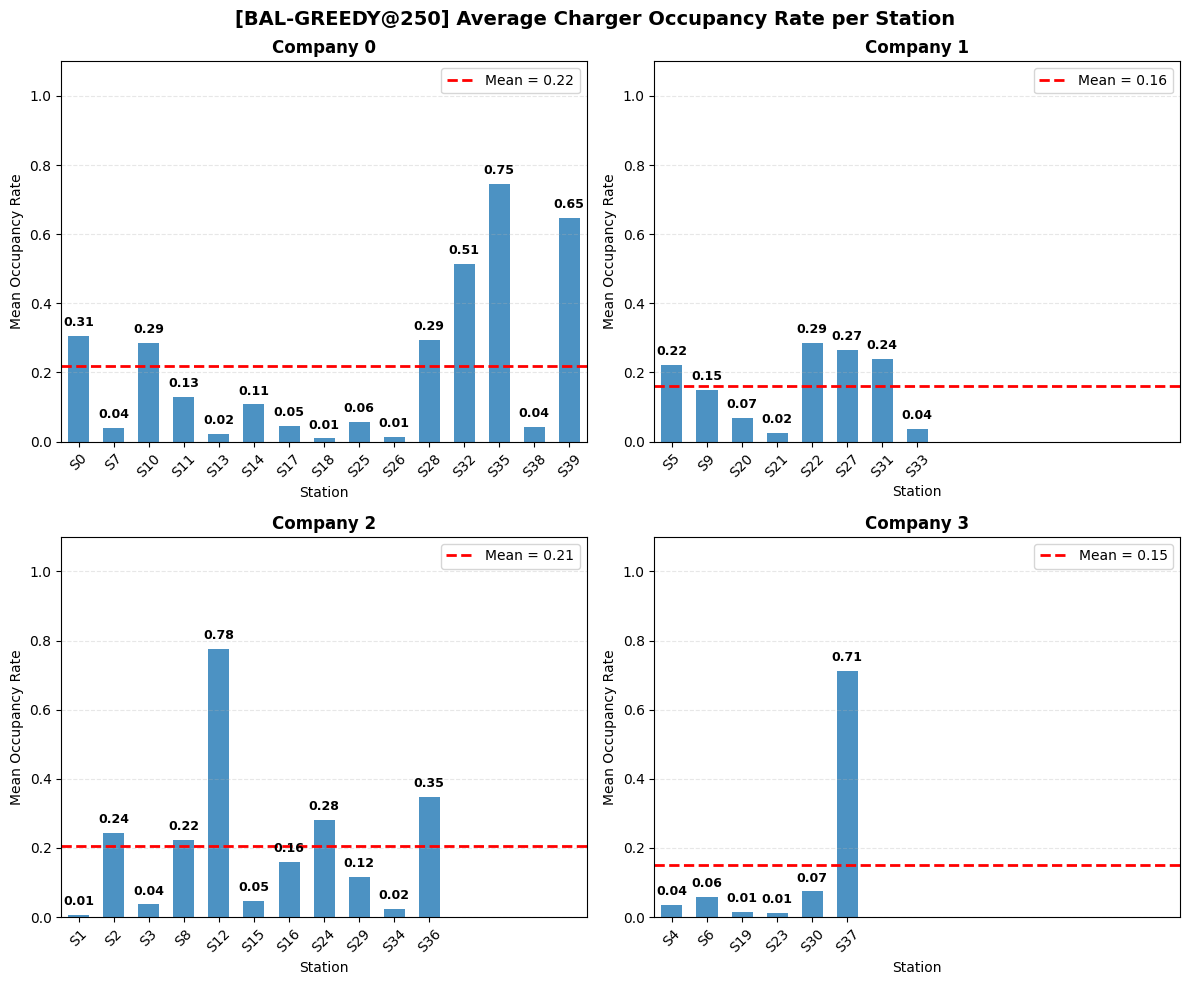

In [179]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

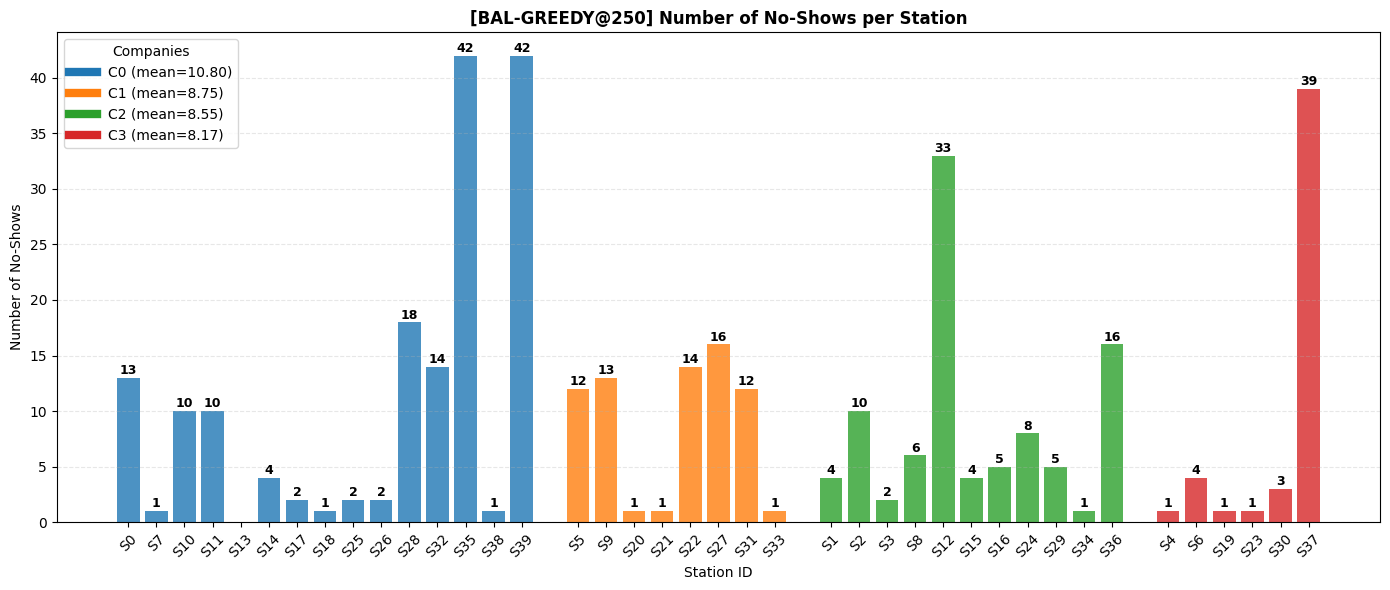

In [180]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [181]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,74,60,13,0,0,0.810811,0.175676,0.000000,0.000000
1,0,7,12,11,1,0,0,0.916667,0.083333,0.000000,0.000000
2,0,10,60,50,10,0,0,0.833333,0.166667,0.000000,0.000000
3,0,11,45,33,10,0,0,0.733333,0.222222,0.000000,0.000000
4,0,13,6,6,0,0,0,1.000000,0.000000,0.000000,0.000000
5,0,14,31,26,4,0,0,0.838710,0.129032,0.000000,0.000000
6,0,17,13,10,2,0,0,0.769231,0.153846,0.000000,0.000000
7,0,18,3,2,1,0,0,0.666667,0.333333,0.000000,0.000000
8,0,25,14,12,2,0,0,0.857143,0.142857,0.000000,0.000000
9,0,26,4,2,2,0,0,0.500000,0.500000,0.000000,0.000000


NUMBER OF REJECTED REQUESTS

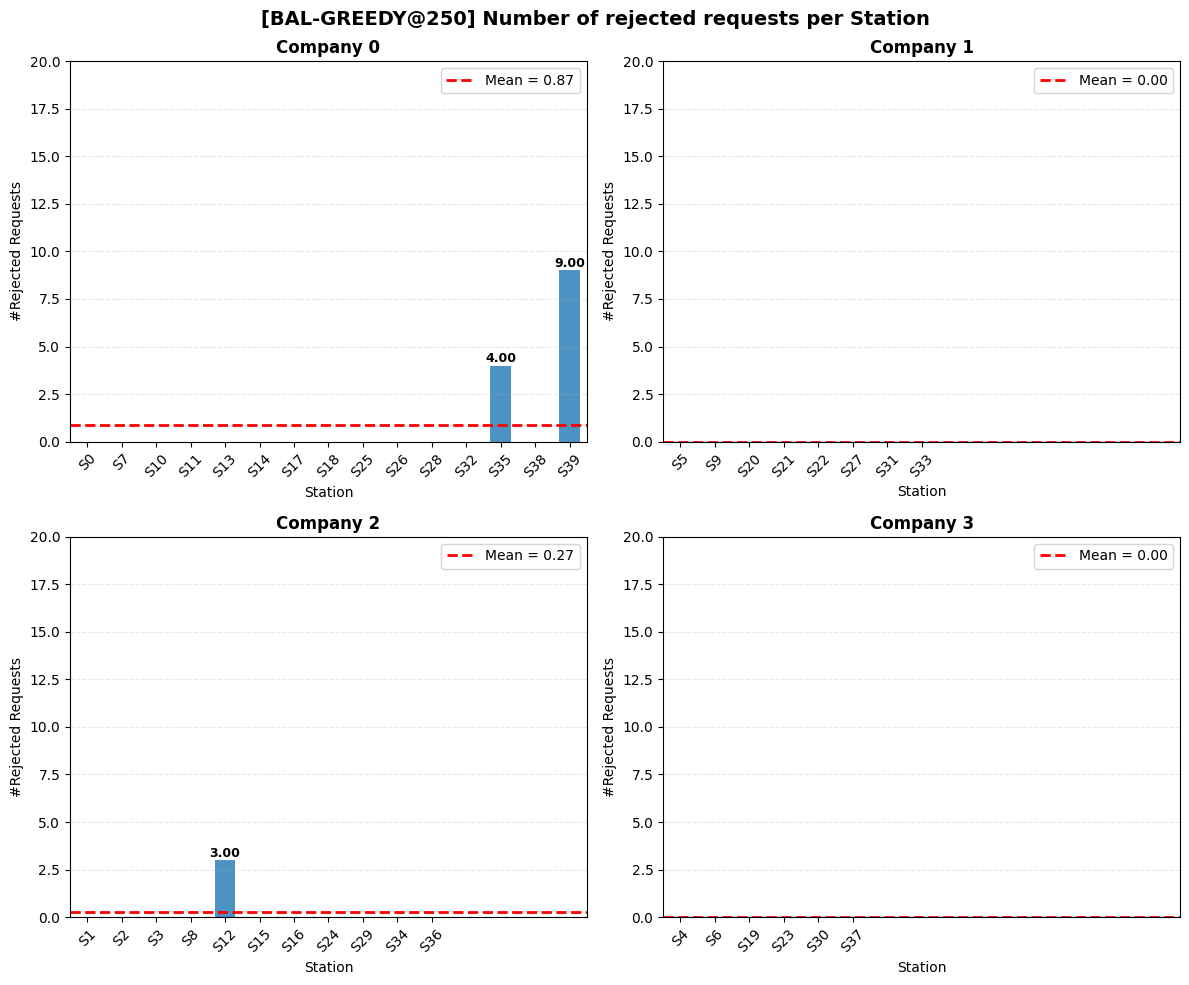

In [182]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [183]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [184]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [185]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:54:13.969 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:54:20.012 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:54:21.897 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:54:23.617 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:54:25.397 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:54:27.086 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:54:30.567 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:54:32.161 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:54:33.431 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:54:36.471 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:54:38.651 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [186]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 70.47 kWh
  Station 1: 192.68 kWh
  Station 2: 129.00 kWh
  Station 3: 20.49 kWh
  Station 4: 92.73 kWh
  Station 5: 9.82 kWh
  Station 6: 74.31 kWh
  Station 7: 2.22 kWh
  Station 8: 33.70 kWh
  Station 9: 26.74 kWh
  Station 10: 65.72 kWh
  Station 11: 21.18 kWh
  Station 12: 82.55 kWh
  Station 13: 239.43 kWh
  Station 14: 36.65 kWh
  Station 15: 48.78 kWh
  Station 16: 59.07 kWh
  Station 17: 18.07 kWh
  Station 18: 21.18 kWh
  Station 19: 126.33 kWh
  Station 20: 11.22 kWh
  Station 21: 93.08 kWh
  Station 22: 23.38 kWh
  Station 23: 128.60 kWh
  Station 24: 8.00 kWh
  Station 25: 58.41 kWh
  Station 26: 12.20 kWh
  Station 27: 23.07 kWh
  Station 28: 12.40 kWh
  Station 29: 12.38 kWh
  Station 30: 144.41 kWh
  Station 31: 39.14 kWh
  Station 32: 177.17 kWh
  Station 33: 52.66 kWh
  Station 34: 5.45 kWh
  Station 35: 105.33 kWh
  Station 36: 218.42 kWh
  Station 37: 86.67 kWh
  Station 38: 39.62 kWh
  Stat

In [187]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

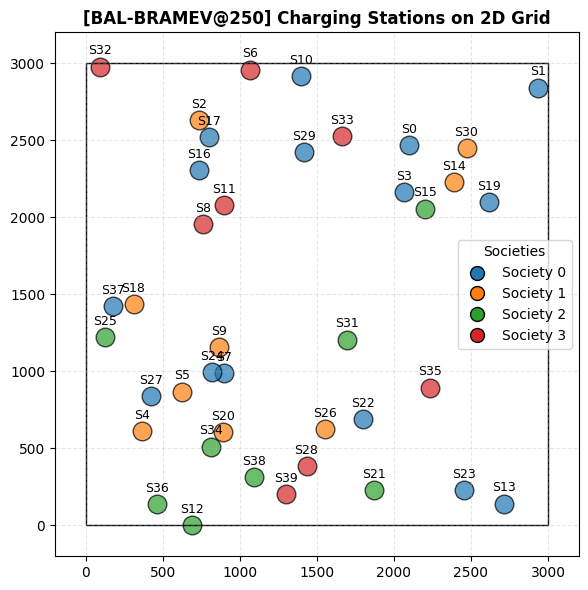

In [188]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

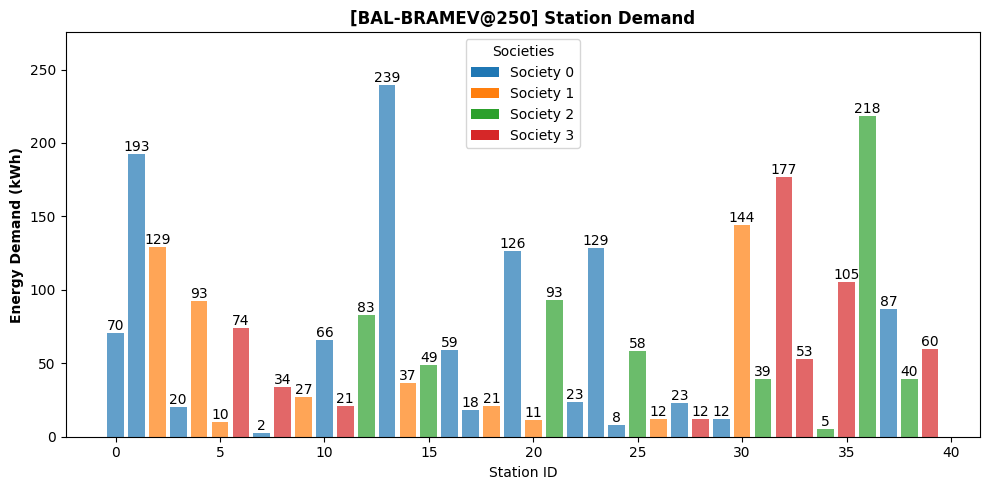

In [189]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

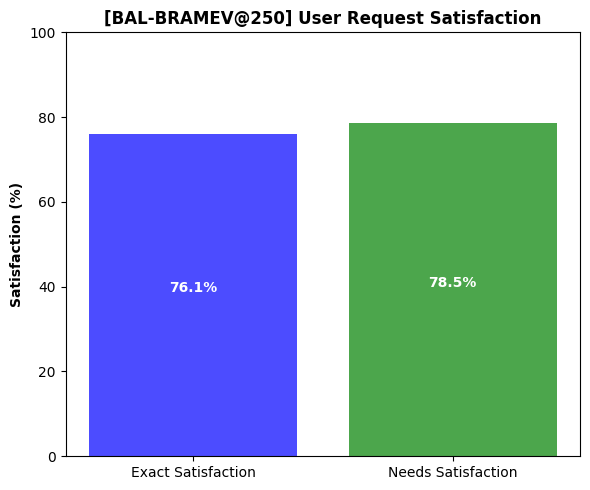

In [190]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

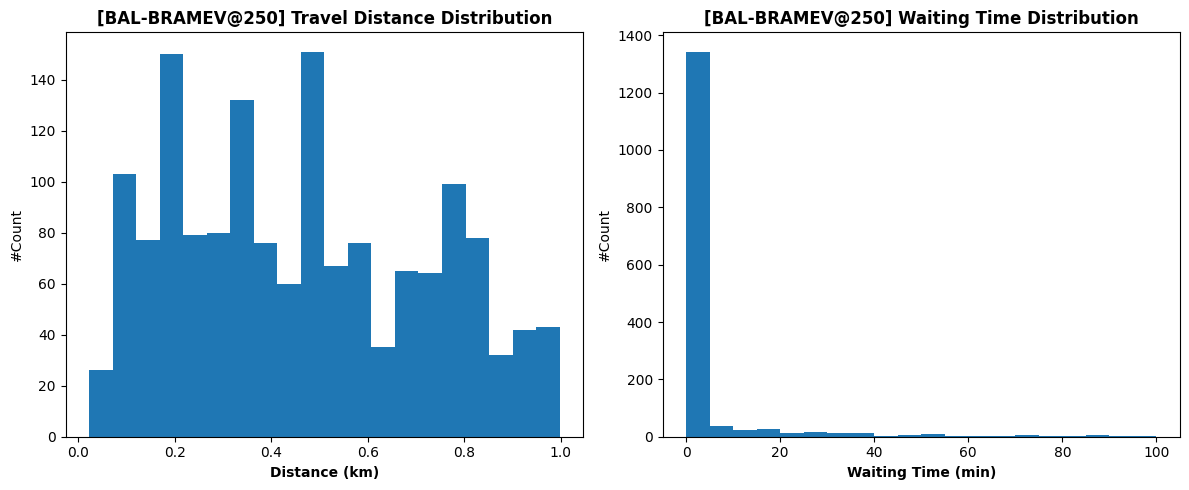

In [191]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

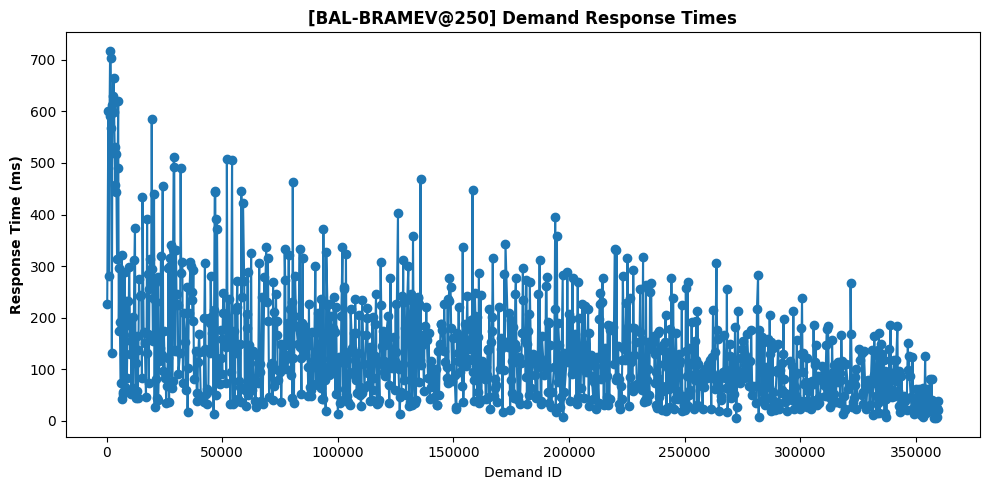

In [192]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

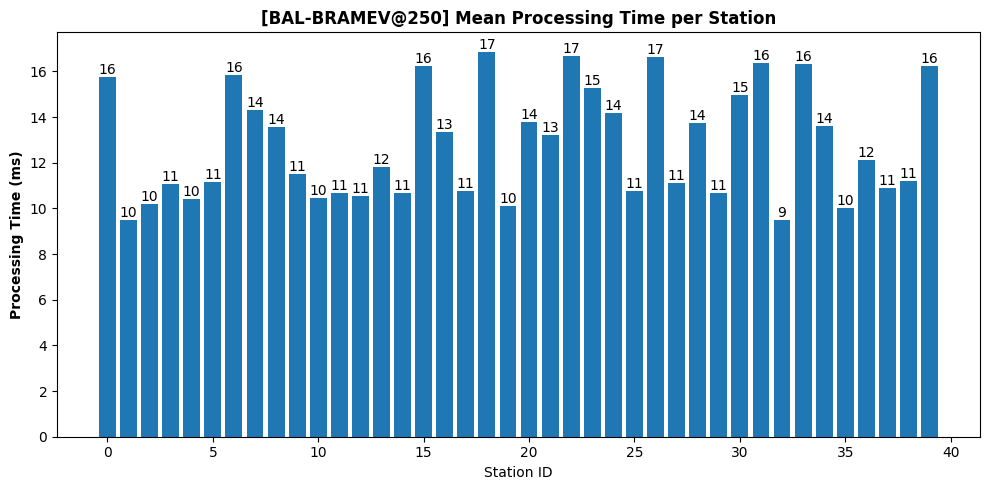

In [193]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

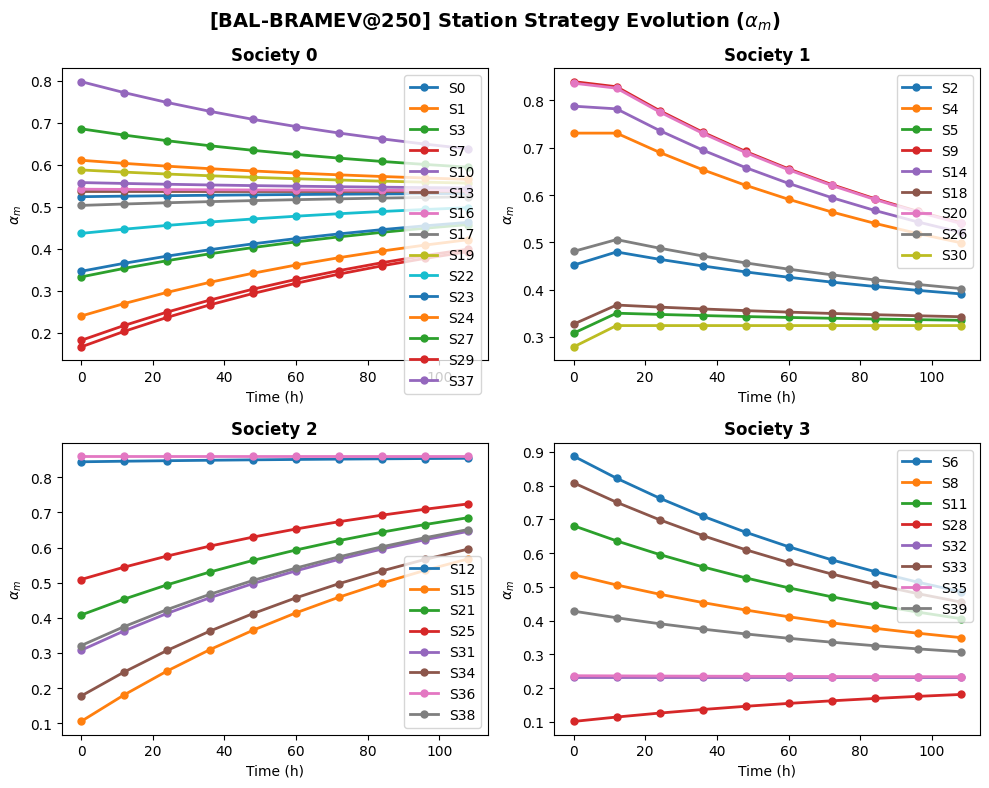

In [194]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [195]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.522917  0.253472  0.065278  0.045139  0.077778   
1            0           1  0.717361  0.714583  0.641667  0.673611       NaN   
2            0           3  0.211806  0.088889  0.000000  0.000000       NaN   
3            0           7  0.026389  0.000000  0.000000  0.000000  0.000000   
4            0          10  0.467361  0.259028  0.097222  0.114583       NaN   
5            0          13  0.756250  0.664583  0.654167  0.604861  0.717361   
6            0          16  0.475694  0.197222  0.072222  0.023611  0.081250   
7            0          17  0.128472  0.059722  0.013194  0.036806       NaN   
8            0          19  0.586111  0.493750  0.350000  0.270833       NaN   
9            0          22  0.197222  0.107639  0.023611  0.000000  0.000000   
10           0          23  0.550000  0.373611  0.203472  0.131250  0.186111   
11           0          24  0.121528  0.

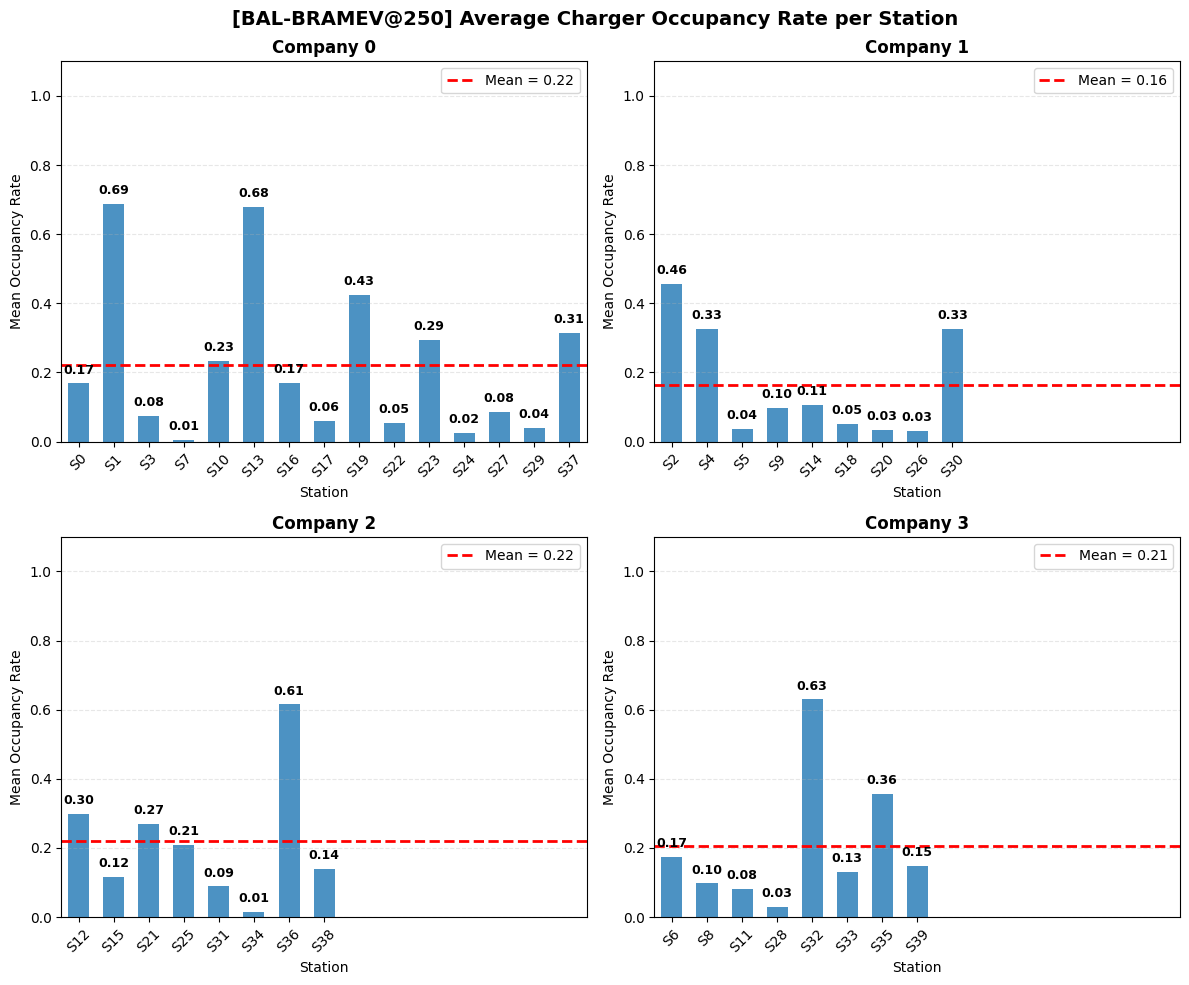

In [196]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

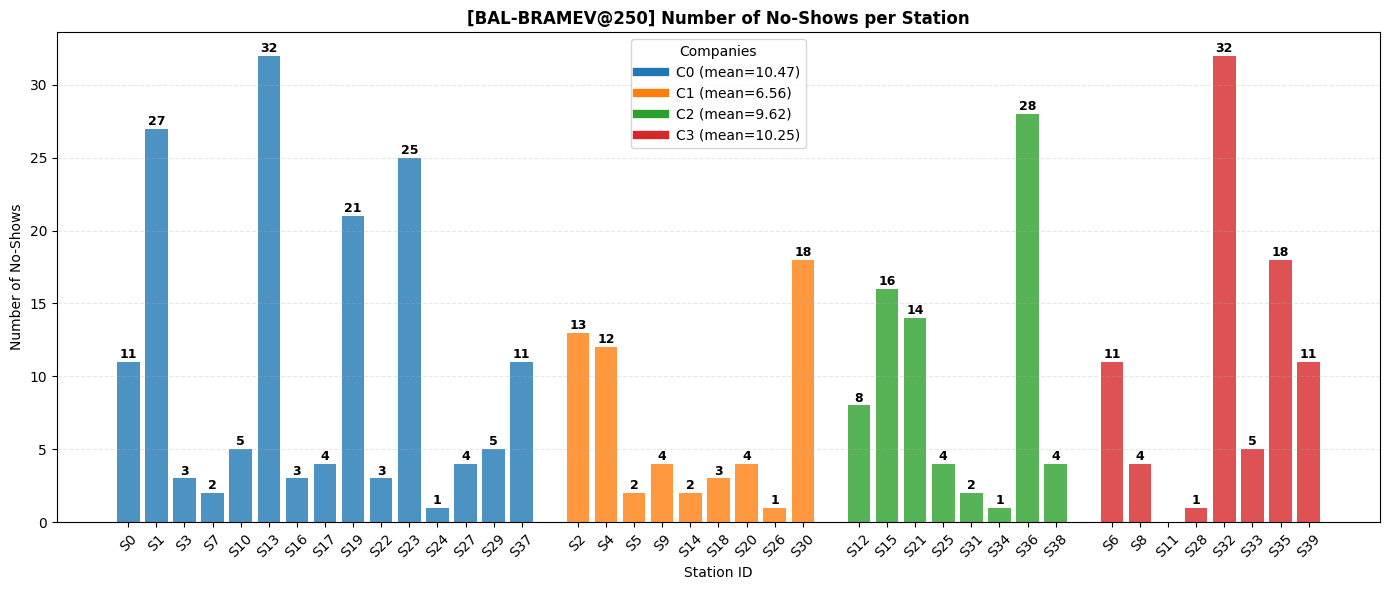

In [197]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [198]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,48,37,11,0,0,0.770833,0.229167,0.0,0.0
1,0,1,143,115,27,0,0,0.804196,0.188811,0.0,0.0
2,0,3,16,13,3,0,0,0.812500,0.187500,0.0,0.0
3,0,7,3,1,2,0,0,0.333333,0.666667,0.0,0.0
4,0,10,45,39,5,0,0,0.866667,0.111111,0.0,0.0
5,0,13,169,136,32,0,0,0.804734,0.189349,0.0,0.0
6,0,16,40,36,3,0,0,0.900000,0.075000,0.0,0.0
7,0,17,14,10,4,0,0,0.714286,0.285714,0.0,0.0
8,0,19,92,69,21,0,0,0.750000,0.228261,0.0,0.0
9,0,22,17,14,3,0,0,0.823529,0.176471,0.0,0.0


NUMBER OF REJECTED REQUESTS

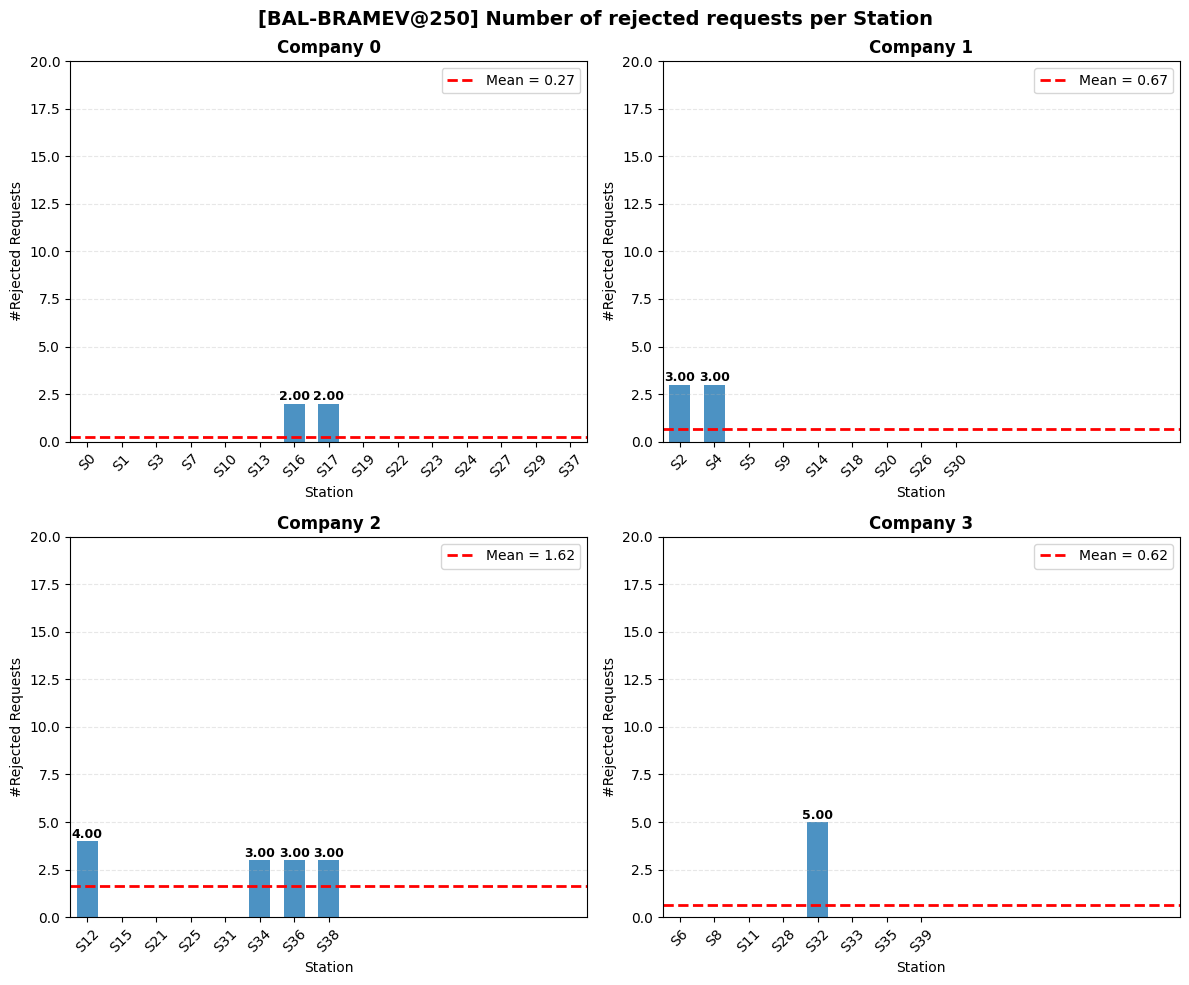

In [199]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [200]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

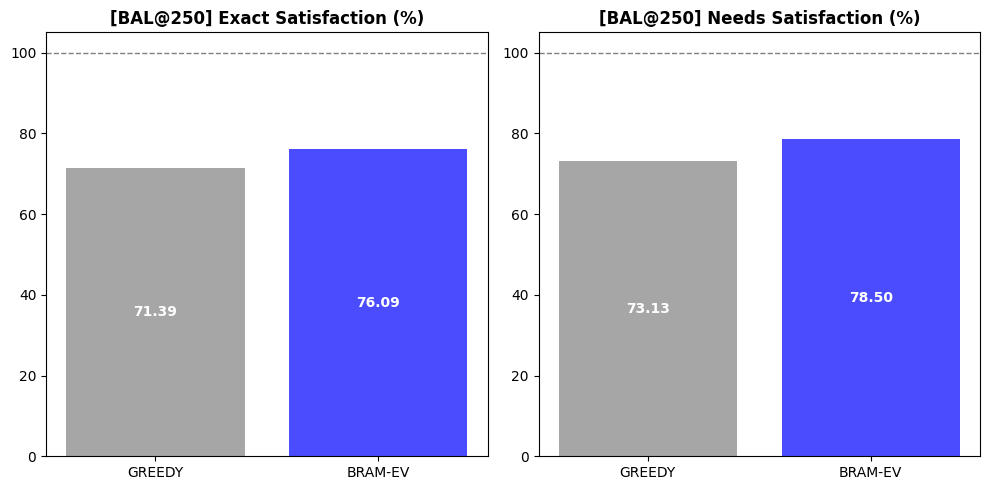

In [201]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

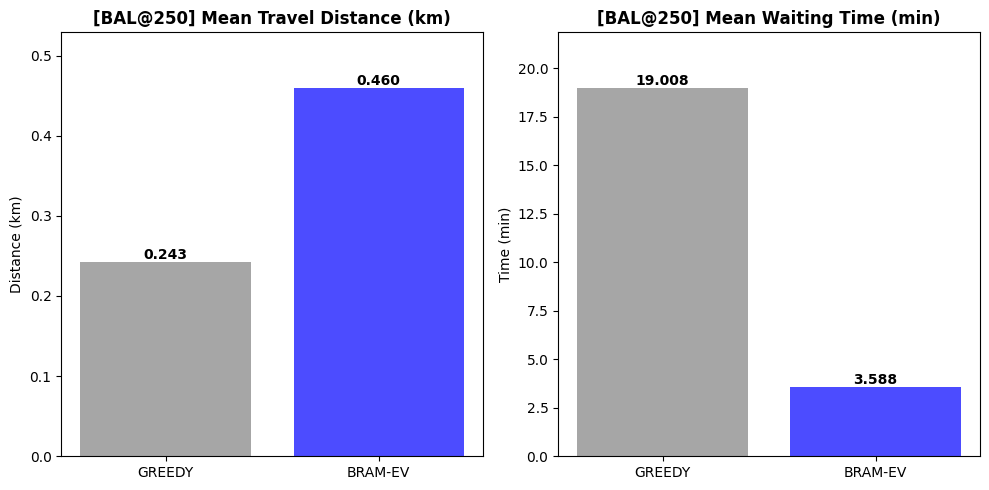

In [202]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

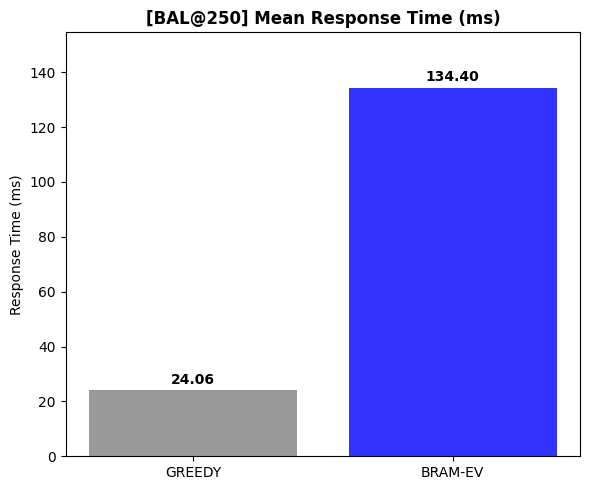

In [203]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

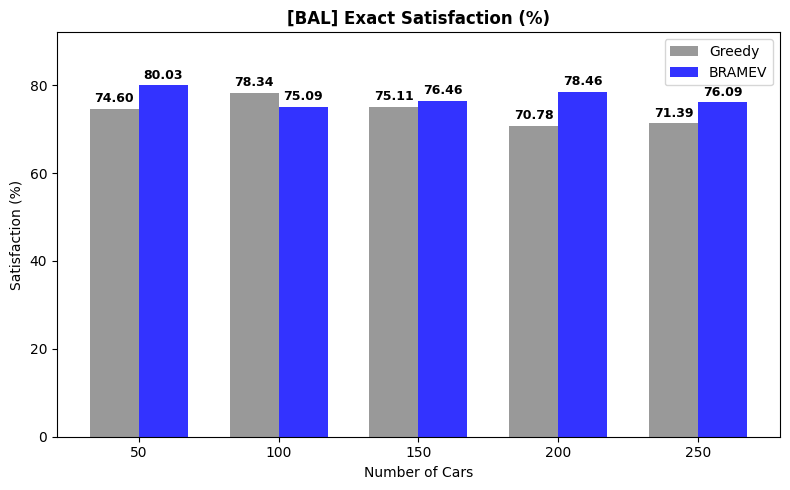

In [204]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

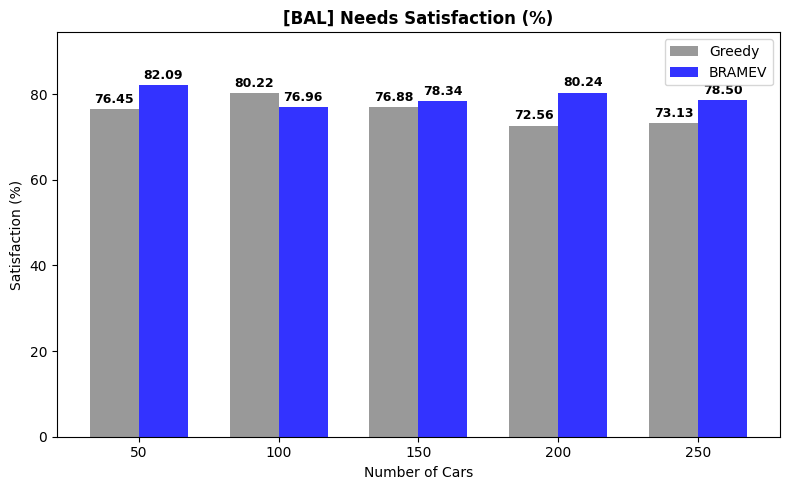

In [205]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

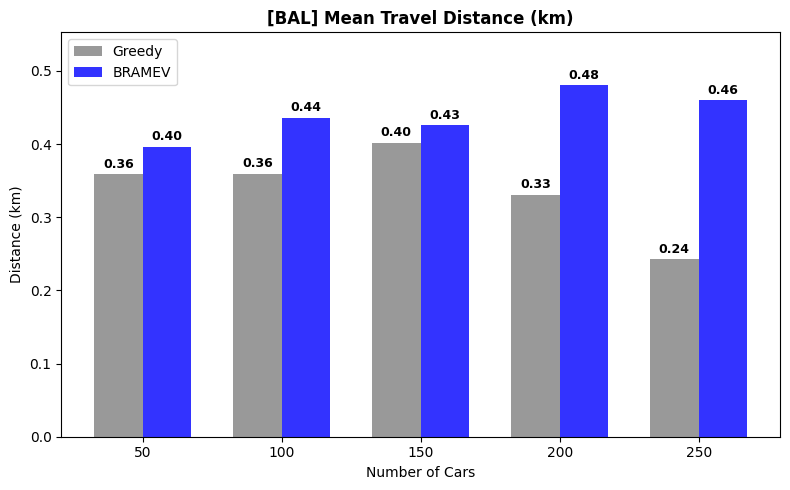

In [206]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


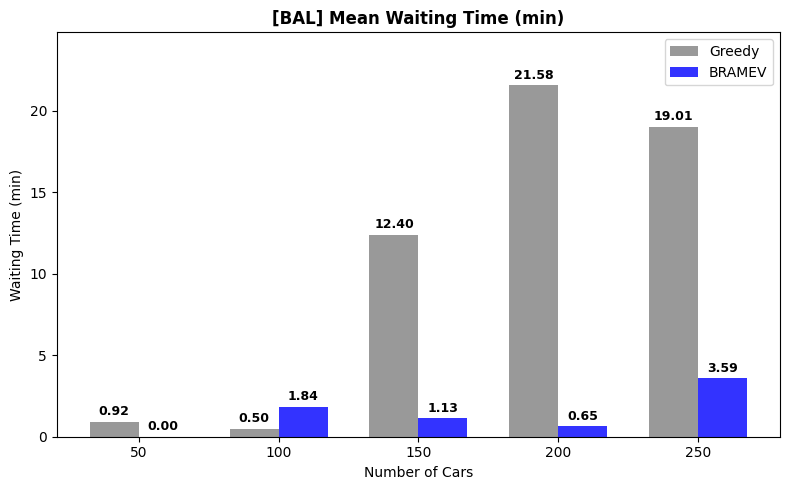

In [207]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


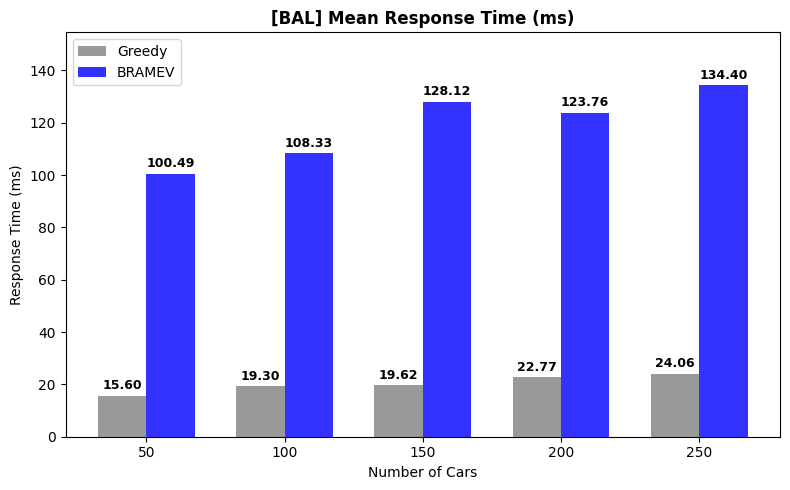

: 

In [ ]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
